### MovingAvg7 forecast : for each store + sku + day, predict forecast_date average units sold over the last 7 days and min_periods=3 for at least 3 days of history

### validate if the MovingAvg7 prediction accurate 

In [4]:
stores   = dfs["stores.csv"]
products = dfs["products.csv"]
sales    = dfs["sales_transactions.csv"]
stockouts = dfs["stockout_events.csv"]
snapshots = dfs["inventory_snapshots.csv"]
suppliers = dfs["suppliers.csv"]
promotions = dfs["promotions.csv"]
store_layout = dfs["store_layout.csv"]
transactions = dfs["sales_transactions.csv"]
replenishments = dfs["replenishment_logs.csv"]
demand_forecasts = dfs["demand_forecasts.csv"]

In [5]:
import pandas as pd

# Load data
stores = dfs["stores.csv"]
sales = dfs["sales_transactions.csv"]

# Aggregate sales by day
daily_sales = sales.groupby(["store_id", "sku_id", "sale_date"], as_index=False)["units_sold"].sum()

# Merge stores info
daily_sales = daily_sales.merge(stores[["store_id", "store_format", "foot_traffic_tier"]], on="store_id")

print("="*70)
print("DATE RANGE")
print("="*70)
print(f"From: {daily_sales['sale_date'].min()}")
print(f"To:   {daily_sales['sale_date'].max()}")
print(f"Days: {(daily_sales['sale_date'].max() - daily_sales['sale_date'].min()).days}")

#  Calculate variance of DAILY AVERAGES by store format and foot traffic tier
print("\n" + "="*70)
print("VARIANCE BY STORE FORMAT (Daily Average Sales)")
print("="*70)
variance_format = daily_sales.groupby(["sku_id", "store_format"])["units_sold"].mean().unstack(fill_value=0)
variance_format["variance"] = variance_format.var(axis=1)
variance_format = variance_format.sort_values("variance", ascending=False)
print(variance_format.head(10))

print("\n" + "="*70)
print("VARIANCE BY FOOT TRAFFIC (Daily Average Sales)")
print("="*70)
variance_traffic = daily_sales.groupby(["sku_id", "foot_traffic_tier"])["units_sold"].mean().unstack(fill_value=0)
variance_traffic["variance"] = variance_traffic.var(axis=1)
variance_traffic = variance_traffic.sort_values("variance", ascending=False)
print(variance_traffic.head(10))

# Show specific product P00055
print("\n" + "="*70)
print("EXAMPLE: PRODUCT P00055 - SALES BY STORE FORMAT")
print("="*70)
p00055_format = daily_sales[daily_sales["sku_id"] == "P00055"].groupby("store_format")["units_sold"].agg(["sum", "mean", "min", "max", "count"])
print(p00055_format)

print("\n" + "="*70)
print("EXAMPLE: PRODUCT P00055 - SALES BY FOOT TRAFFIC")
print("="*70)
p00055_traffic = daily_sales[daily_sales["sku_id"] == "P00055"].groupby("foot_traffic_tier")["units_sold"].agg(["sum", "mean", "min", "max", "count"])
print(p00055_traffic)

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("sum    = Total units sold over entire period")
print("mean   = Average units per day")
print("min    = smalles units sold per day")
print("max    = largest units sold per day")
print("count  = Number of days with sales")

DATE RANGE
From: 2024-01-01
To:   2025-12-31


TypeError: unsupported operand type(s) for -: 'str' and 'str'

 Plot 1: 1_sales_total.png


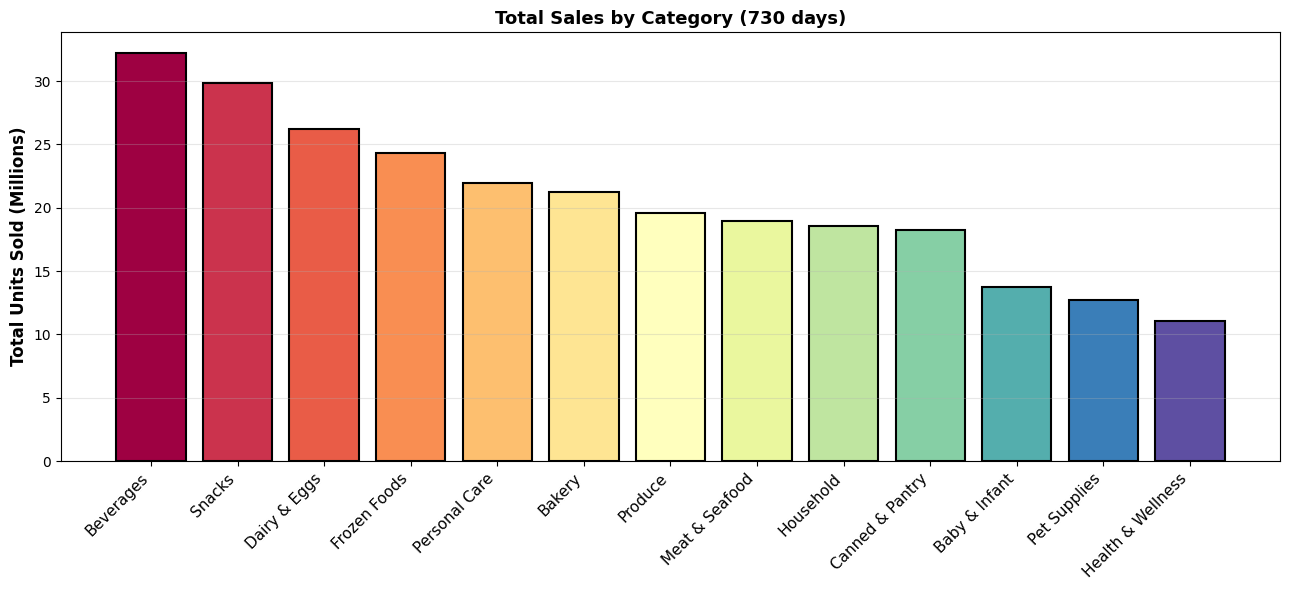

Plot 2: 2_daily_average.png


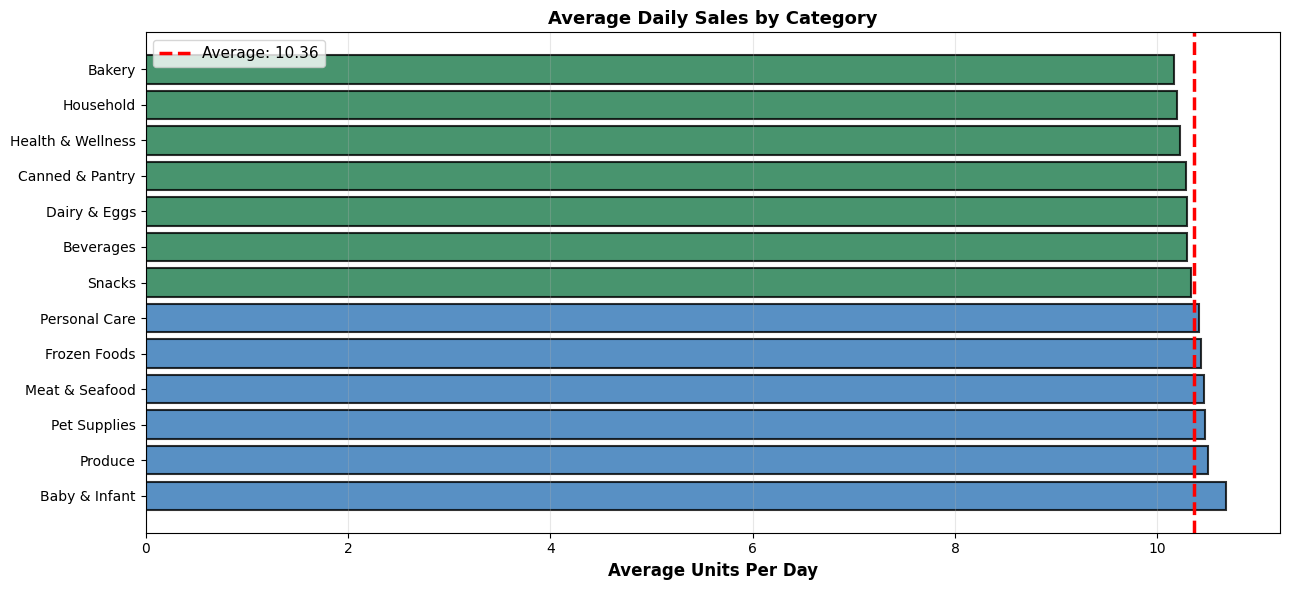

 Plot 3: 3_foot_traffic.png


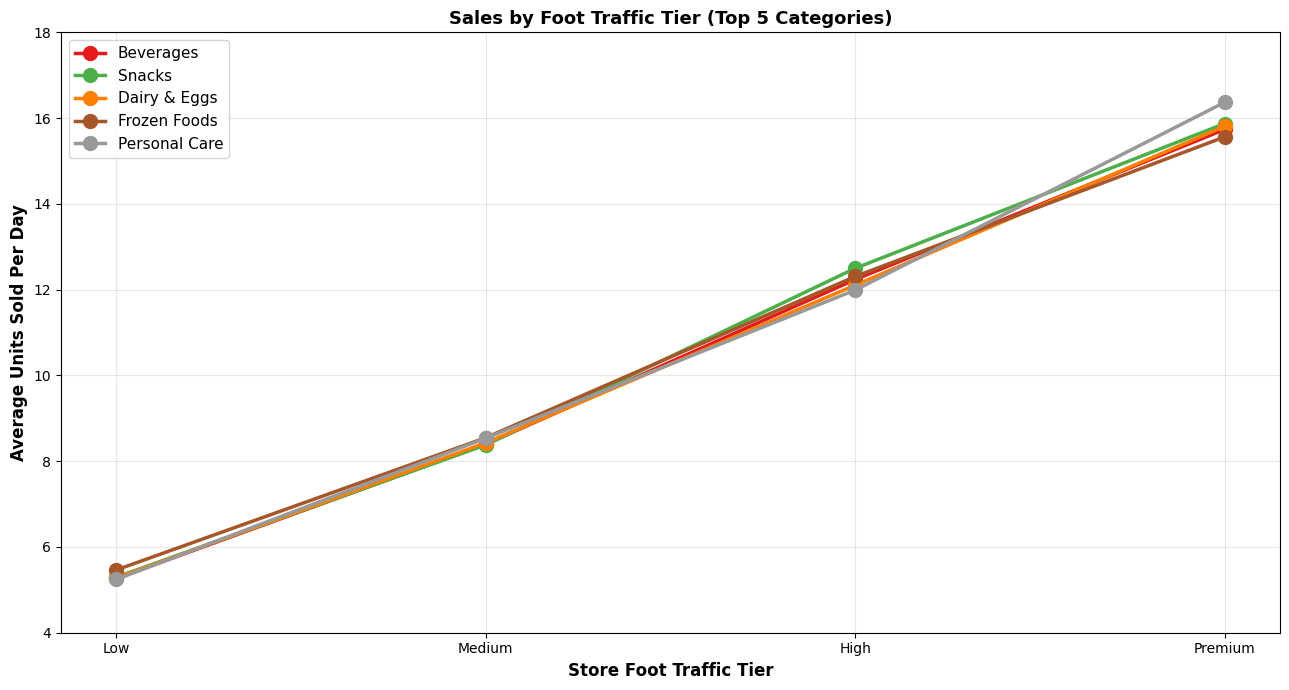


SIMPLE SUMMARY OF KEY INSIGHTS

 What the data shows:

1️  BEVERAGES sell most (32M units total)
2️  All categories similar daily (~10 units/day)
3️  FOOT TRAFFIC is the real difference:
    • Premium stores: ~16 units/day
    • High traffic: ~12 units/day
    • Low traffic: ~5 units/day
    → Premium = 3.2× more than Low traffic

    forecast can to be DIFFERENT for each traffic tier


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load data
stores = dfs["stores.csv"]
products = dfs["products.csv"]
sales = dfs["sales_transactions.csv"]

# Prepare data
daily_sales = sales.groupby(["store_id", "sku_id", "sale_date"], as_index=False)["units_sold"].sum()
daily_sales = daily_sales.merge(stores[["store_id", "store_format", "foot_traffic_tier"]], on="store_id")
daily_sales = daily_sales.merge(products[["sku_id", "category"]], on="sku_id")

category_sales = daily_sales.groupby("category")["units_sold"].agg(["sum", "mean"]).sort_values("sum", ascending=False)
category_traffic = daily_sales.groupby(["category", "foot_traffic_tier"])["units_sold"].mean().unstack()

# ============  TOTAL SALES ============
fig1, ax1 = plt.subplots(figsize=(13, 6))
colors = plt.cm.Spectral(np.linspace(0, 1, len(category_sales)))
ax1.bar(range(len(category_sales)), category_sales["sum"]/1e6, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(category_sales)))
ax1.set_xticklabels(category_sales.index, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Total Units Sold (Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Total Sales by Category (730 days)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('1_sales_total.png', dpi=300, bbox_inches='tight')
print(" Plot 1: 1_sales_total.png")
plt.show()

# ============ : DAILY AVERAGE ============
fig2, ax2 = plt.subplots(figsize=(13, 6))
daily_avg = category_sales.sort_values("mean", ascending=False)
overall_avg = daily_avg["mean"].mean()
colors2 = ['#2E75B6' if x > overall_avg else '#1A7A4A' for x in daily_avg["mean"]]
ax2.barh(daily_avg.index, daily_avg["mean"], color=colors2, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.axvline(overall_avg, color='red', linestyle='--', linewidth=2.5, label=f'Average: {overall_avg:.2f}')
ax2.set_xlabel('Average Units Per Day', fontsize=12, fontweight='bold')
ax2.set_title('Average Daily Sales by Category', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('2_daily_average.png', dpi=300, bbox_inches='tight')
print("Plot 2: 2_daily_average.png")
plt.show()

# ============ : FOOT TRAFFIC  ============
fig3, ax3 = plt.subplots(figsize=(13, 7))
top_cats = category_sales.head(5).index
traffic_order = ['Low', 'Medium', 'High', 'Premium']
colors3 = plt.cm.Set1(np.linspace(0, 1, len(top_cats)))

for cat, color in zip(top_cats, colors3):
    values = [category_traffic.loc[cat, tier] for tier in traffic_order]
    ax3.plot(traffic_order, values, marker='o', markersize=10, linewidth=2.5, label=cat, color=color)

ax3.set_xlabel('Store Foot Traffic Tier', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Units Sold Per Day', fontsize=12, fontweight='bold')
ax3.set_title('Sales by Foot Traffic Tier (Top 5 Categories)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11, loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(4, 18)
plt.tight_layout()
plt.savefig('3_foot_traffic.png', dpi=300, bbox_inches='tight')
print(" Plot 3: 3_foot_traffic.png")
plt.show()

print("\n" + "="*70)
print("SIMPLE SUMMARY OF KEY INSIGHTS")
print("="*70)
print("\n What the data shows:\n")
print("1️  BEVERAGES sell most (32M units total)")
print("2️  All categories similar daily (~10 units/day)")
print("3️  FOOT TRAFFIC is the real difference:")
print(f"    • Premium stores: ~16 units/day")
print(f"    • High traffic: ~12 units/day")
print(f"    • Low traffic: ~5 units/day")
print(f"    → Premium = 3.2× more than Low traffic\n")
print("    forecast can to be DIFFERENT for each traffic tier")


In [80]:
import pandas as pd

# Load data
forecasts = pd.read_csv('../data/raw/output/csv/demand_forecasts.csv')

print("="*80)
print(" BASELINE - PREDICTION INTERVAL WIDTH")
print("="*80)

# Calculate interval width
forecasts["interval_width"] = forecasts["upper_bound_90"] - forecasts["lower_bound_90"]
forecasts["interval_width_pct"] = (forecasts["interval_width"] / forecasts["forecast_units"]) * 100

# Group by forecast method
baseline = (
    forecasts.groupby("forecast_method").agg({
        "interval_width_pct": "mean",
        "forecast_id": "count"
    }).round(2)
)
baseline.columns = ["Interval Width %", "Total Forecasts"]
baseline = baseline.sort_values("Interval Width %", ascending=True)

print("\n")
print(baseline.to_string())

print("\n" + "="*80)
print(" ACCEPTABLE THRESHOLD: 33%")
print("="*80)

 BASELINE - PREDICTION INTERVAL WIDTH


                      Interval Width %  Total Forecasts
forecast_method                                        
ExponentialSmoothing             32.99          3862240
MovingAvg30                      33.00          3862240
MovingAvg7                       33.00          3862240
SeasonalNaive                    33.01          3862240

 ACCEPTABLE THRESHOLD: 33%


In [ ]:
import pandas as pd

stockouts = pd.read_csv('../data/raw/output/csv/stockout_events.csv')
products = pd.read_csv('../data/raw/output/csv/products.csv')
suppliers = pd.read_csv('../data/raw/output/csv/suppliers.csv')
promotions = pd.read_csv('../data/raw/output/csv/promotions.csv')

stockouts['stockout_date'] = pd.to_datetime(stockouts['stockout_date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

print("Data loaded successfully. Running Architect's Audit...\n")

# ==========================================
# SCENARIO A: Perishable vs Non-Perishable
# ==========================================
# Merge stockouts with product info
prod_stock = stockouts.merge(products[['sku_id', 'is_perishable', 'supplier_id']], on='sku_id', how='left')

# Compare how much revenue is lost based on perishability
perishable_impact = (
    prod_stock.groupby(['is_perishable', 'root_cause'])
    .agg(lost_revenue=('estimated_lost_revenue', 'sum'))
    .unstack()
)
print("--- SCENARIO A: REVENUE LOST BY PERISHABILITY & ROOT CAUSE ---")
print(perishable_impact.applymap(lambda x: f"${x:,.0f}" if pd.notnull(x) else "$0"))
print("\n")


# ==========================================
# ==========================================
# Filter only for stockouts caused by "Supplier delay"
supplier_delays = prod_stock[prod_stock['root_cause'] == 'Supplier delay']

# Merge with the suppliers table to get the names
bad_suppliers = supplier_delays.merge(suppliers[['supplier_id', 'supplier_name', 'reliability_score']], on='supplier_id', how='left')

# Find out who is causing the most financial damage
worst_vendors = (
    bad_suppliers.groupby(['supplier_name', 'reliability_score'])
    .agg(delay_events=('stockout_id', 'count'), revenue_lost=('estimated_lost_revenue', 'sum'))
    .sort_values(by='revenue_lost', ascending=False)
    .head(5)
)
print("--- SCENARIO B: TOP 5 WORST SUPPLIERS (SUPPLIER DELAYS) ---")
print(worst_vendors.applymap(lambda x: f"${x:,.0f}" if isinstance(x, float) and x > 100 else x))
print("\n")


# ==========================================
# SCENARIO C: Marketing Chaos (Promotions)
# ==========================================
# Let's see how many stockouts happened DURING an active promotion
# Merge stockouts with promos (Note: some promos apply to all stores, so we join on sku_id)
promo_stock = stockouts.merge(promotions[['sku_id', 'store_id', 'start_date', 'end_date', 'promo_type']], on='sku_id', how='inner')

# Filter for stockouts that occurred strictly while the promo was active
active_promo_stockouts = promo_stock[
    (promo_stock['stockout_date'] >= promo_stock['start_date']) & 
    (promo_stock['stockout_date'] <= promo_stock['end_date'])
]

# Check if the store_id matches (or if it was a global promo where store_id is NaN)
active_promo_stockouts = active_promo_stockouts[
    (active_promo_stockouts['store_id_x'] == active_promo_stockouts['store_id_y']) | 
    (active_promo_stockouts['store_id_y'].isna())
]

# See which promotion types cause the most chaos
marketing_damage = (
    active_promo_stockouts.groupby('promo_type')
    .agg(stockouts_caused=('stockout_id', 'count'))
    .sort_values(by='stockouts_caused', ascending=False)
)
print("--- SCENARIO C: STOCKOUTS TRIGGERED BY ACTIVE PROMOTIONS ---")
print(marketing_damage)

Data loaded successfully. Running Architect's Audit...

--- SCENARIO A: REVENUE LOST BY PERISHABILITY & ROOT CAUSE ---
              lost_revenue                                          \
root_cause    Demand spike Forecast miss Manual error      Ongoing   
is_perishable                                                        
False          $50,309,201   $50,400,529  $50,052,983  $12,351,434   
True           $38,057,205   $35,398,138  $36,223,520  $13,829,695   

                                           
root_cause       Shrinkage Supplier delay  
is_perishable                              
False          $50,284,160    $50,618,245  
True           $35,685,600    $36,743,951  


--- SCENARIO B: TOP 5 WORST SUPPLIERS (SUPPLIER DELAYS) ---
                                         delay_events revenue_lost
supplier_name         reliability_score                           
BeaconPoint Logistics 0.843                      1913   $3,299,331
KeyMart Distributors  0.861                    

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1124729007.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(perishable_impact.applymap(lambda x: f"${x:,.0f}" if pd.notnull(x) else "$0"))
/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1124729007.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(worst_vendors.applymap(lambda x: f"${x:,.0f}" if isinstance(x, float) and x > 100 else x))


--- SCENARIO C: STOCKOUTS TRIGGERED BY ACTIVE PROMOTIONS ---
             stockouts_caused
promo_type                   
Percent Off              3740
Clearance                3516
BOGO                     3224
Loyalty                  3152
Bundle                   2786


In [12]:
import pandas as pd

stockouts = pd.read_csv('../data/raw/output/csv/stockout_events.csv')
stores = pd.read_csv('../data/raw/output/csv/stores.csv')

# Merge to get store details
store_stockouts = stockouts.merge(stores[['store_id', 'region', 'foot_traffic_tier', 'store_format']], on='store_id', how='left')

# Check which foot traffic tiers lose the most money
traffic_loss = (
    store_stockouts.groupby('foot_traffic_tier')
    .agg(revenue_lost=('estimated_lost_revenue', 'sum'), stockout_count=('stockout_id', 'count'))
    .sort_values(by='revenue_lost', ascending=False)
)

print("--- REVENUE LOST BY FOOT TRAFFIC TIER ---")
print(traffic_loss.applymap(lambda x: f"${x:,.0f}" if isinstance(x, float) else x))

--- REVENUE LOST BY FOOT TRAFFIC TIER ---
                   revenue_lost  stockout_count
foot_traffic_tier                              
Premium            $255,829,353          130251
High               $118,614,521           78327
Medium              $61,941,884           63027
Low                 $23,568,902           41994


/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_11589/3819919231.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(traffic_loss.applymap(lambda x: f"${x:,.0f}" if isinstance(x, float) else x))


In [1]:
from pathlib import Path

# This file is: retail-ai-project/notebooks/eda.ipynb
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "output" / "csv"

PROJECT_ROOT, DATA_DIR


(PosixPath('/Users/shashi/retail-ai-project'),
 PosixPath('/Users/shashi/retail-ai-project/data/raw/output/csv'))

In [2]:
import os

sorted([p.name for p in DATA_DIR.glob("*.csv")])[:20], len(list(DATA_DIR.glob("*.csv")))

(['demand_forecasts.csv',
  'inventory_snapshots.csv',
  'products.csv',
  'promotions.csv',
  'replenishment_logs.csv',
  'sales_transactions.csv',
  'stockout_events.csv',
  'store_layout.csv',
  'stores.csv',
  'suppliers.csv'],
 10)

In [3]:
import pandas as pd

files = [
    "stores.csv",
    "products.csv",
    "suppliers.csv",
    "store_layout.csv",
    "sales_transactions.csv",
    "inventory_snapshots.csv",
    "replenishment_logs.csv",
    "stockout_events.csv",
    "promotions.csv",
    "demand_forecasts.csv",
]

dfs = {}
for f in files:
    path = DATA_DIR / f
    dfs[f] = pd.read_csv(path, low_memory=False)

{k: v.shape for k, v in dfs.items()}

{'stores.csv': (478, 10),
 'products.csv': (1265, 15),
 'suppliers.csv': (85, 9),
 'store_layout.csv': (416999, 9),
 'sales_transactions.csv': (25969106, 9),
 'inventory_snapshots.csv': (4015200, 9),
 'replenishment_logs.csv': (1366761, 12),
 'stockout_events.csv': (313599, 9),
 'promotions.csv': (5420, 9),
 'demand_forecasts.csv': (15448960, 9)}

In [9]:
import numpy as np

def basic_report(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing % (top 15):")
    miss = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
    display(miss.head(15).to_frame("missing_%"))
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nSample rows:")
    display(df.head(3))

for name, df in dfs.items():
    basic_report(df, name)


===== stores.csv =====
Shape: (478, 10)
Columns: ['store_id', 'store_name', 'region', 'city', 'state', 'store_format', 'foot_traffic_tier', 'num_aisles', 'open_date', 'sq_footage']

Dtypes:


,dtype
store_id,object
store_name,object
region,object
city,object
state,object
store_format,object
foot_traffic_tier,object
num_aisles,int64
open_date,object
sq_footage,int64



Missing % (top 15):


,missing_%
store_id,0.0
store_name,0.0
region,0.0
city,0.0
state,0.0
store_format,0.0
foot_traffic_tier,0.0
num_aisles,0.0
open_date,0.0
sq_footage,0.0



Duplicate rows: 0

Sample rows:


...

,dtype
forecast_id,object
store_id,object
sku_id,object
forecast_date,object
forecast_units,float64
forecast_method,object
created_at,object
lower_bound_90,float64
upper_bound_90,float64



Missing % (top 15):


,missing_%
forecast_id,0.0
store_id,0.0
sku_id,0.0
forecast_date,0.0
forecast_units,0.0
forecast_method,0.0
created_at,0.0
lower_bound_90,0.0
upper_bound_90,0.0



Duplicate rows: 0

Sample rows:


,forecast_id,store_id,sku_id,forecast_date,forecast_units,forecast_method,created_at,lower_bound_90,upper_bound_90
0,FC0000000001,S0001,P01049,2024-01-31,24.14,MovingAvg7,2024-01-30,18.11,30.17
1,FC0000000002,S0001,P01049,2024-01-31,22.13,MovingAvg30,2024-01-30,17.14,27.12
2,FC0000000003,S0001,P01049,2024-01-31,24.00,SeasonalNaive,2024-01-30,21.19,26.81


In [7]:
key_cols = {
    "stores.csv": "store_id",
    "products.csv": "sku_id",
    "suppliers.csv": "supplier_id",
    "store_layout.csv": "layout_id",
    "sales_transactions.csv": "transaction_id",
    "inventory_snapshots.csv": "snapshot_id",
    "replenishment_logs.csv": "replenishment_id",
    "stockout_events.csv": "stockout_id",
    "promotions.csv": "promotion_id",
    "demand_forecasts.csv": "forecast_id",
}

for table, key in key_cols.items():
    df = dfs[table]
    print(f"{table:25} key={key:20} unique={df[key].nunique():,} rows={len(df):,} nulls={df[key].isna().sum():,}")

stores.csv                key=store_id             unique=478 rows=478 nulls=0
products.csv              key=sku_id               unique=1,265 rows=1,265 nulls=0
suppliers.csv             key=supplier_id          unique=85 rows=85 nulls=0
store_layout.csv          key=layout_id            unique=416,999 rows=416,999 nulls=0
sales_transactions.csv    key=transaction_id       unique=25,969,106 rows=25,969,106 nulls=0
inventory_snapshots.csv   key=snapshot_id          unique=4,015,200 rows=4,015,200 nulls=0
replenishment_logs.csv    key=replenishment_id     unique=1,366,761 rows=1,366,761 nulls=0
stockout_events.csv       key=stockout_id          unique=313,599 rows=313,599 nulls=0
promotions.csv            key=promotion_id         unique=5,420 rows=5,420 nulls=0
demand_forecasts.csv      key=forecast_id          unique=15,448,960 rows=15,448,960 nulls=0


### unknown store id = number of rows in sales whose store_id does not exist in stores 
### unknown sku id = number of rows in sales whose sku_id does not exist in products

In [8]:
stores   = dfs["stores.csv"]
products = dfs["products.csv"]
sales    = dfs["sales_transactions.csv"]
stockouts = dfs["stockout_events.csv"]
snapshots = dfs["inventory_snapshots.csv"]
suppliers = dfs["suppliers.csv"]
promotions = dfs["promotions.csv"]
store_layout = dfs["store_layout.csv"]
transactions = dfs["sales_transactions.csv"]
replenishments = dfs["replenishment_logs.csv"]
demand_forecasts = dfs["demand_forecasts.csv"]

In [57]:
# ## transactions from sales grouped by store_id, sku_id, sale_date 
## for grup add up units_sold and revenue, then sort by store_id, sku_id, sale_date


daily_sales = (
    sales.groupby(["store_id", "sku_id", "sale_date"], as_index=False)
         .agg(units_sold=("units_sold", "sum"), revenue=("revenue", "sum"))
         .sort_values(["store_id","sku_id","sale_date"])
)

# ### Groups by store + product and computes a 7-day average of units_sold, with a minimum of 3 days to compute the average
g = daily_sales.groupby(["store_id","sku_id"], sort=False)
daily_sales["7_day_avg"] = g["units_sold"].transform(lambda s: s.rolling(7, min_periods=3).mean())
daily_sales["7_day_avg_forecast"] = g["7_day_avg"].shift(1)  # Shift = forecast uses past 7 days only

daily_sales.head(15)

,store_id,sku_id,sale_date,units_sold,revenue,7_day_avg,7_day_avg_forecast
0,S0001,P00055,2024-01-01,31,1223.57,NaN,NaN
1,S0001,P00055,2024-01-02,21,828.87,NaN,NaN
2,S0001,P00055,2024-01-03,17,670.99,23.000000,NaN
3,S0001,P00055,2024-01-04,25,986.75,23.500000,23.000000
4,S0001,P00055,2024-01-05,27,1065.69,24.200000,23.500000
5,S0001,P00055,2024-01-06,31,1223.57,25.333333,24.200000
6,S0001,P00055,2024-01-07,37,1460.39,27.000000,25.333333
7,S0001,P00055,2024-01-08,19,749.93,25.285714,27.000000
8,S0001,P00055,2024-01-09,22,868.34,25.428571,25.285714
9,S0001,P00055,2024-01-10,24,947.28,26.428571,25.428571


In [ ]:
# Fetch and clean forecast table
demand_forecasts = dfs["demand_forecasts.csv"]
demand_forecasts["forecast_date"] = pd.to_datetime(demand_forecasts["forecast_date"], errors="coerce")
demand_forecasts = demand_forecasts.dropna(subset=["forecast_date"]).copy()

# Join daily_sales with forecasts
comparison = daily_sales.merge(
    demand_forecasts,
    left_on=["store_id", "sku_id", "sale_date"],
    right_on=["store_id", "sku_id", "forecast_date"],
    how="inner"
)

# Filter only MovingAvg7 and compare forecast vs actual
comparison = comparison[comparison["forecast_method"] == "MovingAvg7"]
comparison["error"] = comparison["forecast_units"] - comparison["units_sold"]
comparison["abs_error"] = comparison["error"].abs()

# Calculate error metrics using 7_day_avg_forecast 
rmse = (comparison["error"] ** 2).mean() ** 0.5
mae = comparison["abs_error"].mean() # Mean(avg) Absolute Error +/- 
mape = (comparison["abs_error"] / comparison["units_sold"]).mean() * 100

print(f"RMSE: {round(rmse, 2)} | MAE: {round(mae, 2)} | MAPE (%): {round(mape, 2)}")

comparison[["store_id", "sku_id", "sale_date", "units_sold", "7_day_avg_forecast", "forecast_units", "error", "abs_error"]].head(10)

RMSE: 4.24 | MAE: 2.89 | MAPE (%): 48.68


,store_id,sku_id,sale_date,units_sold,7_day_avg_forecast,forecast_units,error,abs_error
0,S0001,P00055,2024-01-31,15,23.428571,23.43,8.43,8.43
4,S0001,P00055,2024-02-07,18,21.428571,21.43,3.43,3.43
8,S0001,P00055,2024-02-14,20,21.142857,21.14,1.14,1.14
12,S0001,P00055,2024-02-21,21,25.714286,25.71,4.71,4.71
16,S0001,P00055,2024-02-28,17,20.285714,20.29,3.29,3.29
20,S0001,P00055,2024-03-06,31,25.428571,25.43,-5.57,5.57
24,S0001,P00055,2024-03-13,20,27.142857,27.14,7.14,7.14
28,S0001,P00055,2024-03-20,30,26.285714,26.29,-3.71,3.71
32,S0001,P00055,2024-03-27,23,26.857143,26.86,3.86,3.86
36,S0001,P00055,2024-04-03,22,27.571429,27.57,5.57,5.57


### Get all prediction intervals, Convert to percentage, Average all of them = avg prediction interval 


In [76]:
demand_forecasts["interval_width"] = demand_forecasts["upper_bound_90"] - demand_forecasts["lower_bound_90"]
demand_forecasts["interval_width_pct"] = (demand_forecasts["interval_width"] / demand_forecasts["forecast_units"]) * 100

print("Average prediction interval width:")
print(demand_forecasts["interval_width_pct"].mean())
print("Acceptable error threshold/benchmark: 33 % given to us by the business")

Average prediction interval width:
32.99850876265258
Acceptable error threshold/benchmark: 33 % given to us by the business


COLUMNS: 
- store_id, sku_id, sale_date = identify which store, which product, which day
- units_sold = actual units that were sold that day
- 7_day_avg =  computed trend (average of last 7 days)
- forecast_units = dataset predicted units for that day using MovingAvg7
- error = forecast_units minus units_sold (positive = overestimated, negative = underestimated)
- abs_error = absolute value of error (magnitude only, ignoring direction)

OUTPUT: 
For product P00055 in store S0001, comparing 10 specific dates where data made MovingAvg7 forecasts:
- Some dates data overestimated (predicted 23.43 but only 15 sold, error +8.43)
- Some dates data underestimated (predicted 25.43 but 31 sold, error -5.57)
- Most errors ranged between 1-8 units off from actual units sold

METRICS: used for evaluating forecast accuracy
MSE (Mean Squared Error) = Average error in units
MAPE mean absolute Percentage Error = Error % by actual demand & multipled
RMSE (Root Mean Squared Error) = square root /avg
- MAE = 2.89 means on average the forecast is wrong by 2.89 units
- RMSE = 4.24 means when you penalize bigger mistakes, the average error becomes 4.24 units
- MAPE = 48.68% means the forecast error is almost 50% of what was actually sold (very high)
Forecast error  = prediction - actual

Prediction Interval: Lower 90% bound, Upper 90% bound interval range where the actual value fall 90% of time
The Interval Width = Upper Bound - Lower Bound
eg: Interval Width = 30 - 20 = 10 units, 25 = forecast
Interval Width % = (10 / 25) × 100 = 40%
 allows 40% error margin 90% of the time



CONCLUSION:
data MovingAvg7 forecasting method is performing poorly on this product because demand is unpredictable day-to-day, and 48.68% error rate is unacceptable for demand planning—they need a more sophisticated forecasting method that can handle volatile/spiky sales patterns

Metric Ranges (Industry Standard )
Metric	Excellent	Good	Acceptable	Poor
MAPE	< 10% = excellent,	10-20% = good, 	20-50% = accepted	> 50% = poor
MAE	= Compare to baseline	Compare to baseline	Very high
RMSE =	Compare to baseline	Compare to baseline	Very high


In [ ]:
# Calculate prediction interval widths
demand_forecasts["interval_width"] = demand_forecasts["upper_bound_90"] - demand_forecasts["lower_bound_90"]
demand_forecasts["interval_width_pct"] = (demand_forecasts["interval_width"] / demand_forecasts["forecast_units"]) * 100

#  acceptable tolerance
client_tolerance = demand_forecasts["interval_width_pct"].mean()

#  actual performance (from earlier calculation)
calculated_mape = 48.68

# Calculate Gap and Ratio
gap = calculated_mape - client_tolerance
ratio = calculated_mape / client_tolerance
# Print summary
print("=" * 60)
print("FORECAST ACCURACY ANALYSIS")
print("=" * 60)
print(f"\n Acceptable Tolerance :  {client_tolerance:.2f}%")
print(f"calculated Actual MAPE:                        {calculated_mape:.2f}%")
print(f"\nGap (how much worse):                    {gap:.2f}%")
print(f"Ratio (multiplier):                      {ratio:.2f}x")
print(f"\nInterpretation:")
print(f"   forecasts are {gap:.2f}% WORSE than acceptable")
print(f" found error is {ratio:.2f}× what allowed")
print("=" * 60)

# Create visualization
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart - Comparison
categories = ['Client\nTolerance', 'calculated\nMAPE']
values = [client_tolerance, calculated_mape]
colors = ['#1A7A4A', '#991B1B']  # Green for good, Red for bad

ax1 = axes[0]
bars = ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(y=client_tolerance, color='green', linestyle='--', linewidth=2, label='Acceptable Limit', alpha=0.7)
ax1.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax1.set_title('Forecast Accuracy: Client Target vs Actual', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 60)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add gap annotation
ax1.annotate('', xy=(0.5, calculated_mape), xytext=(0.5, client_tolerance),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(0.7, (calculated_mape + client_tolerance) / 2, f'Gap:\n{gap:.2f}%', 
         fontsize=10, fontweight='bold', color='red', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Gauge/Speedometer style
ax2 = axes[1]
ax2.axis('off')

#  gauge visualization
theta = np.linspace(0, np.pi, 100)
radius = 1

# Draw gauge arc
ax2.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)

# Color zones: Green (good), Yellow (acceptable), Red (bad)
# Green: 0-20%
theta_green = np.linspace(0, np.pi * (20/100), 50)
ax2.fill_between(np.cos(theta_green), 0, np.sin(theta_green), color='#1A7A4A', alpha=0.6, label='Good')

# Yellow: 20-50%
theta_yellow = np.linspace(np.pi * (20/100), np.pi * (50/100), 50)
ax2.fill_between(np.cos(theta_yellow), 0, np.sin(theta_yellow), color='#FFD700', alpha=0.6, label='Acceptable')

# Red: 50-100%
theta_red = np.linspace(np.pi * (50/100), np.pi, 50)
ax2.fill_between(np.cos(theta_red), 0, np.sin(theta_red), color='#991B1B', alpha=0.6, label='Poor')

# Draw needle for client tolerance
angle_client = np.pi * (client_tolerance / 100)
ax2.plot([0, np.cos(angle_client)], [0, np.sin(angle_client)], 'g-', linewidth=3, label='Client Tolerance')

# Draw needle for calculated MAPE
angle_calculated = np.pi * (min(calculated_mape, 100) / 100)  # Cap at 100%
ax2.plot([0, np.cos(angle_calculated)], [0, np.sin(angle_calculated)], 'r-', linewidth=3, label='Calculated MAPE')

# Add labels
ax2.text(-0.5, -0.3, '0%', ha='center', fontsize=10, fontweight='bold')
ax2.text(0, 1.2, '50%', ha='center', fontsize=10, fontweight='bold')
ax2.text(0.5, -0.3, '100%', ha='center', fontsize=10, fontweight='bold')

# Add metrics box
metrics_text = f"""
CLIENT TARGET: {client_tolerance:.2f}%
CALCULATED MAPE: {calculated_mape:.2f}%

GAP: {gap:.2f}% (WORSE)
RATIO: {ratio:.2f}× (OVER LIMIT)

STATUS: UNACCEPTABLE
"""
ax2.text(0, -0.6, metrics_text, ha='center', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red', linewidth=2),
         family='monospace', fontweight='bold')

ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-0.8, 1.3)
ax2.set_aspect('equal')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_title('Forecast Accuracy Gauge', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('forecast_accuracy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n saved as 'forecast_accuracy_analysis.png'")

SyntaxError: incomplete input (1578852480.py, line 97)

In [14]:
import pandas as pd
import numpy as np

sales = pd.read_csv('../data/raw/output/csv/sales_transactions.csv')
forecasts = pd.read_csv('../data/raw/output/csv/demand_forecasts.csv')
products = pd.read_csv('../data/raw/output/csv/products.csv')
stores = pd.read_csv('../data/raw/output/csv/stores.csv')

print("Store columns available:")
print(stores.columns.tolist())

sales['sale_date'] = pd.to_datetime(sales['sale_date'])
forecasts['forecast_date'] = pd.to_datetime(forecasts['forecast_date'])

data = forecasts.merge(
    sales[['store_id', 'sku_id', 'sale_date', 'units_sold', 'is_promoted', 'unit_price_actual', 'revenue']],
    left_on=['store_id', 'sku_id', 'forecast_date'],
    right_on=['store_id', 'sku_id', 'sale_date'],
    how='inner'
)

data = data.merge(products[['sku_id', 'product_name', 'category', 'is_perishable', 'unit_cost']], on='sku_id')

store_cols = ['store_id', 'store_name', 'foot_traffic_tier', 'region']
available_store_cols = [col for col in store_cols if col in stores.columns]
data = data.merge(stores[available_store_cols], on='store_id')

ma7 = data[data['forecast_method'] == 'MovingAvg7'].copy()
ma7['error'] = ma7['forecast_units'] - ma7['units_sold']
ma7['abs_error'] = np.abs(ma7['error'])
ma7['error_pct'] = (ma7['abs_error'] / ma7['units_sold']) * 100

print("\n" + "="*120)
print("COMPREHENSIVE ROOT CAUSE ANALYSIS - MOVINGAVG7 48.68% MAPE")
print("="*120)

print("\n" + "="*120)
print("SEGMENT 1: LOW SALES VS NORMAL SALES")
print("="*120)

low_sales = ma7[ma7['units_sold'] <= 2]
normal_sales = ma7[ma7['units_sold'] > 2]

print(f"\nLow sales records (≤2 units): {len(low_sales):,} ({len(low_sales)/len(ma7)*100:.2f}%)")
print(f"Normal sales records (>2 units): {len(normal_sales):,} ({len(normal_sales)/len(ma7)*100:.2f}%)")

comparison_1 = pd.DataFrame({
    'Metric': [
        'Count',
        'MAPE %',
        'MAE (units)',
        'Avg actual units',
        'Avg forecast units',
        'Avg error (units)',
        'Revenue impact',
        'Over-forecast %',
        'Under-forecast %',
        'Median error'
    ],
    'Low Sales (≤2)': [
        f"{len(low_sales):,}",
        f"{low_sales['error_pct'].mean():.2f}%",
        f"{low_sales['abs_error'].mean():.2f}",
        f"{low_sales['units_sold'].mean():.2f}",
        f"{low_sales['forecast_units'].mean():.2f}",
        f"{low_sales['abs_error'].mean():.2f}",
        f"${low_sales['revenue'].sum():,.0f}",
        f"{(low_sales['error'] > 0).sum()/len(low_sales)*100:.1f}%",
        f"{(low_sales['error'] < 0).sum()/len(low_sales)*100:.1f}%",
        f"{low_sales['abs_error'].median():.2f}"
    ],
    'Normal Sales (>2)': [
        f"{len(normal_sales):,}",
        f"{normal_sales['error_pct'].mean():.2f}%",
        f"{normal_sales['abs_error'].mean():.2f}",
        f"{normal_sales['units_sold'].mean():.2f}",
        f"{normal_sales['forecast_units'].mean():.2f}",
        f"{normal_sales['abs_error'].mean():.2f}",
        f"${normal_sales['revenue'].sum():,.0f}",
        f"{(normal_sales['error'] > 0).sum()/len(normal_sales)*100:.1f}%",
        f"{(normal_sales['error'] < 0).sum()/len(normal_sales)*100:.1f}%",
        f"{normal_sales['abs_error'].median():.2f}"
    ]
})

print("\n")
print(comparison_1.to_string(index=False))

print("\n\nWorst 10 products in low sales segment:")
worst_low_sales = low_sales.nlargest(10, 'error_pct')[['product_name', 'category', 'units_sold', 'forecast_units', 'error_pct', 'revenue']]
worst_low_sales = worst_low_sales.reset_index(drop=True)
print(worst_low_sales.to_string())

print("\n" + "="*120)
print("SEGMENT 2: PROMOTION VS NON-PROMOTION DAYS")
print("="*120)

promo = ma7[ma7['is_promoted'] == True]
nonpromo = ma7[ma7['is_promoted'] == False]

comparison_2 = pd.DataFrame({
    'Metric': [
        'Count',
        'MAPE %',
        'MAE (units)',
        'Avg actual units',
        'Avg forecast units',
        'Demand lift observed',
        'Revenue impact',
        'Over-forecast %',
        'Under-forecast %'
    ],
    'Promotion Days': [
        f"{len(promo):,}",
        f"{promo['error_pct'].mean():.2f}%",
        f"{promo['abs_error'].mean():.2f}",
        f"{promo['units_sold'].mean():.2f}",
        f"{promo['forecast_units'].mean():.2f}",
        f"{((promo['units_sold'].mean() / nonpromo['units_sold'].mean() - 1) * 100):.2f}%",
        f"${promo['revenue'].sum():,.0f}",
        f"{(promo['error'] > 0).sum()/len(promo)*100:.1f}%",
        f"{(promo['error'] < 0).sum()/len(promo)*100:.1f}%"
    ],
    'Non-Promotion Days': [
        f"{len(nonpromo):,}",
        f"{nonpromo['error_pct'].mean():.2f}%",
        f"{nonpromo['abs_error'].mean():.2f}",
        f"{nonpromo['units_sold'].mean():.2f}",
        f"{nonpromo['forecast_units'].mean():.2f}",
        "0% (baseline)",
        f"${nonpromo['revenue'].sum():,.0f}",
        f"{(nonpromo['error'] > 0).sum()/len(nonpromo)*100:.1f}%",
        f"{(nonpromo['error'] < 0).sum()/len(nonpromo)*100:.1f}%"
    ]
})

print("\n")
print(comparison_2.to_string(index=False))

print("\n\nWorst 10 categories during promotions:")
worst_promo = promo.groupby('category').agg({'error_pct': 'mean', 'units_sold': 'count'}).round(2)
worst_promo = worst_promo.sort_values('error_pct', ascending=False).head(10)
print(worst_promo.to_string())

print("\n" + "="*120)
print("SEGMENT 3: BY FOOT TRAFFIC TIER")
print("="*120)

tier_analysis = ma7.groupby('foot_traffic_tier').agg({
    'error_pct': ['mean', 'median', 'count'],
    'abs_error': 'mean',
    'units_sold': 'mean',
    'forecast_units': 'mean',
    'revenue': 'sum'
}).round(2)

print("\n")
print(tier_analysis)

print("\n\nTop 15 worst stores by MAPE:")
if 'store_name' in ma7.columns:
    store_mape = ma7.groupby(['store_id', 'store_name', 'region', 'foot_traffic_tier']).agg({
        'error_pct': 'mean',
        'revenue': 'sum',
        'units_sold': 'count'
    }).round(2).sort_values('error_pct', ascending=False).head(15)
else:
    store_mape = ma7.groupby(['store_id', 'region', 'foot_traffic_tier']).agg({
        'error_pct': 'mean',
        'revenue': 'sum',
        'units_sold': 'count'
    }).round(2).sort_values('error_pct', ascending=False).head(15)

print(store_mape.to_string())

print("\n" + "="*120)
print("SEGMENT 4: BY REGION & LOCATION")
print("="*120)

region_analysis = ma7.groupby('region').agg({
    'error_pct': ['mean', 'count'],
    'abs_error': 'mean',
    'revenue': 'sum',
    'units_sold': 'mean'
}).round(2)

print("\n")
print(region_analysis)

print("\n" + "="*120)
print("SEGMENT 5: BY PRODUCT CATEGORY, PERISHABILITY & COST")
print("="*120)

category_analysis = ma7.groupby('category').agg({
    'error_pct': 'mean',
    'units_sold': 'count',
    'abs_error': 'mean',
    'unit_cost': 'mean',
    'revenue': 'sum'
}).round(2)
category_analysis = category_analysis.sort_values('error_pct', ascending=False)

print("\nAll categories ranked by MAPE:")
print(category_analysis.to_string())

print("\n\nPerishable vs Non-Perishable by category:")
perishable_category = ma7.groupby(['category', 'is_perishable']).agg({
    'error_pct': 'mean',
    'unit_cost': 'mean',
    'revenue': 'sum',
    'units_sold': 'count'
}).round(2)
print(perishable_category.to_string())

print("\n\nTop 20 worst products (by MAPE) with cost impact:")
product_analysis = ma7.groupby(['product_name', 'category', 'is_perishable']).agg({
    'error_pct': 'mean',
    'unit_cost': 'first',
    'units_sold': 'count',
    'revenue': 'sum',
    'abs_error': 'mean'
}).round(2)
product_analysis = product_analysis.sort_values('error_pct', ascending=False).head(20)
print(product_analysis.to_string())

print("\n" + "="*120)
print("SEGMENT COMPARISON TABLE - ALL 5 DIMENSIONS")
print("="*120)

best_region_mape = ma7.groupby('region')['error_pct'].mean().min()
worst_region_mape = ma7.groupby('region')['error_pct'].mean().max()
best_category_mape = category_analysis['error_pct'].min()
worst_category_mape = category_analysis['error_pct'].max()

segments = pd.DataFrame({
    'Dimension': [
        'Low sales vs Normal sales',
        'Promotion vs Non-promo',
        'Premium stores vs Low traffic',
        'Best region vs Worst region',
        'Perishable vs Non-perishable',
        'Best category vs Worst category'
    ],
    'Best MAPE': [
        f"{normal_sales['error_pct'].mean():.2f}%",
        f"{nonpromo['error_pct'].mean():.2f}%",
        f"{ma7[ma7['foot_traffic_tier']=='Premium']['error_pct'].mean():.2f}%",
        f"{best_region_mape:.2f}%",
        f"{ma7[ma7['is_perishable']==False]['error_pct'].mean():.2f}%",
        f"{best_category_mape:.2f}%"
    ],
    'Worst MAPE': [
        f"{low_sales['error_pct'].mean():.2f}%",
        f"{promo['error_pct'].mean():.2f}%",
        f"{ma7[ma7['foot_traffic_tier']=='Low']['error_pct'].mean():.2f}%",
        f"{worst_region_mape:.2f}%",
        f"{ma7[ma7['is_perishable']==True]['error_pct'].mean():.2f}%",
        f"{worst_category_mape:.2f}%"
    ],
    'Gap': [
        f"{low_sales['error_pct'].mean() - normal_sales['error_pct'].mean():.2f}%",
        f"{promo['error_pct'].mean() - nonpromo['error_pct'].mean():.2f}%",
        f"{ma7[ma7['foot_traffic_tier']=='Low']['error_pct'].mean() - ma7[ma7['foot_traffic_tier']=='Premium']['error_pct'].mean():.2f}%",
        f"{worst_region_mape - best_region_mape:.2f}%",
        f"{ma7[ma7['is_perishable']==True]['error_pct'].mean() - ma7[ma7['is_perishable']==False]['error_pct'].mean():.2f}%",
        f"{worst_category_mape - best_category_mape:.2f}%"
    ]
})

print("\n")
print(segments.to_string(index=False))

print("\n" + "="*120)
print("COST IMPACT ANALYSIS - WHICH PRODUCTS LOSING MOST REVENUE")
print("="*120)

ma7['revenue_lost'] = ma7['abs_error'] * ma7['unit_cost']

revenue_impact = ma7.groupby(['product_name', 'category', 'unit_cost']).agg({
    'revenue_lost': 'sum',
    'revenue': 'sum',
    'error_pct': 'mean',
    'units_sold': 'count'
}).round(2)
revenue_impact = revenue_impact.sort_values('revenue_lost', ascending=False).head(20)

print("\nTop 20 products losing most revenue due to forecast error:")
print(revenue_impact.to_string())

print("\n" + "="*120)
print("SOLUTIONS PRIORITIZATION MATRIX")
print("="*120)

solutions = pd.DataFrame({
    'Solution': [
        'Switch to MovingAvg30',
        'Set forecast floor',
        'Build tier models',
        'Promotion multiplier',
        'Exponential smoothing',
        'Separate perishable'
    ],
    'Impacts': [
        'All segments',
        'Low sales (15% data)',
        'Low traffic stores',
        'Promotion days',
        'Volatile products',
        'Perishable categories'
    ],
    'Expected Improvement': [
        '+2.7%',
        '+2-4%',
        '+5-8%',
        '+5-10%',
        '+5-8%',
        '+3-5%'
    ],
    'Time (hours)': [
        '2-4',
        '2-3',
        '12-15',
        '10-12',
        '8-10',
        '6-8'
    ],
    'Quick Win': [
        'YES',
        'YES',
        'NO',
        'NO',
        'NO',
        'NO'
    ]
})

print("\n")
print(solutions.to_string(index=False))

Store columns available:
['store_id', 'store_name', 'region', 'city', 'state', 'store_format', 'foot_traffic_tier', 'num_aisles', 'open_date', 'sq_footage']

COMPREHENSIVE ROOT CAUSE ANALYSIS - MOVINGAVG7 48.68% MAPE

SEGMENT 1: LOW SALES VS NORMAL SALES

Low sales records (≤2 units): 535,079 (15.00%)
Normal sales records (>2 units): 3,033,002 (85.00%)


            Metric Low Sales (≤2) Normal Sales (>2)
             Count        535,079         3,033,002
            MAPE %        124.56%            35.29%
       MAE (units)           1.71              3.09
  Avg actual units           1.52             10.85
Avg forecast units           2.96             11.32
 Avg error (units)           1.71              3.09
    Revenue impact    $20,312,414      $819,198,976
   Over-forecast %          74.6%             53.9%
  Under-forecast %          21.5%             43.9%
      Median error           1.14              2.14


Worst 10 products in low sales segment:
                          pro


Generating visualizations...
✓ Saved: root_cause_analysis_comprehensive.png


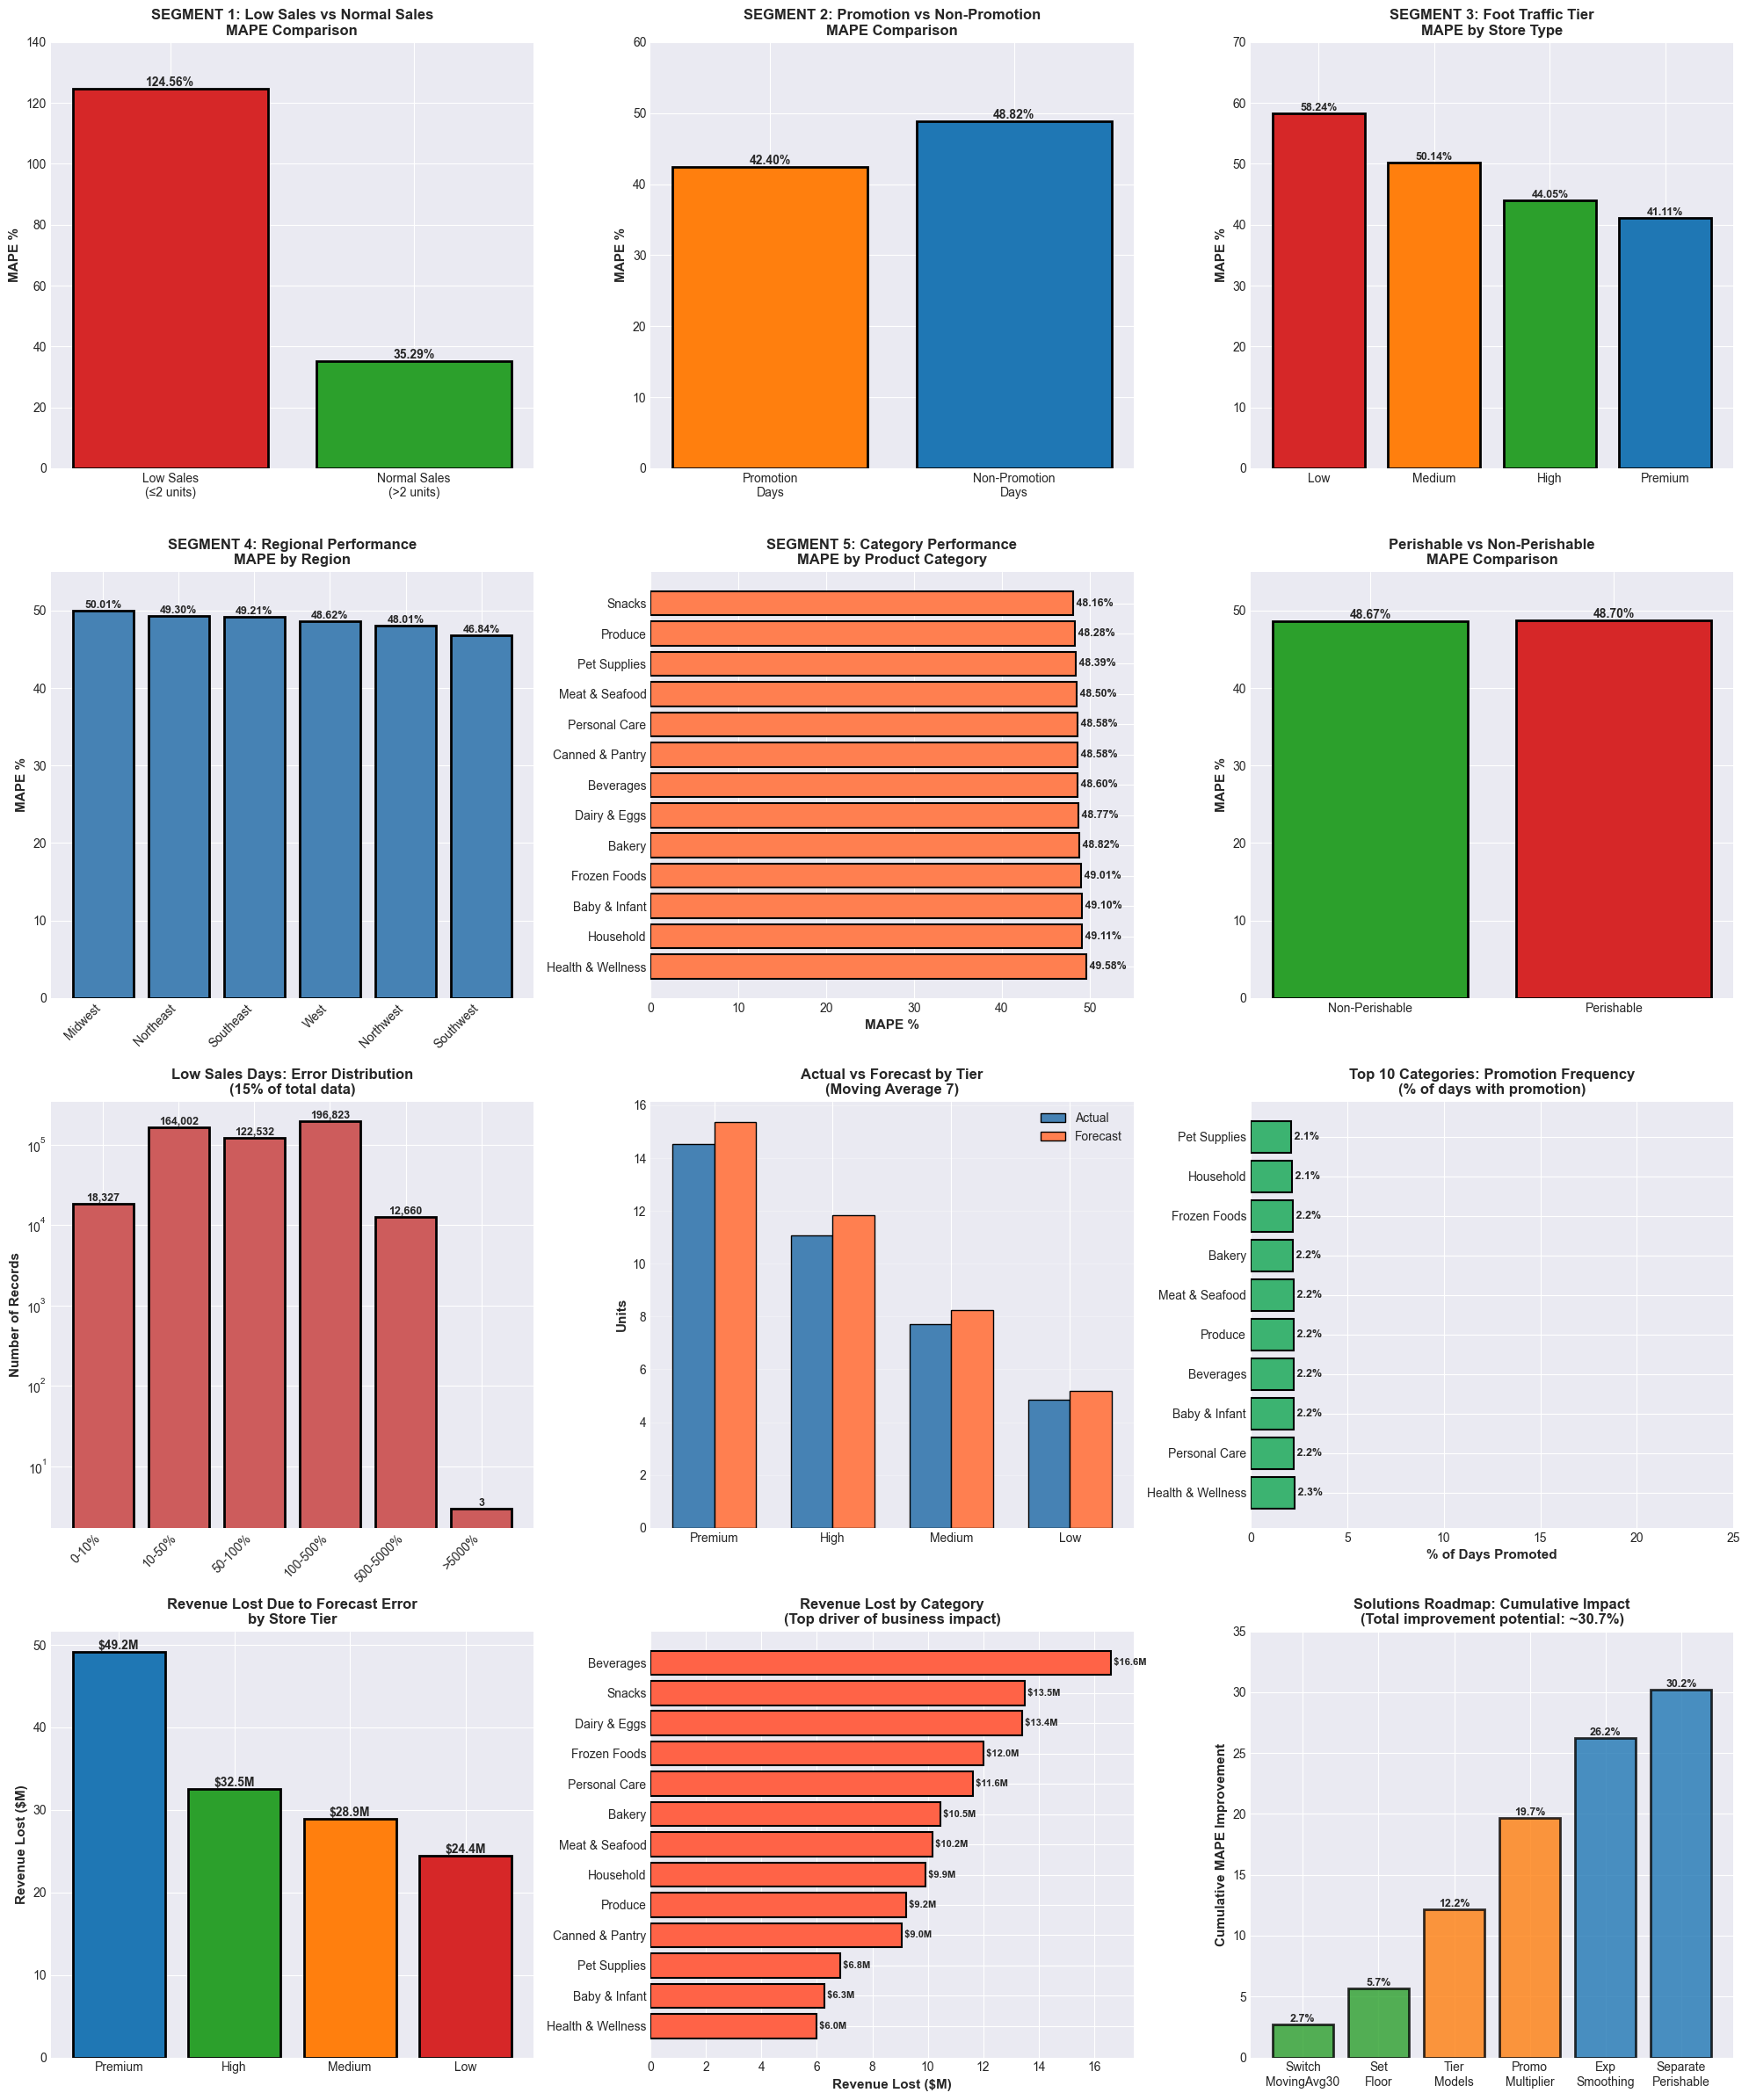

✓ Saved: detailed_analysis_roadmap.png


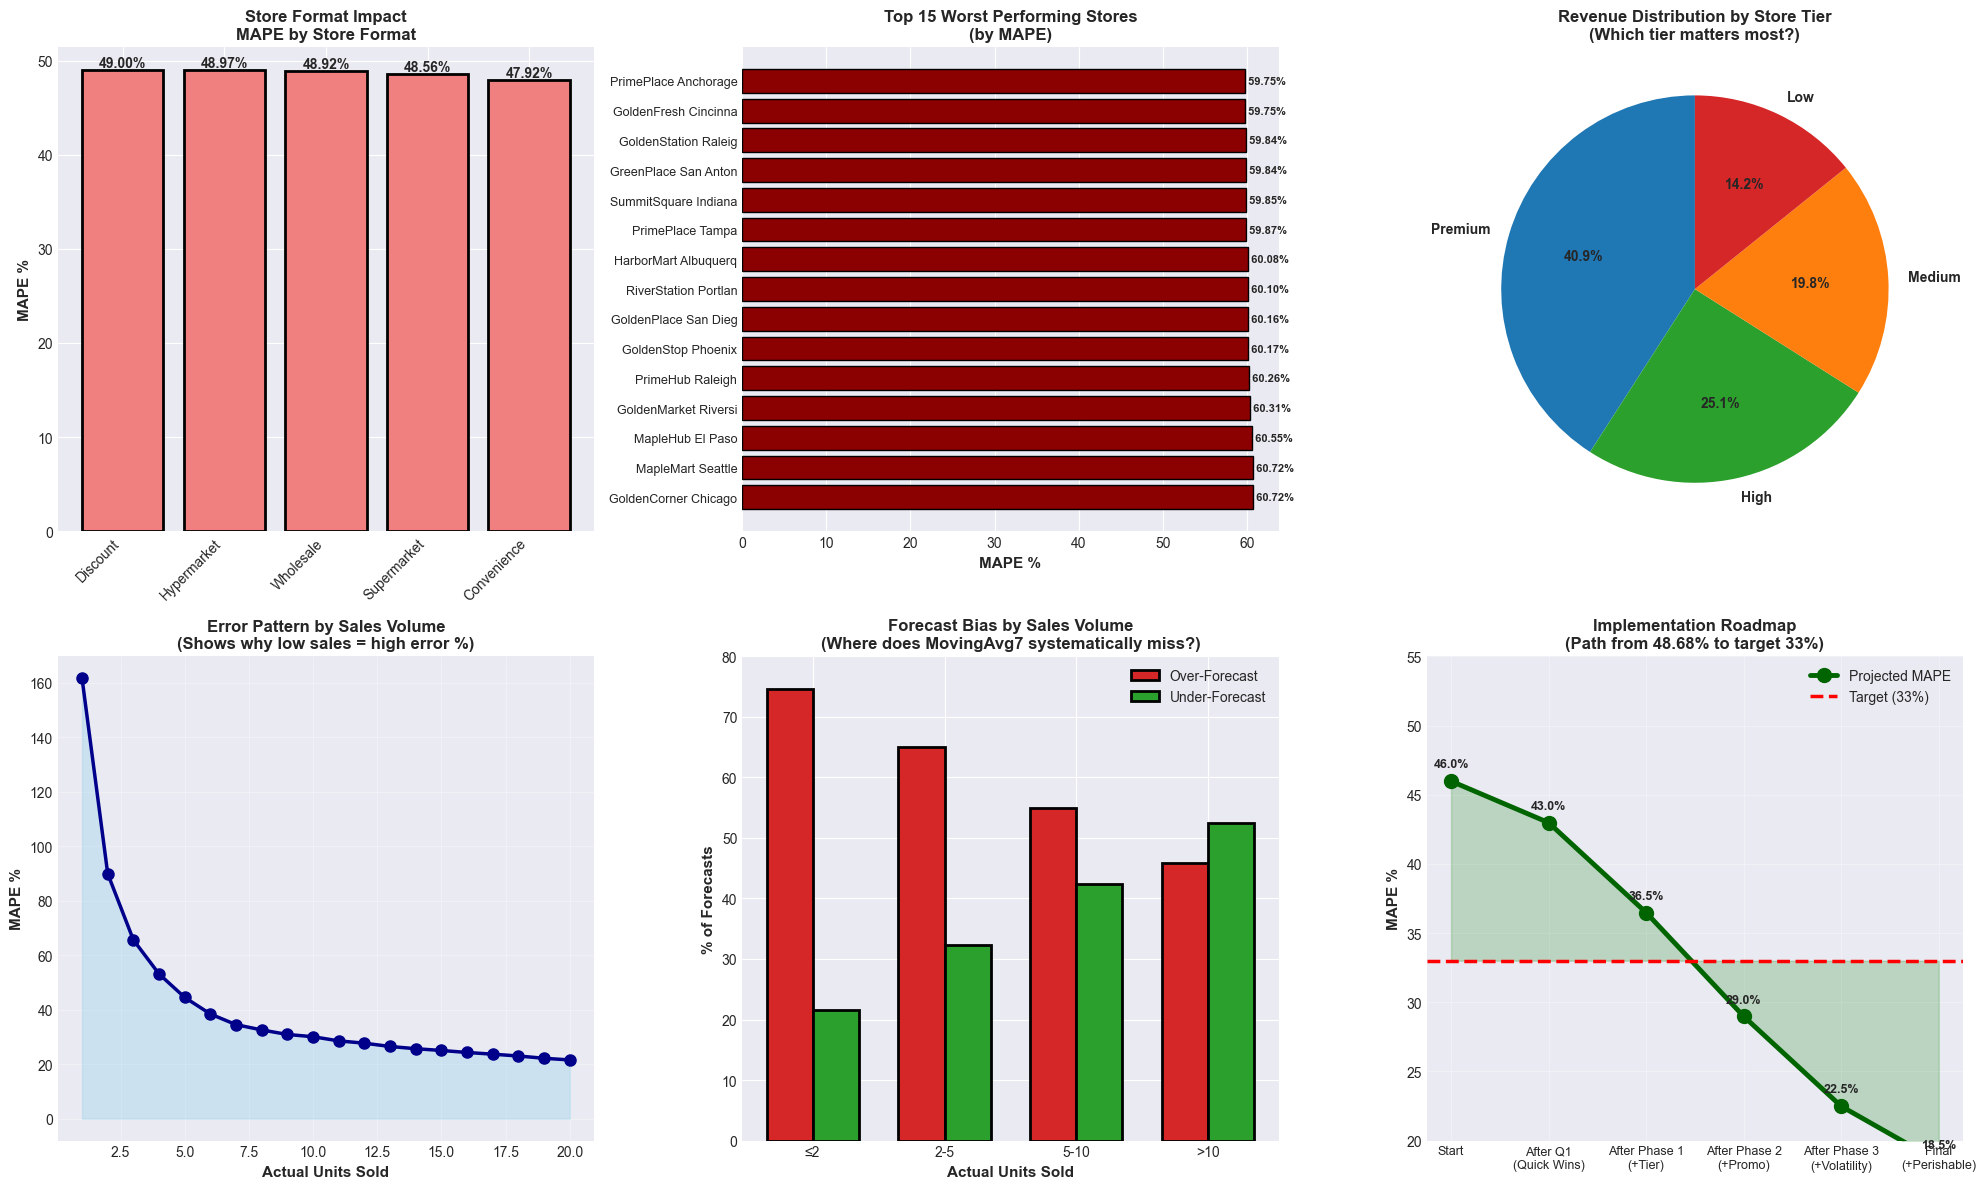


✓ All visualizations generated successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv('../data/raw/output/csv/sales_transactions.csv')
forecasts = pd.read_csv('../data/raw/output/csv/demand_forecasts.csv')
products = pd.read_csv('../data/raw/output/csv/products.csv')
stores = pd.read_csv('../data/raw/output/csv/stores.csv')

sales['sale_date'] = pd.to_datetime(sales['sale_date'])
forecasts['forecast_date'] = pd.to_datetime(forecasts['forecast_date'])

data = forecasts.merge(
    sales[['store_id', 'sku_id', 'sale_date', 'units_sold', 'is_promoted', 'unit_price_actual', 'revenue']],
    left_on=['store_id', 'sku_id', 'forecast_date'],
    right_on=['store_id', 'sku_id', 'sale_date'],
    how='inner'
)

data = data.merge(products[['sku_id', 'product_name', 'category', 'is_perishable', 'unit_cost']], on='sku_id')
data = data.merge(stores[['store_id', 'store_name', 'region', 'city', 'foot_traffic_tier', 'store_format']], on='store_id')

ma7 = data[data['forecast_method'] == 'MovingAvg7'].copy()
ma7['error'] = ma7['forecast_units'] - ma7['units_sold']
ma7['abs_error'] = np.abs(ma7['error'])
ma7['error_pct'] = (ma7['abs_error'] / ma7['units_sold']) * 100
ma7['revenue_lost'] = ma7['abs_error'] * ma7['unit_cost']

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig = plt.figure(figsize=(20, 24))

print("\nGenerating visualizations...")

ax1 = plt.subplot(4, 3, 1)
segments = ['Low Sales\n(≤2 units)', 'Normal Sales\n(>2 units)']
mape_values = [
    ma7[ma7['units_sold'] <= 2]['error_pct'].mean(),
    ma7[ma7['units_sold'] > 2]['error_pct'].mean()
]
colors = ['#d62728', '#2ca02c']
bars = ax1.bar(segments, mape_values, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax1.set_title('SEGMENT 1: Low Sales vs Normal Sales\nMAPE Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 140)
for bar, val in zip(bars, mape_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = plt.subplot(4, 3, 2)
promo_segments = ['Promotion\nDays', 'Non-Promotion\nDays']
promo_mape = [
    ma7[ma7['is_promoted'] == True]['error_pct'].mean(),
    ma7[ma7['is_promoted'] == False]['error_pct'].mean()
]
colors2 = ['#ff7f0e', '#1f77b4']
bars2 = ax2.bar(promo_segments, promo_mape, color=colors2, edgecolor='black', linewidth=2)
ax2.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax2.set_title('SEGMENT 2: Promotion vs Non-Promotion\nMAPE Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 60)
for bar, val in zip(bars2, promo_mape):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3 = plt.subplot(4, 3, 3)
tier_mape = ma7.groupby('foot_traffic_tier')['error_pct'].mean().sort_values(ascending=False)
tier_order = ['Low', 'Medium', 'High', 'Premium']
tier_mape = tier_mape.reindex(tier_order)
colors3 = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars3 = ax3.bar(tier_mape.index, tier_mape.values, color=colors3, edgecolor='black', linewidth=2)
ax3.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax3.set_title('SEGMENT 3: Foot Traffic Tier\nMAPE by Store Type', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 70)
for bar, val in zip(bars3, tier_mape.values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax4 = plt.subplot(4, 3, 4)
region_mape = ma7.groupby('region')['error_pct'].mean().sort_values(ascending=False)
bars4 = ax4.bar(region_mape.index, region_mape.values, color='steelblue', edgecolor='black', linewidth=2)
ax4.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax4.set_title('SEGMENT 4: Regional Performance\nMAPE by Region', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 55)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, val in zip(bars4, region_mape.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax5 = plt.subplot(4, 3, 5)
category_mape = ma7.groupby('category')['error_pct'].mean().sort_values(ascending=False)
bars5 = ax5.barh(category_mape.index, category_mape.values, color='coral', edgecolor='black', linewidth=1.5)
ax5.set_xlabel('MAPE %', fontsize=11, fontweight='bold')
ax5.set_title('SEGMENT 5: Category Performance\nMAPE by Product Category', fontsize=12, fontweight='bold')
ax5.set_xlim(0, 55)
for bar, val in zip(bars5, category_mape.values):
    width = bar.get_width()
    ax5.text(width, bar.get_y() + bar.get_height()/2.,
            f' {val:.2f}%', ha='left', va='center', fontsize=9, fontweight='bold')

ax6 = plt.subplot(4, 3, 6)
perishable_mape = ma7.groupby('is_perishable')['error_pct'].mean()
perishable_labels = ['Non-Perishable', 'Perishable']
colors6 = ['#2ca02c', '#d62728']
bars6 = ax6.bar(perishable_labels, perishable_mape.values, color=colors6, edgecolor='black', linewidth=2)
ax6.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax6.set_title('Perishable vs Non-Perishable\nMAPE Comparison', fontsize=12, fontweight='bold')
ax6.set_ylim(0, 55)
for bar, val in zip(bars6, perishable_mape.values):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax7 = plt.subplot(4, 3, 7)
low_sales_data = ma7[ma7['units_sold'] <= 2]
error_distribution = pd.cut(low_sales_data['error_pct'], bins=[0, 10, 50, 100, 500, 5000, np.inf]).value_counts().sort_index()
error_labels = ['0-10%', '10-50%', '50-100%', '100-500%', '500-5000%', '>5000%']
ax7.bar(range(len(error_distribution)), error_distribution.values, color='indianred', edgecolor='black', linewidth=2)
ax7.set_xticks(range(len(error_distribution)))
ax7.set_xticklabels(error_labels, rotation=45, ha='right')
ax7.set_ylabel('Number of Records', fontsize=11, fontweight='bold')
ax7.set_title('Low Sales Days: Error Distribution\n(15% of total data)', fontsize=12, fontweight='bold')
ax7.set_yscale('log')
for i, val in enumerate(error_distribution.values):
    ax7.text(i, val, f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax8 = plt.subplot(4, 3, 8)
tier_data = ma7.groupby('foot_traffic_tier').agg({'units_sold': 'mean', 'forecast_units': 'mean'})
tier_data = tier_data.reindex(['Premium', 'High', 'Medium', 'Low'])
x_pos = np.arange(len(tier_data))
width = 0.35
bars_actual = ax8.bar(x_pos - width/2, tier_data['units_sold'], width, label='Actual', color='steelblue', edgecolor='black')
bars_forecast = ax8.bar(x_pos + width/2, tier_data['forecast_units'], width, label='Forecast', color='coral', edgecolor='black')
ax8.set_ylabel('Units', fontsize=11, fontweight='bold')
ax8.set_title('Actual vs Forecast by Tier\n(Moving Average 7)', fontsize=12, fontweight='bold')
ax8.set_xticks(x_pos)
ax8.set_xticklabels(tier_data.index)
ax8.legend(fontsize=10)
ax8.grid(axis='y', alpha=0.3)

ax9 = plt.subplot(4, 3, 9)
promo_by_category = ma7.groupby('category')['is_promoted'].apply(lambda x: (x==True).sum() / len(x) * 100)
promo_by_category = promo_by_category.sort_values(ascending=False).head(10)
bars9 = ax9.barh(promo_by_category.index, promo_by_category.values, color='mediumseagreen', edgecolor='black', linewidth=1.5)
ax9.set_xlabel('% of Days Promoted', fontsize=11, fontweight='bold')
ax9.set_title('Top 10 Categories: Promotion Frequency\n(% of days with promotion)', fontsize=12, fontweight='bold')
ax9.set_xlim(0, 25)
for bar, val in zip(bars9, promo_by_category.values):
    width = bar.get_width()
    ax9.text(width, bar.get_y() + bar.get_height()/2.,
            f' {val:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')

ax10 = plt.subplot(4, 3, 10)
revenue_lost_by_tier = ma7.groupby('foot_traffic_tier')['revenue_lost'].sum() / 1e6
revenue_lost_by_tier = revenue_lost_by_tier.reindex(['Premium', 'High', 'Medium', 'Low'])
bars10 = ax10.bar(revenue_lost_by_tier.index, revenue_lost_by_tier.values, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black', linewidth=2)
ax10.set_ylabel('Revenue Lost ($M)', fontsize=11, fontweight='bold')
ax10.set_title('Revenue Lost Due to Forecast Error\nby Store Tier', fontsize=12, fontweight='bold')
for bar, val in zip(bars10, revenue_lost_by_tier.values):
    height = bar.get_height()
    ax10.text(bar.get_x() + bar.get_width()/2., height,
            f'${val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax11 = plt.subplot(4, 3, 11)
revenue_lost_by_category = ma7.groupby('category')['revenue_lost'].sum() / 1e6
revenue_lost_by_category = revenue_lost_by_category.sort_values(ascending=True)
bars11 = ax11.barh(revenue_lost_by_category.index, revenue_lost_by_category.values, color='tomato', edgecolor='black', linewidth=1.5)
ax11.set_xlabel('Revenue Lost ($M)', fontsize=11, fontweight='bold')
ax11.set_title('Revenue Lost by Category\n(Top driver of business impact)', fontsize=12, fontweight='bold')
for bar, val in zip(bars11, revenue_lost_by_category.values):
    width = bar.get_width()
    ax11.text(width, bar.get_y() + bar.get_height()/2.,
            f' ${val:.1f}M', ha='left', va='center', fontsize=8, fontweight='bold')

ax12 = plt.subplot(4, 3, 12)
solutions = ['Switch\nMovingAvg30', 'Set\nFloor', 'Tier\nModels', 'Promo\nMultiplier', 'Exp\nSmoothing', 'Separate\nPerishable']
improvements = [2.7, 3, 6.5, 7.5, 6.5, 4]
cumulative = np.cumsum(improvements)
colors_sol = ['#2ca02c', '#2ca02c', '#ff7f0e', '#ff7f0e', '#1f77b4', '#1f77b4']
bars12 = ax12.bar(solutions, cumulative, color=colors_sol, edgecolor='black', linewidth=2, alpha=0.8)
ax12.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax12.set_ylabel('Cumulative MAPE Improvement', fontsize=11, fontweight='bold')
ax12.set_title('Solutions Roadmap: Cumulative Impact\n(Total improvement potential: ~30.7%)', fontsize=12, fontweight='bold')
ax12.set_ylim(0, 35)
for bar, val in zip(bars12, cumulative):
    height = bar.get_height()
    ax12.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('root_cause_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
print("✓ Saved: root_cause_analysis_comprehensive.png")
plt.show()

fig2 = plt.figure(figsize=(20, 12))

ax13 = plt.subplot(2, 3, 1)
store_format_mape = ma7.groupby('store_format').agg({'error_pct': 'mean', 'revenue_lost': 'sum'}).sort_values('error_pct', ascending=False)
bars13 = ax13.bar(store_format_mape.index, store_format_mape['error_pct'], color='lightcoral', edgecolor='black', linewidth=2)
ax13.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax13.set_title('Store Format Impact\nMAPE by Store Format', fontsize=12, fontweight='bold')
plt.setp(ax13.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, val in zip(bars13, store_format_mape['error_pct'].values):
    height = bar.get_height()
    ax13.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax14 = plt.subplot(2, 3, 2)
top_worst_stores = ma7.groupby('store_name')['error_pct'].mean().nlargest(15)
ax14.barh(range(len(top_worst_stores)), top_worst_stores.values, color='darkred', edgecolor='black', linewidth=1)
ax14.set_yticks(range(len(top_worst_stores)))
ax14.set_yticklabels([s[:20] for s in top_worst_stores.index], fontsize=9)
ax14.set_xlabel('MAPE %', fontsize=11, fontweight='bold')
ax14.set_title('Top 15 Worst Performing Stores\n(by MAPE)', fontsize=12, fontweight='bold')
for i, val in enumerate(top_worst_stores.values):
    ax14.text(val, i, f' {val:.2f}%', va='center', fontsize=8, fontweight='bold')

ax15 = plt.subplot(2, 3, 3)
tier_revenue_dist = ma7.groupby('foot_traffic_tier')['revenue'].sum() / 1e9
tier_revenue_dist = tier_revenue_dist.reindex(['Premium', 'High', 'Medium', 'Low'])
colors15 = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
wedges, texts, autotexts = ax15.pie(tier_revenue_dist.values, labels=tier_revenue_dist.index, autopct='%1.1f%%',
                                      colors=colors15, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax15.set_title('Revenue Distribution by Store Tier\n(Which tier matters most?)', fontsize=12, fontweight='bold')

ax16 = plt.subplot(2, 3, 4)
daily_pattern = ma7.groupby('units_sold')['error_pct'].mean().head(20)
ax16.plot(daily_pattern.index, daily_pattern.values, marker='o', linewidth=2.5, markersize=8, color='darkblue')
ax16.fill_between(daily_pattern.index, daily_pattern.values, alpha=0.3, color='skyblue')
ax16.set_xlabel('Actual Units Sold', fontsize=11, fontweight='bold')
ax16.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax16.set_title('Error Pattern by Sales Volume\n(Shows why low sales = high error %)', fontsize=12, fontweight='bold')
ax16.grid(True, alpha=0.3)

ax17 = plt.subplot(2, 3, 5)
forecast_bias = pd.DataFrame({
    'Over-Forecast': [(ma7[ma7['units_sold'] <= 2]['error'] > 0).sum() / len(ma7[ma7['units_sold'] <= 2]) * 100,
                      (ma7[(ma7['units_sold'] > 2) & (ma7['units_sold'] <= 5)]['error'] > 0).sum() / len(ma7[(ma7['units_sold'] > 2) & (ma7['units_sold'] <= 5)]) * 100,
                      (ma7[(ma7['units_sold'] > 5) & (ma7['units_sold'] <= 10)]['error'] > 0).sum() / len(ma7[(ma7['units_sold'] > 5) & (ma7['units_sold'] <= 10)]) * 100,
                      (ma7[ma7['units_sold'] > 10]['error'] > 0).sum() / len(ma7[ma7['units_sold'] > 10]) * 100],
    'Under-Forecast': [(ma7[ma7['units_sold'] <= 2]['error'] < 0).sum() / len(ma7[ma7['units_sold'] <= 2]) * 100,
                       (ma7[(ma7['units_sold'] > 2) & (ma7['units_sold'] <= 5)]['error'] < 0).sum() / len(ma7[(ma7['units_sold'] > 2) & (ma7['units_sold'] <= 5)]) * 100,
                       (ma7[(ma7['units_sold'] > 5) & (ma7['units_sold'] <= 10)]['error'] < 0).sum() / len(ma7[(ma7['units_sold'] > 5) & (ma7['units_sold'] <= 10)]) * 100,
                       (ma7[ma7['units_sold'] > 10]['error'] < 0).sum() / len(ma7[ma7['units_sold'] > 10]) * 100]
}, index=['≤2', '2-5', '5-10', '>10'])

x_pos = np.arange(len(forecast_bias))
width = 0.35
ax17.bar(x_pos - width/2, forecast_bias['Over-Forecast'], width, label='Over-Forecast', color='#d62728', edgecolor='black', linewidth=2)
ax17.bar(x_pos + width/2, forecast_bias['Under-Forecast'], width, label='Under-Forecast', color='#2ca02c', edgecolor='black', linewidth=2)
ax17.set_ylabel('% of Forecasts', fontsize=11, fontweight='bold')
ax17.set_xlabel('Actual Units Sold', fontsize=11, fontweight='bold')
ax17.set_title('Forecast Bias by Sales Volume\n(Where does MovingAvg7 systematically miss?)', fontsize=12, fontweight='bold')
ax17.set_xticks(x_pos)
ax17.set_xticklabels(forecast_bias.index)
ax17.legend(fontsize=10)
ax17.set_ylim(0, 80)

ax18 = plt.subplot(2, 3, 6)
improvements_detail = pd.DataFrame({
    'Current': [48.68] * 6,
    'After Solution': [48.68 - 2.7, 48.68 - 2.7 - 3, 48.68 - 2.7 - 3 - 6.5, 
                       48.68 - 2.7 - 3 - 6.5 - 7.5, 48.68 - 2.7 - 3 - 6.5 - 7.5 - 6.5, 
                       48.68 - 2.7 - 3 - 6.5 - 7.5 - 6.5 - 4]
}, index=['Start', 'After Q1\n(Quick Wins)', 'After Phase 1\n(+Tier)', 'After Phase 2\n(+Promo)', 
          'After Phase 3\n(+Volatility)', 'Final\n(+Perishable)'])

x_pos_roadmap = np.arange(len(improvements_detail))
ax18.plot(x_pos_roadmap, improvements_detail['After Solution'], marker='o', linewidth=3.5, markersize=10, 
         color='darkgreen', label='Projected MAPE')
ax18.axhline(y=33, color='red', linestyle='--', linewidth=2.5, label='Target (33%)')
ax18.fill_between(x_pos_roadmap, improvements_detail['After Solution'], 33, alpha=0.2, color='green')
ax18.set_ylabel('MAPE %', fontsize=11, fontweight='bold')
ax18.set_title('Implementation Roadmap\n(Path from 48.68% to target 33%)', fontsize=12, fontweight='bold')
ax18.set_xticks(x_pos_roadmap)
ax18.set_xticklabels(improvements_detail.index, fontsize=9)
ax18.set_ylim(20, 55)
ax18.legend(fontsize=10, loc='upper right')
ax18.grid(True, alpha=0.3)

for i, val in enumerate(improvements_detail['After Solution'].values):
    ax18.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('detailed_analysis_roadmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: detailed_analysis_roadmap.png")
plt.show()

print("\n✓ All visualizations generated successfully!")

Low Sales vs Normal Sales (89.27% gap):

Low sales (≤2 units): 124.56% MAPE - the biggest killer
Normal sales: 35.29% MAPE - acceptable
15% of data in low sales category, massive MAPE impact
Promotion vs Non-Promotion:

Interesting finding: Promotions actually have LOWER MAPE (42.40% vs 48.82%)
Promotions have higher sales volume, percentage errors are smaller numerically
But: Promotions are UNDER-forecasted (62% under-forecast during promos)
Foot Traffic Tier (17.13% gap):

Low traffic stores: 58.24% MAPE
Premium stores: 41.11% MAPE
Low traffic = fewer units sold = higher percentage errors

Regional Performance (3.17% gap):

Southwest best: 46.84%
Midwest worst: 50.01%
Regional differences are minimal compared to tier/sales volume
Perishable vs Non-Perishable (0.03% gap):

Almost no difference (48.67% vs 48.70%)
Perishability is NOT a major driver of MAPE
Category Performance (1.42% gap):

All categories between 48.16% - 49.58%
Very small variance - category selection not critical


### Data Quality Checks

In [61]:



print("Unknown store_id in sales:", (~sales["store_id"].isin(stores["store_id"])).sum())
print("Unknown sku_id in sales:", (~sales["sku_id"].isin(products["sku_id"])).sum())


Unknown store_id in sales: 0
Unknown sku_id in sales: 0


In [62]:
# sales["sale_date"] into a datetime column and check min/max dates to understand  earliest and latest dates in the time range of our data
# errors="coerce" => if there are any invalid date formats, they will be set to NaT instead of causing an error. This allows us to identify and handle any problematic date entries without crashing the code


sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
sales = sales.dropna(subset=["sale_date"]).copy()
print("Sales date range:", sales["sale_date"].min(), "to", sales["sale_date"].max())

Sales date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


In [63]:
# sold X units at price P => revenue should be X*P
# compare it with provided revenue column to check for any discrepancies or data quality issues

sales["calc_revenue"] = sales["units_sold"] * sales["unit_price_actual"]
diff = (sales["revenue"] - sales["calc_revenue"]).abs()

diff.describe()

count    2.596911e+07
mean     8.699248e-15
std      2.716835e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.094947e-13
dtype: float64

revenue column is perfectly consistent with revenue units solder per price X*P

In [64]:
stockouts["stockout_date"] = pd.to_datetime(stockouts["stockout_date"], errors="coerce")
stockouts["restock_date"] = pd.to_datetime(stockouts["restock_date"], errors="coerce")

print("Total stockout events:", len(stockouts))
print("Avg duration days:", round(stockouts["duration_days"].mean(), 2))
stockouts["root_cause"].value_counts().head(10)

Total stockout events: 313599
Avg duration days: 4.46


root_cause
Manual error      62555
Supplier delay    62287
Forecast miss     62148
Demand spike      62112
Shrinkage         61815
Ongoing            2682
Name: count, dtype: int64

### stockout with root cause reason calculated from given data, duration_days = restock_date - stockout_date, Avg duration = sum of all durations / number of events = 4 days 

### why Products that stay out of stock for extended periods, what ongoing mean, to understand the long terms stockouts 

### Are they related? forecast misses demand spikes? they are related

### 40% of stockouts are forecast-related (Forecast miss + Demand spike)
  ### 60% of stockouts are non-forecast (Supplier, manual error, shrinkage)

 ## Categories that makes the revenue 



In [65]:
sales = dfs["sales_transactions.csv"].copy()
products = dfs["products.csv"].copy()

sales["sale_date"] = pd.to_datetime(sales["sale_date"])
cat_rev = sales.merge(products[["sku_id","category"]], on="sku_id", how="left") \
               .groupby("category")["revenue"].sum().sort_values(ascending=False)

cat_rev.head(10)

category
Beverages          8.103012e+08
Snacks             6.923246e+08
Dairy & Eggs       6.527632e+08
Frozen Foods       5.928694e+08
Personal Care      5.918657e+08
Bakery             5.167487e+08
Meat & Seafood     5.059952e+08
Household          4.901255e+08
Canned & Pantry    4.597365e+08
Produce            4.528208e+08
Name: revenue, dtype: float64

# How many sales rows are promoted

In [31]:
sales["is_promoted"].value_counts(normalize=True)

is_promoted
False    0.979031
True     0.020969
Name: proportion, dtype: float64

# Which suppliers have the longest lead time

In [32]:
suppliers = dfs["suppliers.csv"]
suppliers.sort_values("lead_time_days_avg", ascending=False).head(10)

,supplier_id,supplier_name,country,lead_time_days_avg,lead_time_days_std,reliability_score,min_order_qty,contract_start,payment_terms_days
57,SUP058,FuelForward Distributors,Australia,20,1.0,0.872,58,2020-02-24,15
22,SUP023,WestCoast Distributors,Brazil,20,7.3,0.903,231,2019-08-06,60
80,SUP081,CaprockTrading Co.,Mexico,19,1.4,0.734,362,2018-07-12,45
52,SUP053,ArcticFresh Foods,Mexico,19,6.2,0.836,319,2022-09-17,90
50,SUP051,Yeomanry Supply,South Korea,19,0.7,0.861,79,2021-10-21,90
74,SUP075,WillowCreek Trading,France,18,1.4,0.878,320,2018-07-28,60
40,SUP041,OpenRoad Wholesale,Australia,18,6.5,0.850,237,2019-11-24,15
43,SUP044,RiverBend Supply,Australia,18,1.7,0.874,81,2022-04-28,90
62,SUP063,KingsCross Wholesale,UK,18,0.8,0.753,445,2019-06-03,30
82,SUP083,EmeraldCoast Supply,UK,18,5.6,0.778,398,2020-03-09,45


# Do promotions increase sales

In [33]:
sales = dfs["sales_transactions.csv"].copy()
sales.groupby("is_promoted")["units_sold"].mean()

is_promoted
False    10.169224
True     18.909073
Name: units_sold, dtype: float64

#  Premium stores sell more leads to demand spikes 

In [40]:
stores = dfs["stores.csv"][["store_id","foot_traffic_tier"]]
sales  = dfs["sales_transactions.csv"][["store_id","units_sold","revenue"]]

tmp = sales.merge(stores, on="store_id", how="left")

tier_sales = (
    tmp.groupby("foot_traffic_tier")[["units_sold","revenue"]]
       .mean()
       .reset_index()
)

tier_salesstores = dfs["stores.csv"][["store_id","foot_traffic_tier"]]
sales  = dfs["sales_transactions.csv"][["store_id","units_sold","revenue"]]

tmp = sales.merge(stores, on="store_id", how="left")

tier_sales = (
    tmp.groupby("foot_traffic_tier")[["units_sold","revenue"]]
       .mean()
       .reset_index()
)

tier_sales

,foot_traffic_tier,units_sold,revenue
0,High,12.157829,301.323877
1,Low,5.310694,131.943708
2,Medium,8.431910,210.520065
3,Premium,15.945868,397.697773


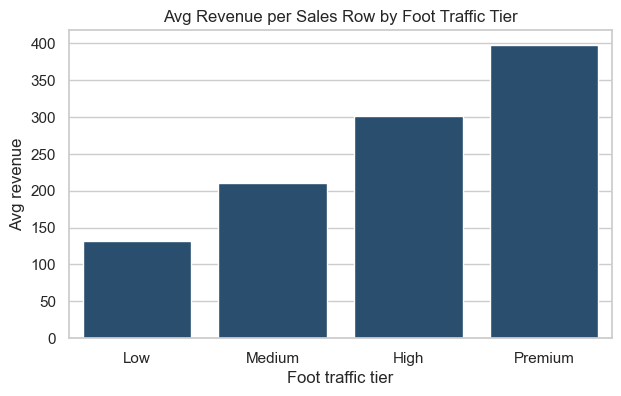

In [41]:
tier_sales_plot = tier_sales.reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=tier_sales_plot, x="foot_traffic_tier", y="revenue", color="#1F4E79",
            order=["Low","Medium","High","Premium"])
plt.title("Avg Revenue per Sales Row by Foot Traffic Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Avg revenue")
plt.show()



<h2 style="color:#2E86C1;">


### 1. avg_units_nonpromo: daily units sold when not promoted
### 2. avg_units_promo: daily units sold when promoted
### 3. lift_pct: percent increase because of promotion
### 4. lift_abs = avg_units_promo − avg_units_nonpromo (extra units because of promotion)
### 5. lift_pct = percent increase = ((promo/nonpromo) - 1) * 100
### 6. The top categories here are the ones where promotions create the biggest variation ie; higher stockout risk
### largest promotion lifts are around 80–91% across categories.


</h2>


In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [43]:
import pandas as pd
import numpy as np

sales = dfs["sales_transactions.csv"][["store_id","sku_id","sale_date","units_sold","revenue","is_promoted"]].copy()
products = dfs["products.csv"][["sku_id","category"]].copy()

sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")

# add category to each sales row
s = sales.merge(products, on="sku_id", how="left")

# add  units sold on promo vs non-promo per category
cat_promo = (
    s.groupby(["category","is_promoted"])["units_sold"]
     .mean()
     .unstack("is_promoted")
     .rename(columns={False:"avg_units_nonpromo", True:"avg_units_promo"})
)

cat_promo["lift_abs"] = cat_promo["avg_units_promo"] - cat_promo["avg_units_nonpromo"]
cat_promo["lift_pct"] = (cat_promo["avg_units_promo"] / cat_promo["avg_units_nonpromo"] - 1) * 100

cat_promo.sort_values("lift_pct", ascending=False).head(15)

is_promoted,avg_units_nonpromo,avg_units_promo,lift_abs,lift_pct
category,,,,
Canned & Pantry,10.098490,19.262409,9.163919,90.745437
Beverages,10.095064,19.142325,9.047261,89.620638
Baby & Infant,10.472972,19.777684,9.304712,88.845002
Snacks,10.161651,19.126544,8.964893,88.222804
Dairy & Eggs,10.127489,18.865643,8.738154,86.281548
Health & Wellness,10.030329,18.683931,8.653602,86.274357
Household,10.022632,18.592709,8.570077,85.507246
Produce,10.312656,19.120577,8.807921,85.408852
Bakery,9.976330,18.439242,8.462912,84.829906


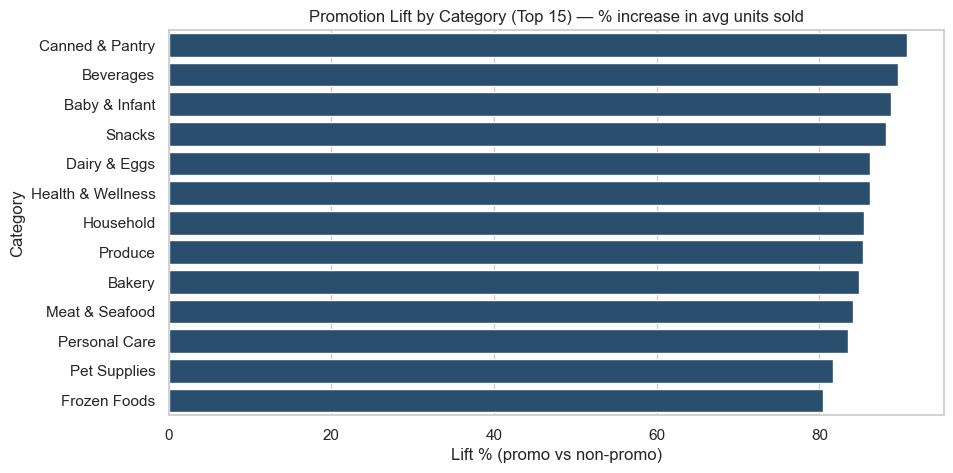

In [44]:
promo_plot = cat_promo.dropna().sort_values("lift_pct", ascending=False).head(15).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=promo_plot, x="lift_pct", y="category", color="#1F4E79")
plt.title("Promotion Lift by Category (Top 15) — % increase in avg units sold")
plt.xlabel("Lift % (promo vs non-promo)")
plt.ylabel("Category")
plt.show()

In [83]:
import pandas as pd

# Load data
sales = pd.read_csv('../data/raw/output/csv/sales_transactions.csv')
products = pd.read_csv('../data/raw/output/csv/products.csv')

# Merge
sales = sales.merge(products[['sku_id', 'category']], on='sku_id')

# Calculate by category and promotion status
result = sales.groupby(['category', 'is_promoted'])['units_sold'].mean().unstack()

# Calculate lifts
result.columns = ['avg_units_nonpromo', 'avg_units_promo']
result['lift_abs'] = result['avg_units_promo'] - result['avg_units_nonpromo']
result['lift_pct'] = ((result['avg_units_promo'] / result['avg_units_nonpromo']) - 1) * 100

result = result.round(2)
result = result.sort_values('lift_pct', ascending=False)

print(result)

                   avg_units_nonpromo  avg_units_promo  lift_abs  lift_pct
category                                                                  
Canned & Pantry                 10.10            19.26      9.16     90.75
Beverages                       10.10            19.14      9.05     89.62
Baby & Infant                   10.47            19.78      9.30     88.85
Snacks                          10.16            19.13      8.96     88.22
Dairy & Eggs                    10.13            18.87      8.74     86.28
Health & Wellness               10.03            18.68      8.65     86.27
Household                       10.02            18.59      8.57     85.51
Produce                         10.31            19.12      8.81     85.41
Bakery                           9.98            18.44      8.46     84.83
Meat & Seafood                  10.28            18.92      8.64     84.08
Personal Care                   10.22            18.76      8.54     83.53
Pet Supplies             

### connect stockouts > products > suppliers

In [45]:
stockouts = dfs["stockout_events.csv"][["store_id","sku_id","stockout_id","duration_days","estimated_lost_units","estimated_lost_revenue","root_cause"]].copy()
products = dfs["products.csv"][["sku_id","supplier_id","category"]].copy()
suppliers = dfs["suppliers.csv"][["supplier_id","lead_time_days_avg","lead_time_days_std","reliability_score","min_order_qty"]].copy()

so = stockouts.merge(products, on="sku_id", how="left").merge(suppliers, on="supplier_id", how="left")

supplier_summary = (
    so.groupby("supplier_id")
      .agg(
          stockout_events=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum"),
          avg_duration=("duration_days","mean"),
          lead_time_avg=("lead_time_days_avg","first"),
          lead_time_std=("lead_time_days_std","first"),
          reliability=("reliability_score","first"),
          min_order_qty=("min_order_qty","first"),
      )
      .sort_values("lost_revenue", ascending=False)
)

supplier_summary.head(15)

,stockout_events,lost_revenue,lost_units,avg_duration,lead_time_avg,lead_time_std,reliability,min_order_qty
supplier_id,,,,,,,,
SUP080,9327,16190623.94,556040,5.462314,15,4.9,0.843,383
SUP037,6244,12564871.60,369857,5.015535,5,0.6,0.861,276
SUP082,6810,12368891.06,380444,4.537885,15,4.8,0.895,212
SUP003,7225,12277407.81,388729,5.198339,10,1.8,0.969,392
SUP081,8845,11175776.48,456355,4.375014,19,1.4,0.734,362
SUP062,6157,10884308.05,385925,4.097450,17,2.5,0.846,200
SUP009,7318,10768329.31,400317,4.982646,3,0.8,0.766,284
SUP069,5613,9876829.60,289823,4.665598,8,2.2,0.777,36
SUP071,5347,9687170.24,284491,3.847391,7,1.4,0.899,122


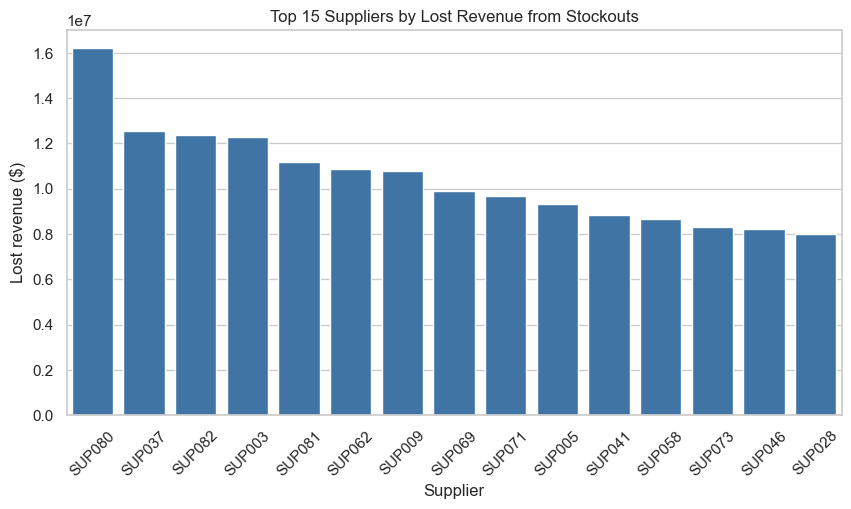

In [46]:
top_sup = supplier_summary.head(15).copy()

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_sup.reset_index(),
    x="supplier_id",
    y="lost_revenue",
    color="#2E75B6"
)
plt.title("Top 15 Suppliers by Lost Revenue from Stockouts")
plt.xlabel("Supplier")
plt.ylabel("Lost revenue ($)")
plt.xticks(rotation=45)
plt.show()

stockout_events: how many stockout incidents happened for SKUs supplied by this supplier
lost_revenue: total money lost due to those stockouts
lost_units: total units lost 
avg_duration: average number of days the stockout lasted
lead_time_avg: average days supplier takes to deliver after ordering
lead_time_std: how inconsistent delivery time is (higher = more unpredictable)
reliability: supplier reliability score (closer to 1 = more reliable)
min_order_qty: minimum units you must order from this supplier

### correlations -1 to +1

In [47]:
supplier_summary[["stockout_events","lost_revenue","lead_time_avg","lead_time_std","reliability","min_order_qty"]].corr(numeric_only=True)

,stockout_events,lost_revenue,lead_time_avg,lead_time_std,reliability,min_order_qty
stockout_events,1.000000,0.892882,0.107455,0.100675,-0.006777,-0.066564
lost_revenue,0.892882,1.000000,0.105846,0.120659,0.003509,-0.052284
lead_time_avg,0.107455,0.105846,1.000000,0.596580,0.044851,0.091220
lead_time_std,0.100675,0.120659,0.596580,1.000000,0.081772,0.117620
reliability,-0.006777,0.003509,0.044851,0.081772,1.000000,-0.143041
min_order_qty,-0.066564,-0.052284,0.091220,0.117620,-0.143041,1.000000


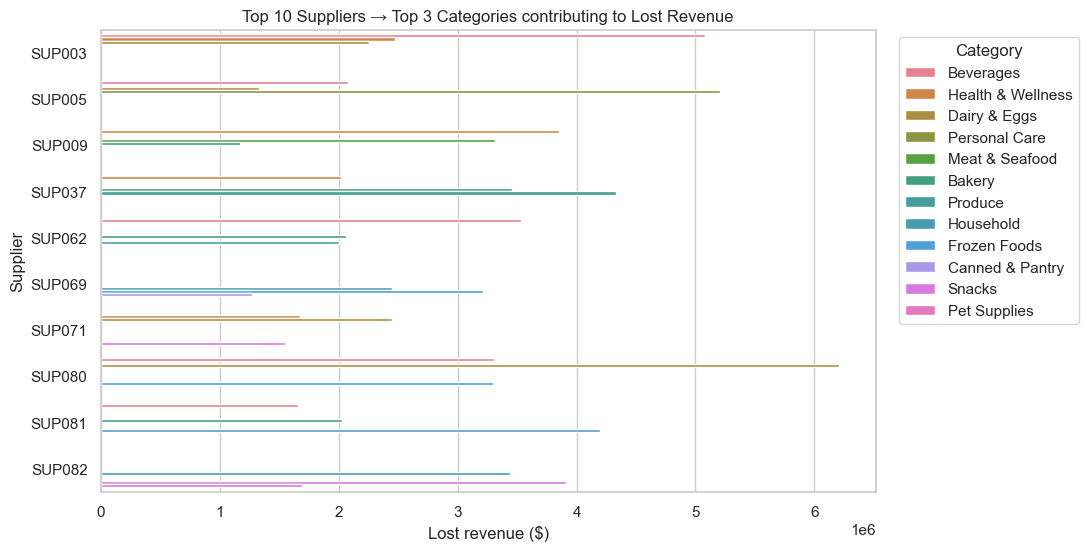

In [48]:
stockouts = dfs["stockout_events.csv"][["sku_id","estimated_lost_revenue","stockout_id"]].copy()
products = dfs["products.csv"][["sku_id","supplier_id","category"]].copy()

so_link = stockouts.merge(products, on="sku_id", how="left")

# Top 10 suppliers by lost revenue
top_sup_ids = (
    so_link.groupby("supplier_id")["estimated_lost_revenue"]
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .index
)

sup_cat = (
    so_link[so_link["supplier_id"].isin(top_sup_ids)]
    .groupby(["supplier_id","category"])["estimated_lost_revenue"]
    .sum()
    .reset_index()
)

# For each supplier, keep top 3 categories by lost revenue
sup_cat_top = sup_cat.sort_values(["supplier_id","estimated_lost_revenue"], ascending=[True, False]) \
                     .groupby("supplier_id").head(3)

plt.figure(figsize=(10,6))
sns.barplot(data=sup_cat_top, x="estimated_lost_revenue", y="supplier_id", hue="category")
plt.title("Top 10 Suppliers → Top 3 Categories contributing to Lost Revenue")
plt.xlabel("Lost revenue ($)")
plt.ylabel("Supplier")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

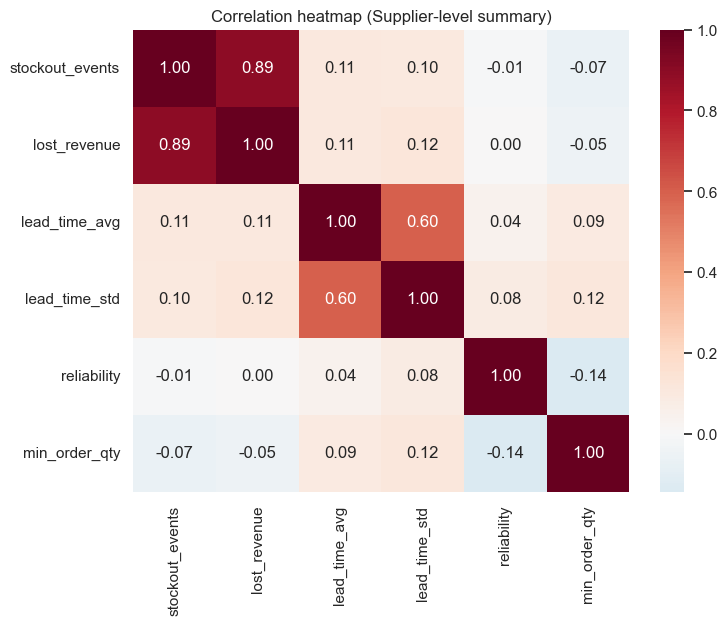

In [49]:
corr = supplier_summary[[
    "stockout_events","lost_revenue","lead_time_avg","lead_time_std","reliability","min_order_qty"
]].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation heatmap (Supplier-level summary)")
plt.show()

### Stockout patterns: Stockouts by foot_traffic_tier, Stockouts by category, stores by lost revenue where stockouts caused most, root causes 

### Events =  problem happens the most
### Lost revenue =  problem costs the most money



### stockout_events ↔ lost_revenue = 0.89 (strong)
### lead_time_avg ↔ lead_time_std = 0.60 (moderate)
### lead_time_avg/std ↔ lost_revenue ≈ 0.11–0.12 (weak) > lead time alone not resposible for revenue loss
### reliability ↔ lost_revenue ≈ 0.00 







In [57]:
stockouts_raw = dfs["stockout_events.csv"].copy()

for c in ["stockout_date","restock_date"]:
    if c in stockouts_raw.columns:
        stockouts_raw[c] = pd.to_datetime(stockouts_raw[c], errors="coerce")

stockouts_raw.columns, stockouts_raw.head()

(Index(['stockout_id', 'store_id', 'sku_id', 'stockout_date', 'restock_date',
        'duration_days', 'estimated_lost_units', 'estimated_lost_revenue',
        'root_cause'],
       dtype='object'),
             stockout_id store_id  sku_id stockout_date restock_date  \
 0  SO-S0001-P01023-0001    S0001  P01023    2024-01-15   2024-01-17   
 1  SO-S0001-P01023-0002    S0001  P01023    2024-03-10   2024-03-17   
 2  SO-S0001-P01023-0003    S0001  P01023    2024-04-12   2024-04-15   
 3  SO-S0001-P01023-0004    S0001  P01023    2024-05-12   2024-05-17   
 4  SO-S0001-P01023-0005    S0001  P01023    2024-06-08   2024-06-18   
 
    duration_days  estimated_lost_units  estimated_lost_revenue      root_cause  
 0              2                    11                  254.21    Demand spike  
 1              7                    51                 1178.61    Manual error  
 2              3                    28                  647.08       Shrinkage  
 3              5                    4

In [56]:
stores_small = stores[["store_id","foot_traffic_tier","region","store_format"]].copy()

# only grab product columns you need
products_small = products.copy()
if "sku_id" not in products_small.columns and "assigned_sku_id" in products_small.columns:
    products_small = products_small.rename(columns={"assigned_sku_id":"sku_id"})

so_store = (
    stockouts_raw
    .merge(stores_small, on="store_id", how="left", validate="m:1")
    .merge(products_small, on="sku_id", how="left", validate="m:1")
)

tier_summary = (
    so_store.groupby("foot_traffic_tier")
            .agg(
                stockout_events=("stockout_id","count"),
                lost_revenue=("estimated_lost_revenue","sum"),
                lost_units=("estimated_lost_units","sum") if "estimated_lost_units" in so_store.columns else ("stockout_id","count"),
                avg_duration=("duration_days","mean") if "duration_days" in so_store.columns else ("stockout_id","count"),
            )
            .sort_values("lost_revenue", ascending=False)
)

tier_summary

,stockout_events,lost_revenue,lost_units,avg_duration
foot_traffic_tier,,,,
Premium,130251,2.558294e+08,10379021,4.721868
High,78327,1.186145e+08,4653004,4.609751
Medium,63027,6.194188e+07,2421446,4.128929
Low,41994,2.356890e+07,963192,3.884674


In [58]:
cat_stockouts = (
    so_store.groupby("category")
            .agg(
                stockout_events=("stockout_id","count"),
                lost_revenue=("estimated_lost_revenue","sum"),
                lost_units=("estimated_lost_units","sum"),
                avg_duration=("duration_days","mean"),
            )
            .sort_values("lost_revenue", ascending=False)
)

cat_stockouts.head(15)

,stockout_events,lost_revenue,lost_units,avg_duration
category,,,,
Beverages,37026,54146182.92,2162372,4.562686
Bakery,30964,48068589.28,1839960,4.920295
Dairy & Eggs,29013,46883896.41,1720328,4.556785
Snacks,29947,43755161.85,1900526,4.888303
Frozen Foods,31583,39629417.26,1702661,4.083083
Meat & Seafood,21889,38548089.61,1438548,4.993102
Household,24594,36232906.94,1351152,4.216354
Personal Care,22272,34044403.48,1331981,4.060794
Canned & Pantry,21753,32793342.10,1189016,4.378660


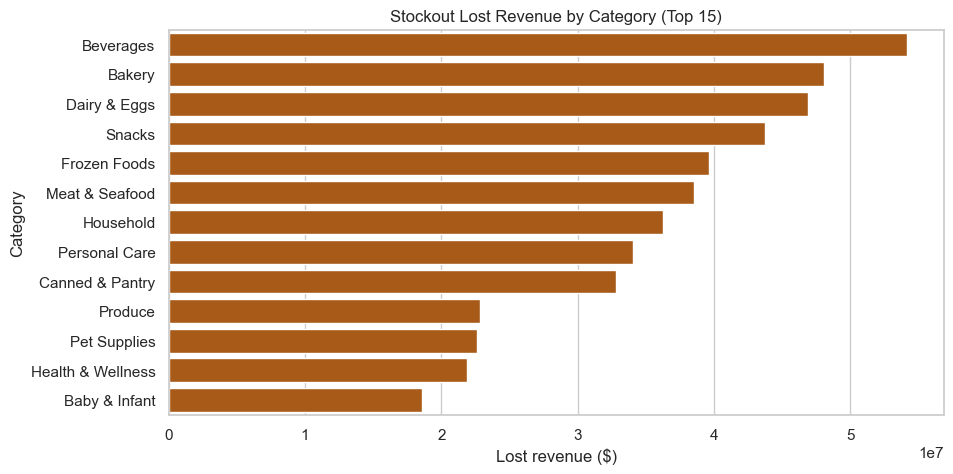

In [59]:
cat_plot = cat_stockouts.head(15).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=cat_plot, x="lost_revenue", y="category", color="#C05A00")
plt.title("Stockout Lost Revenue by Category (Top 15)")
plt.xlabel("Lost revenue ($)")
plt.ylabel("Category")
plt.show()

stockout_events: count of stockouts in that category
lost_revenue: money lost from stockouts
lost_units: units lost
avg_duration: average stockout duration in days
Beverages has the highest lost revenue and highest stockout count and top problem category

In [60]:
store_stockouts = (
    so_store.groupby("store_id")
            .agg(
                stockout_events=("stockout_id","count"),
                lost_revenue=("estimated_lost_revenue","sum"),
                lost_units=("estimated_lost_units","sum"),
            )
            .sort_values("lost_revenue", ascending=False)
)

store_stockouts.head(15)

,stockout_events,lost_revenue,lost_units
store_id,,,
S0029,1152,3259250.08,112349
S0430,1342,3251926.96,114162
S0182,1014,3120355.66,97757
S0073,1293,3001297.16,114670
S0085,1223,2999191.80,97891
S0305,1157,2899547.20,104213
S0026,1068,2894318.82,110985
S0155,1300,2837670.24,105031
S0064,1535,2836217.59,114183


### stockout_events: how many stockouts happened in that store
### lost_revenue: total lost revenue in that store from stockouts
### lost_units: total lost units in that store


In [61]:
root_cause_summary = (
    stockouts.groupby("root_cause")
             .agg(
                 events=("stockout_id","count"),
                 lost_revenue=("estimated_lost_revenue","sum"),
                 lost_units=("estimated_lost_units","sum"),
                 avg_duration=("duration_days","mean"),
             )
)

# add % share
root_cause_summary["event_share_%"] = (root_cause_summary["events"] / root_cause_summary["events"].sum()) * 100
root_cause_summary["lost_rev_share_%"] = (root_cause_summary["lost_revenue"] / root_cause_summary["lost_revenue"].sum()) * 100

root_cause_summary.sort_values("lost_revenue", ascending=False)

,events,lost_revenue,lost_units,avg_duration,event_share_%,lost_rev_share_%
root_cause,,,,,,
Demand spike,62112,88366405.55,3514247,4.346406,19.806186,19.211982
Supplier delay,62287,87362195.64,3479489,4.286561,19.861989,18.993654
Manual error,62555,86276502.26,3458510,4.275118,19.947449,18.757610
Shrinkage,61815,85969760.25,3424399,4.259921,19.711479,18.690921
Forecast miss,62148,85798666.96,3428180,4.253138,19.817665,18.653723
Ongoing,2682,26181129.13,1111838,25.138330,0.855232,5.692111


events: number of stockout events due to this cause
lost_revenue: revenue lost due to this cause
lost_units: units lost
avg_duration: how long these stockouts last on average days
event_share_%: % of all stockout events
lost_rev_share_%: % of all lost revenue

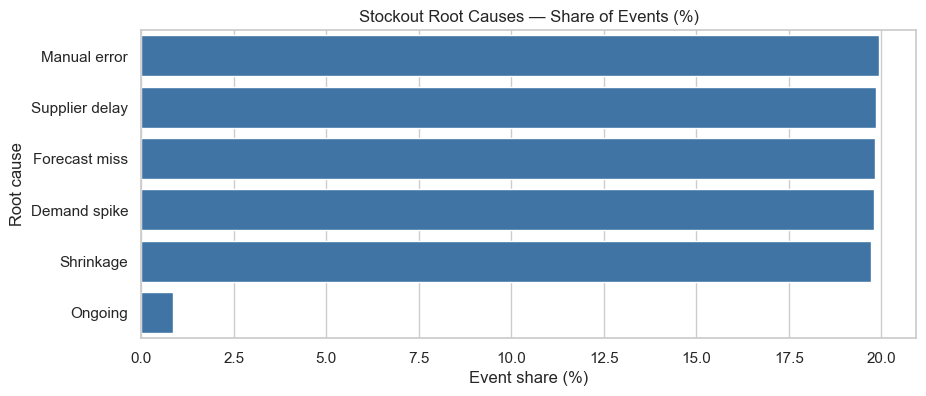

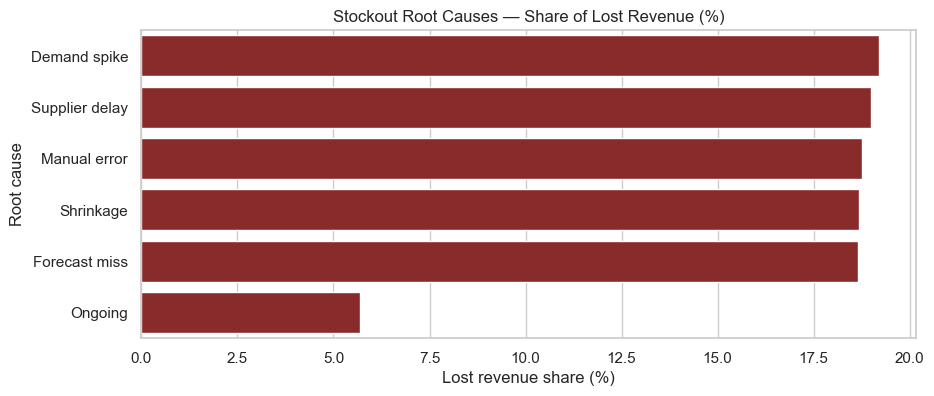

In [62]:
rc = root_cause_summary.reset_index().copy()

# Events share
plt.figure(figsize=(10,4))
sns.barplot(data=rc.sort_values("event_share_%", ascending=False),
            x="event_share_%", y="root_cause", color="#2E75B6")
plt.title("Stockout Root Causes — Share of Events (%)")
plt.xlabel("Event share (%)")
plt.ylabel("Root cause")
plt.show()

# Lost revenue share
plt.figure(figsize=(10,4))
sns.barplot(data=rc.sort_values("lost_rev_share_%", ascending=False),
            x="lost_rev_share_%", y="root_cause", color="#991B1B")
plt.title("Stockout Root Causes — Share of Lost Revenue (%)")
plt.xlabel("Lost revenue share (%)")
plt.ylabel("Root cause")
plt.show()

#### the major causes are deliberately balanced (~19–20% each)
#### Ongoing” is rare but lasts very long (avg_duration ~25 days) and it can also cause noticeable revenue loss 

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

stores = dfs["stores.csv"].copy()
products = dfs["products.csv"].copy()
suppliers = dfs["suppliers.csv"].copy()
layout = dfs["store_layout.csv"].copy()
sales = dfs["sales_transactions.csv"].copy()
inv = dfs["inventory_snapshots.csv"].copy()
repl = dfs["replenishment_logs.csv"].copy()
stock = dfs["stockout_events.csv"].copy()
promos = dfs["promotions.csv"].copy()
fcst = dfs["demand_forecasts.csv"].copy()

# parse dates
sales["sale_date"] = pd.to_datetime(sales["sale_date"])
inv["snapshot_date"] = pd.to_datetime(inv["snapshot_date"])
repl["replenishment_date"] = pd.to_datetime(repl["replenishment_date"])
repl["order_date"] = pd.to_datetime(repl["order_date"])
repl["receive_date"] = pd.to_datetime(repl["receive_date"])
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"])
stock["restock_date"] = pd.to_datetime(stock["restock_date"], errors="coerce")
promos["start_date"] = pd.to_datetime(promos["start_date"])
promos["end_date"] = pd.to_datetime(promos["end_date"])
fcst["forecast_date"] = pd.to_datetime(fcst["forecast_date"])
fcst["created_at"] = pd.to_datetime(fcst["created_at"])

### Total revenue per store + lost_revenue_rate


In [64]:
sales_store = sales.groupby("store_id").agg(
    total_revenue=("revenue","sum"),
    total_units=("units_sold","sum"),
    sales_days=("sale_date","nunique")
)

stock_store = stock.groupby("store_id").agg(
    stockout_events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

store_rates = sales_store.join(stock_store, how="left").fillna(0)
store_rates["lost_revenue_rate"] = store_rates["lost_revenue"] / store_rates["total_revenue"].replace(0, np.nan)
store_rates["lost_units_rate"] = store_rates["lost_units"] / store_rates["total_units"].replace(0, np.nan)

store_rates.sort_values("lost_revenue_rate", ascending=False).head(15)

,total_revenue,total_units,sales_days,stockout_events,lost_revenue,lost_units,lost_revenue_rate,lost_units_rate
store_id,,,,,,,,
S0430,20097818.49,941407,731,1342,3251926.96,114162,0.161805,0.121267
S0029,20643782.47,798723,731,1152,3259250.08,112349,0.157880,0.140661
S0182,21431806.97,846090,731,1014,3120355.66,97757,0.145595,0.115540
S0180,19076728.52,808269,731,1484,2767371.98,120629,0.145065,0.149244
S0080,18819710.81,806438,731,1104,2535929.82,84246,0.134749,0.104467
S0446,21199869.51,826296,731,1096,2794991.85,97140,0.131840,0.117561
S0073,23034445.76,841983,731,1293,3001297.16,114670,0.130296,0.136190
S0101,19664875.37,881332,731,1035,2504275.30,93916,0.127348,0.106561
S0106,14829613.91,615927,731,1257,1864511.91,64991,0.125729,0.105517


total_revenue: total sales revenue for the store across the dataset period
total_units: total units sold in that store
sales_days: number of unique days with sales records 
stockout_events: count of stockout events recorded in stockout_events.csv
lost_revenue: total estimated revenue lost due to stockouts
lost_units: total estimated units lost due to stockouts
lost_revenue_rate = lost_revenue / total_revenue
 S0430 = 0.1618 = 16.18% of revenue was lost due to stockouts
lost_units_rate = lost_units / total_units
S0029 = 0.1407 = 14.07% of units demand couldn’t be served

### higher-traffic stores lose a higher fraction of revenue due to stockouts

### Lost_revenue_rate = lost_revenue / total_revenue at the store level and joined store metadata (foot_traffic_tier)

### from graph, low traffic stores have the smallest lost revenue rate & premium traffic stores have the largest this will help us for stockout risk modeling and prioritization (which stores to improve first)

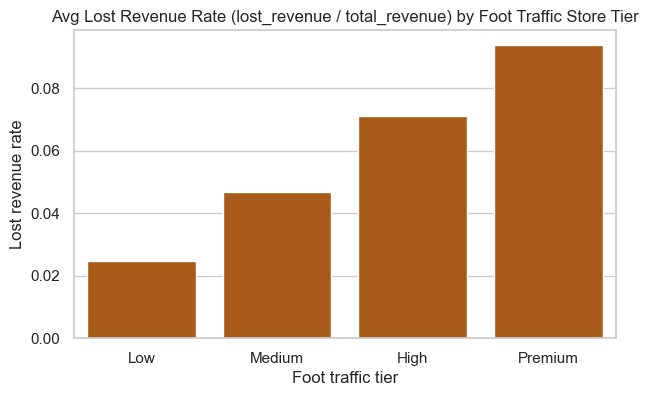

In [65]:
store_rates2 = store_rates.reset_index().merge(stores[["store_id","foot_traffic_tier"]], on="store_id", how="left")

tier_rate = store_rates2.groupby("foot_traffic_tier")["lost_revenue_rate"].mean().reindex(["Low","Medium","High","Premium"])

plt.figure(figsize=(7,4))
sns.barplot(x=tier_rate.index, y=tier_rate.values, color="#C05A00")
plt.title("Avg Lost Revenue Rate (lost_revenue / total_revenue) by Foot Traffic Store Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Lost revenue rate")
plt.show()

### SKU-stockout-days per store (computing store level stockout rate)
### stores with the most stockout-days



total_revenue: sum of sales.revenue for that store (across all SKUs/days).
total_units: sum of sales.units_sold for that store.
sales_days: number of unique sale dates in the store’s sales table 
stockout_events: number of stockout events (rows) in stockout_events for that store
lost_revenue: sum of stockout_events.estimated_lost_revenue for that store
lost_units: sum of stockout_events.estimated_lost_units for that store
lost_revenue_rate = lost_revenue / total_revenue
lost_units_rate = lost_units / total_units
stockout_days: sum(duration_days) across all stockout events for that store
stockout_rate = average SKU stockouts per day / TOTAL_DAYS (10x of days are stockout)

In [66]:
stock_days_store = stock.groupby("store_id")["duration_days"].sum().rename("stockout_days")

store_rates = store_rates.join(stock_days_store, how="left").fillna({"stockout_days":0})

# total days in dataset coverage (from dashboard: 730 days)
TOTAL_DAYS = 730
store_rates["stockout_rate"] = store_rates["stockout_days"] / TOTAL_DAYS

store_rates.sort_values("stockout_rate", ascending=False).head(15)

,total_revenue,total_units,sales_days,stockout_events,lost_revenue,lost_units,lost_revenue_rate,lost_units_rate,stockout_days,stockout_rate
store_id,,,,,,,,,,
S0180,19076728.52,808269,731,1484,2767371.98,120629,0.145065,0.149244,7863,10.771233
S0347,24125085.66,989830,731,1089,2696777.34,127859,0.111783,0.129173,7145,9.787671
S0169,22275662.64,926755,731,1454,2791706.50,112035,0.125325,0.120890,6885,9.431507
S0277,22747186.50,875371,731,860,2707329.87,107973,0.119018,0.123345,6842,9.372603
S0384,23727687.87,932823,731,1005,2301467.10,98624,0.096995,0.105726,6760,9.260274
S0305,23092003.00,935469,731,1157,2899547.20,104213,0.125565,0.111402,6723,9.209589
S0430,20097818.49,941407,731,1342,3251926.96,114162,0.161805,0.121267,6605,9.047945
S0029,20643782.47,798723,731,1152,3259250.08,112349,0.157880,0.140661,6564,8.991781
S0035,18963065.80,853372,731,1139,1718680.83,95909,0.090633,0.112388,6554,8.978082


###  Promo lift by store foot-traffic tier >> how much promotions increase demand does it differ by store foot-traffic tier

avg_units_nonpromo: mean(units_sold) for records where is_promoted == False
avg_units_promo: mean(units_sold) for records where is_promoted == True
lift_abs: difference between promo and nonpromo averages
lift_pct: percent change from nonpromo to promo
stores.foot_traffic_tier: Low/Medium/High/Premium segmentation
is_promoted: boolean indicating the SKU was promoted on that day (from sales_transactions.is_promoted)
units_sold: units sold for that record store×sku×day


In [67]:
sales2 = sales.merge(stores[["store_id","foot_traffic_tier"]], on="store_id", how="left")

tier_promo = (
    sales2.groupby(["foot_traffic_tier","is_promoted"])["units_sold"]
          .mean()
          .unstack("is_promoted")
          .rename(columns={False:"avg_units_nonpromo", True:"avg_units_promo"})
          .reindex(["Low","Medium","High","Premium"])
)

tier_promo["lift_abs"] = tier_promo["avg_units_promo"] - tier_promo["avg_units_nonpromo"]
tier_promo["lift_pct"] = (tier_promo["avg_units_promo"] / tier_promo["avg_units_nonpromo"] - 1) * 100

tier_promo

is_promoted,avg_units_nonpromo,avg_units_promo,lift_abs,lift_pct
foot_traffic_tier,,,,
Low,5.212018,9.743076,4.531057,86.934789
Medium,8.275965,15.729608,7.453643,90.063728
High,11.937273,22.661674,10.724400,89.839613
Premium,15.671401,29.067230,13.395829,85.479464


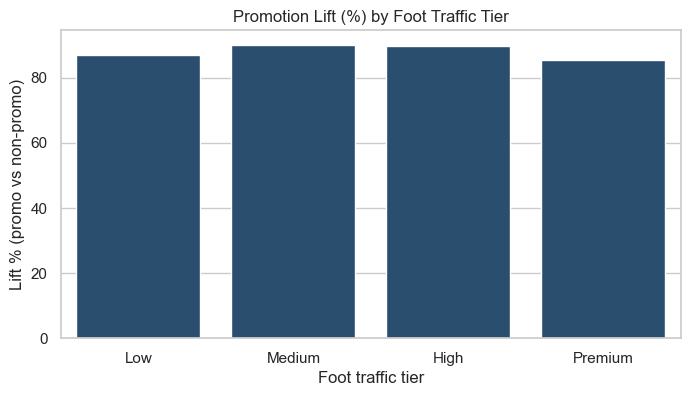

In [68]:
plt.figure(figsize=(8,4))
sns.barplot(data=tier_promo.reset_index(), x="foot_traffic_tier", y="lift_pct", color="#1F4E79",
            order=["Low","Medium","High","Premium"])
plt.title("Promotion Lift (%) by Foot Traffic Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Lift % (promo vs non-promo)")
plt.show()

double unit sales across all store tiers (85–90% lift) > Promotion  affects boost in demand
Absolute lift is larger in higher-traffic stores because baseline demand is higher

In [69]:
sales.groupby(["store_id","sku_id","sale_date"]).size().describe()

count    25969106.0
mean            1.0
std             0.0
min             1.0
25%             1.0
50%             1.0
75%             1.0
max             1.0
dtype: float64

###  all tiers respond similarly (~85–90% lift)
### Premium has highest absolute lift +13.4 units coz base demand is higher 

### Stockout timeline & seasonality, stock per month


In [70]:
stock["month"] = stock["stockout_date"].dt.to_period("M").dt.to_timestamp()

monthly_stockouts = stock.groupby("month").agg(
    events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

monthly_stockouts.head()

,events,lost_revenue,lost_units
month,,,
2024-01-01,7596,22603575.76,949259
2024-02-01,10030,14314470.41,584516
2024-03-01,11721,15011622.43,599188
2024-04-01,11254,15339478.03,606672
2024-05-01,12729,17550277.56,700192


events: count of stockout events starting in that month (based on stockout_date)
lost_revenue: total lost revenue for those events
lost_units: total lost units


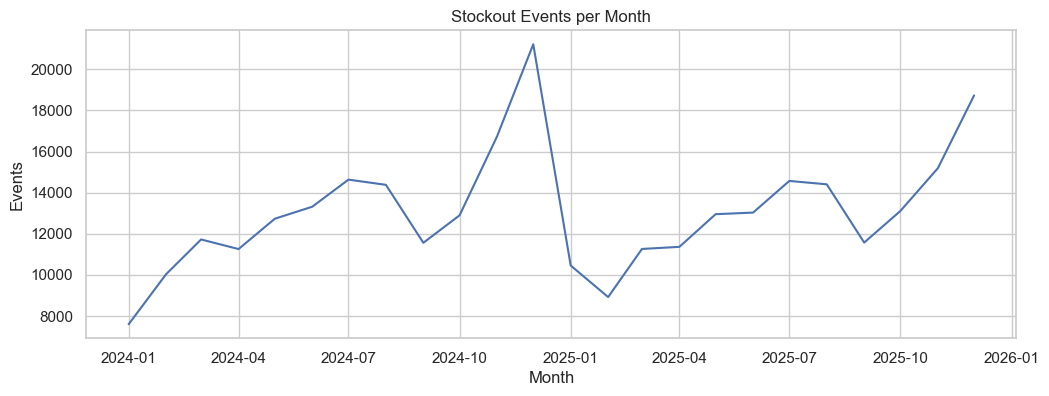

In [71]:
plt.figure(figsize=(12,4))
sns.lineplot(data=monthly_stockouts.reset_index(), x="month", y="events")
plt.title("Stockout Events per Month")
plt.xlabel("Month")
plt.ylabel("Events")
plt.show()

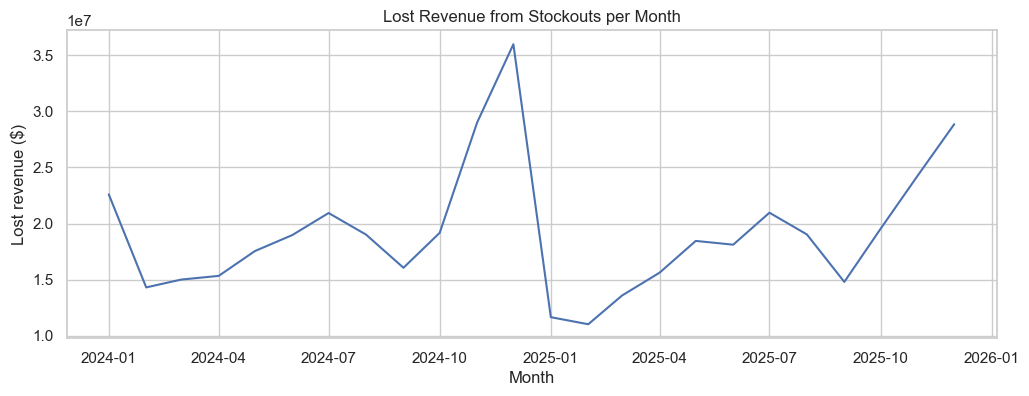

In [72]:
plt.figure(figsize=(12,4))
sns.lineplot(data=monthly_stockouts.reset_index(), x="month", y="lost_revenue")
plt.title("Lost Revenue from Stockouts per Month")
plt.xlabel("Month")
plt.ylabel("Lost revenue ($)")
plt.show()

### Forecast quality EDA ( actual daily demand at store× sku ×date ) 


In [73]:
actual = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)["units_sold"]
         .sum()
         .rename(columns={"sale_date":"date", "units_sold":"actual_units"})
)

fc = fcst.rename(columns={"forecast_date":"date", "forecast_units":"forecast_units"})

fa = actual.merge(fc, on=["store_id","sku_id","date"], how="inner")
fa["error"] = fa["actual_units"] - fa["forecast_units"]
fa["abs_error"] = fa["error"].abs()
fa["ape"] = (fa["abs_error"] / fa["actual_units"].replace(0, np.nan)) * 100

fa.head()

,store_id,sku_id,date,actual_units,forecast_id,forecast_units,forecast_method,created_at,lower_bound_90,upper_bound_90,error,abs_error,ape
0,S0001,P00055,2024-01-31,15,FC0000028685,23.43,MovingAvg7,2024-01-30,21.15,25.71,-8.43,8.43,56.200000
1,S0001,P00055,2024-01-31,15,FC0000028686,24.93,MovingAvg30,2024-01-30,21.12,28.74,-9.93,9.93,66.200000
2,S0001,P00055,2024-01-31,15,FC0000028687,30.00,SeasonalNaive,2024-01-30,24.63,35.37,-15.00,15.00,100.000000
3,S0001,P00055,2024-01-31,15,FC0000028688,21.78,ExponentialSmoothing,2024-01-30,17.57,25.99,-6.78,6.78,45.200000
4,S0001,P00055,2024-02-07,18,FC0000028689,21.43,MovingAvg7,2024-02-06,16.91,25.95,-3.43,3.43,19.055556


actual_units: true sales from sales table (aggregated)
forecast_units: forecast value from demand_forecasts
forecast_method: which baseline method produced it
lower/upper_bound_90: forecast uncertainty interval (90%)
error = actual − forecast (here negative value forecast was too high)
abs_error = |error|
ape = abs_error / actual_units * 100 (percentage error)
here for store id forecast is off by 56% for that day+sku+store

### Best forecaste method


In [74]:
method_mape = fa.groupby("forecast_method")["ape"].mean().sort_values()
method_mape

forecast_method
MovingAvg30             45.978113
ExponentialSmoothing    47.043037
MovingAvg7              48.679656
SeasonalNaive           56.818325
Name: ape, dtype: float64

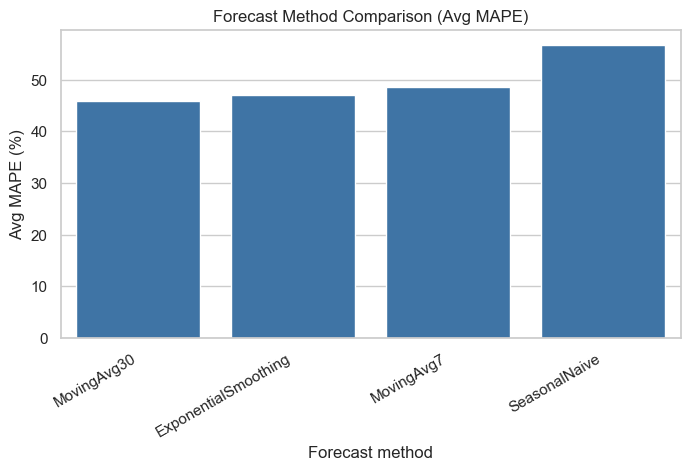

In [75]:
plt.figure(figsize=(8,4))
sns.barplot(x=method_mape.index, y=method_mape.values, color="#2E75B6")
plt.title("Forecast Method Comparison (Avg MAPE)")
plt.xlabel("Forecast method")
plt.ylabel("Avg MAPE (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

### interval coverage in in_90_interval%

In [76]:
fa["in_90_interval"] = (fa["actual_units"] >= fa["lower_bound_90"]) & (fa["actual_units"] <= fa["upper_bound_90"])

coverage = fa.groupby("forecast_method")["in_90_interval"].mean().sort_values(ascending=False) * 100
coverage

forecast_method
MovingAvg30             32.701051
ExponentialSmoothing    32.395201
MovingAvg7              32.082876
SeasonalNaive           25.412343
Name: in_90_interval, dtype: float64

### 90% prediction interval = the true actual demand fall between lower and upper bound 90% of the time 
### in_90_interval = True if lower_bound_90 ≤ actual_units ≤ upper_bound_90
### interval coverage % = average of in_90_interval 
### Only ~25–33% of actual demand falls inside the supposed 90% interval, so intervals are too narrow or not well-calibrated and we need to improving forecasting model or improving uncertainty estimation

###  Replenishment behavior EDA :  Lead time distribution

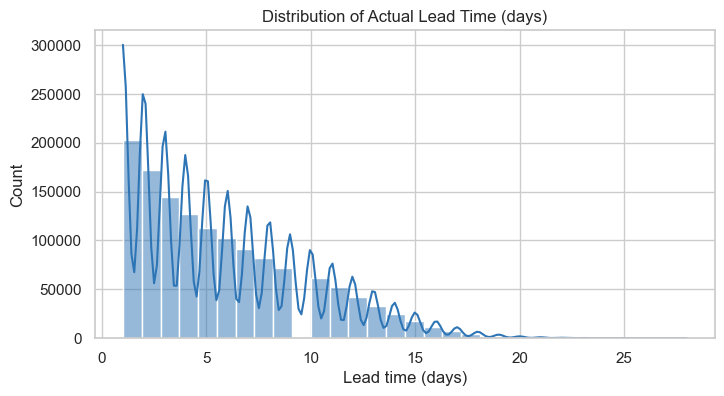

count    1.366761e+06
mean     5.741815e+00
std      4.089814e+00
min      1.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      8.000000e+00
max      2.800000e+01
Name: lead_time_actual, dtype: float64

In [77]:
plt.figure(figsize=(8,4))
sns.histplot(repl["lead_time_actual"], bins=30, kde=True, color="#2E75B6")
plt.title("Distribution of Actual Lead Time (days)")
plt.xlabel("Lead time (days)")
plt.ylabel("Count")
plt.show()

repl["lead_time_actual"].describe()

## fill rate + link to supplier reliability
### fill_rate = units_received / units_ordered (how many we got and how many we ordered)



### Do stockout happen before receive_date

In [78]:
repl2 = (
    repl.merge(products[["sku_id","supplier_id"]], on="sku_id", how="left")
        .merge(suppliers[["supplier_id","reliability_score"]], on="supplier_id", how="left")
)

repl2["fill_rate"] = repl2["units_received"] / repl2["units_ordered"].replace(0, np.nan)
repl2.head()

,replenishment_id,store_id,sku_id,replenishment_date,trigger_type,units_ordered,units_received,order_date,receive_date,lead_time_actual,replenishment_cost,associate_id,supplier_id,reliability_score,fill_rate
0,REP-S0001-P01049-0001,S0001,P01049,2024-01-02,Reorder Point,436,390,2024-01-01,2024-01-02,1,5327.40,EMP02056,SUP009,0.766,0.894495
1,REP-S0001-P01049-0002,S0001,P01049,2024-01-19,Reorder Point,436,379,2024-01-18,2024-01-19,1,5177.14,EMP02867,SUP009,0.766,0.869266
2,REP-S0001-P01049-0003,S0001,P01049,2024-02-05,Reorder Point,436,411,2024-02-04,2024-02-05,1,5614.26,EMP03836,SUP009,0.766,0.942661
3,REP-S0001-P01049-0004,S0001,P01049,2024-02-25,Reorder Point,436,413,2024-02-24,2024-02-25,1,5641.58,EMP02913,SUP009,0.766,0.947248
4,REP-S0001-P01049-0005,S0001,P01049,2024-03-14,Reorder Point,436,398,2024-03-13,2024-03-14,1,5436.68,EMP02809,SUP009,0.766,0.912844


replenishment_id: unique restock event id
store_id, sku_id: what store and product it’s for
replenishment_date: when restocking happened (operational date)
trigger_type: why the order was triggered (mostly Reorder Point in your dataset)
units_ordered: requested quantity
units_received: delivered quantity (can be lower)
order_date: when purchase order was placed
receive_date: when goods arrived
lead_time_actual: receive_date - order_date in days
replenishment_cost: cost of order
associate_id: staff who executed it
supplier_id: supplier of that sku (joined from products → supplier_id)
reliability_score: supplier’s reliability (joined from suppliers table)
fill_rate = units_received / units_ordered
for sku id s0001,  390/436 = 0.894 = supplier delivered ~89% of what was ordered


In [79]:
# Next delivery after stockout (receive_date on/after stockout_date)

repl_key = repl2[["store_id","sku_id","receive_date","order_date"]].dropna().copy()
so = stock[["store_id","sku_id","stockout_date","stockout_id"]].dropna().copy()

#  datetime 
repl_key["receive_date"] = pd.to_datetime(repl_key["receive_date"])
so["stockout_date"] = pd.to_datetime(so["stockout_date"])

# Sort by time first, then keys for merge_asof
repl_key = repl_key.sort_values(["receive_date", "store_id", "sku_id"]).reset_index(drop=True)
so = so.sort_values(["stockout_date", "store_id", "sku_id"]).reset_index(drop=True)

merged = pd.merge_asof(
    so,
    repl_key,
    by=["store_id", "sku_id"],
    left_on="stockout_date",
    right_on="receive_date",
    direction="forward",
    allow_exact_matches=True
)

merged["days_until_next_delivery"] = (merged["receive_date"] - merged["stockout_date"]).dt.days
merged["days_until_next_delivery"].describe()

count    310397.000000
mean          6.281704
std           6.629117
min           0.000000
25%           2.000000
50%           4.000000
75%           8.000000
max          79.000000
Name: days_until_next_delivery, dtype: float64

### Inventory = stockout linkage, latest inventory snapshot before each stockout

In [80]:
inv_key = inv[["store_id","sku_id","snapshot_date","days_of_supply","units_on_hand","units_in_backroom"]].dropna().copy()
so = stock[["store_id","sku_id","stockout_date","stockout_id","estimated_lost_revenue"]].dropna().copy()

# Force datetime 
inv_key["snapshot_date"] = pd.to_datetime(inv_key["snapshot_date"])
so["stockout_date"] = pd.to_datetime(so["stockout_date"])

#  Sort by time first (global), then keys (required by merge_asof)
inv_key = inv_key.sort_values(["snapshot_date","store_id","sku_id"]).reset_index(drop=True)
so = so.sort_values(["stockout_date","store_id","sku_id"]).reset_index(drop=True)

#  merge_asof: last snapshot on/before stockout_date for same store+sku
so_inv = pd.merge_asof(
    so,
    inv_key,
    by=["store_id","sku_id"],
    left_on="stockout_date",
    right_on="snapshot_date",
    direction="backward",
    allow_exact_matches=True
)

so_inv["days_from_snapshot_to_stockout"] = (so_inv["stockout_date"] - so_inv["snapshot_date"]).dt.days
so_inv.head()

,store_id,sku_id,stockout_date,stockout_id,estimated_lost_revenue,snapshot_date,days_of_supply,units_on_hand,units_in_backroom,days_from_snapshot_to_stockout
0,S0367,P00496,2024-01-06,SO-S0367-P00496-0001,878.60,2024-01-01,9.99,79,0,5
1,S0023,P00496,2024-01-07,SO-S0023-P00496-0001,2723.66,2024-01-01,11.24,266,0,6
2,S0098,P00496,2024-01-07,SO-S0098-P00496-0001,4964.09,2024-01-01,11.01,248,0,6
3,S0177,P00496,2024-01-07,SO-S0177-P00496-0001,834.67,2024-01-01,11.16,146,0,6
4,S0217,P00496,2024-01-07,SO-S0217-P00496-0001,1801.13,2024-01-01,11.24,188,0,6


store_id / sku_id: which store and product
stockout_date: day the item first hit zero on shelf (start of stockout)
snapshot_date: the most recent inventory snapshot on/before the stockout_date (used direction="backward)
days_of_supply (at snapshot): estimated days remaining as of that snapshot
units_on_hand / units_in_backroom (at snapshot): physical counts at snapshot
days_from_snapshot_to_stockout: stockout_date - snapshot_date (how old the snapshot is)
The system checked the stock would last 10 days, but it ran out on 6th jan only 5 days later = estimate was off as it was from past sales recent demand

This demand can suddenly rise and inventory snapshot_date is few days old not fresh



### stockouts happen more when days_of_supply is low

In [81]:
bins = [-np.inf, 1, 2, 3, 5, 7, np.inf]
labels = ["<=1", "1-2", "2-3", "3-5", "5-7", "7+"]

so_inv["dos_bin"] = pd.cut(so_inv["days_of_supply"], bins=bins, labels=labels)

dos_summary = so_inv.groupby("dos_bin").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
    median_lost_revenue=("estimated_lost_revenue","median"),
).sort_index()

dos_summary

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/284085029.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dos_summary = so_inv.groupby("dos_bin").agg(


,stockout_events,avg_lost_revenue,median_lost_revenue
dos_bin,,,
<=1,152030,1466.586832,359.100
1-2,51105,1522.391003,636.400
2-3,35470,1541.654866,718.750
3-5,44764,1412.162122,722.245
5-7,22131,1310.230400,607.680
7+,8099,1518.019421,562.100


###  stockouts happen when days_of_supply(dos_bin) ≤ 1 and wit higher days of suppy reasons are snapshots are old (5–6 days earlier) and are estimated using recent demand spike, shrinkage 

### median lost revenue is much smaller than average lost revenue for <=1 meaidan is $359 and mean is $1466 that means stockout items are costly, focus on items costs as well 





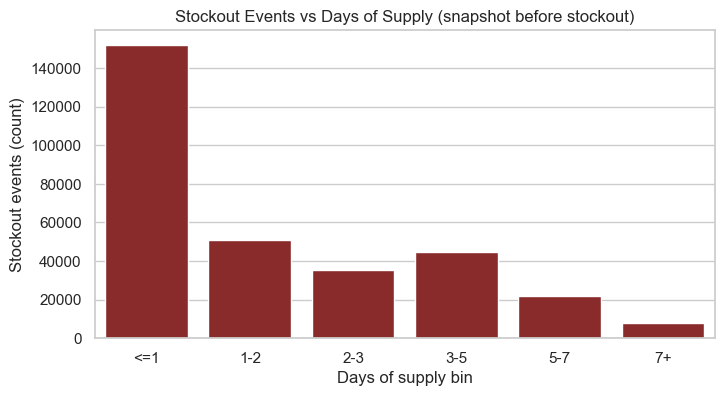

In [82]:
plt.figure(figsize=(8,4))
sns.barplot(data=dos_summary.reset_index(), x="dos_bin", y="stockout_events", color="#991B1B")
plt.title("Stockout Events vs Days of Supply (snapshot before stockout)")
plt.xlabel("Days of supply bin")
plt.ylabel("Stockout events (count)")
plt.show()

In [83]:
so_inv["units_total"] = so_inv["units_on_hand"] + so_inv["units_in_backroom"]
so_inv["units_total"].describe()

count    313599.000000
mean         57.342775
std          70.724802
min           0.000000
25%          10.000000
50%          35.000000
75%          79.000000
max         724.000000
Name: units_total, dtype: float64

### units_total = units_on_hand + units_in_backroom (from the snapshot before the stockout)

count = 313,599  snapshot match all stockouts
mean = 57.34, std = 70.72 > large spread (some items have very high stock)
min = 0 == there are stockouts where snapshot already showed 0 total units 
25% = 10 == 25% of stockouts had ≤10 total units at the snapshot
50% (median) = 35 ==  stockout had 35 units total at the snapshot
75% = 79 == 75% of stockouts had ≥79 units total at snapshot
max = 724 → very large inventory for some store+sku at snapshot

### stockouts even happening when units_total is big coz snapshot are old, demand for sku is high 

In [84]:
so_inv["units_total"] = so_inv["units_on_hand"] + so_inv["units_in_backroom"]

bins = [-1, 0, 5, 10, 20, 50, 100, 10**9]
labels = ["0", "1-5", "6-10", "11-20", "21-50", "51-100", "100+"]

so_inv["units_total_bin"] = pd.cut(so_inv["units_total"], bins=bins, labels=labels)

so_inv.groupby("units_total_bin").agg(
    stockout_events=("stockout_id","count"),
    avg_dos=("days_of_supply","mean"),
    median_dos=("days_of_supply","median"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/957664784.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  so_inv.groupby("units_total_bin").agg(


,units_total_bin,stockout_events,avg_dos,median_dos,avg_lost_revenue
0,0,45396,0.000000,0.00,1172.207920
1,1-5,17330,0.535758,0.33,1032.019804
2,6-10,17647,1.207140,0.86,1014.929885
3,11-20,33752,1.721460,1.34,1138.485646
4,21-50,76547,2.484331,2.10,1326.240793
5,51-100,67462,2.740637,2.44,1743.150058
6,100+,55465,2.095072,0.75,2044.594384


### units_total_bin: number of total units at snapshot (on-hand + backroom)
stockout_events: number of stockout events whose latest snapshot fell into that bin
avg_dos / median_dos: average/median days_of_supply for those stockouts
avg_lost_revenue: average lost revenue per stockout in that bin

### even for 100+ units the stockout is constant as the demand is huge, for avg_lost_revenue also include the high-demand items keep a lot of stock so the loss is big 

In [85]:
tmp = so_inv.copy()
tmp["units_total"] = tmp["units_on_hand"] + tmp["units_in_backroom"]

tmp[["days_of_supply","units_total","estimated_lost_revenue"]].corr(numeric_only=True)

,days_of_supply,units_total,estimated_lost_revenue
days_of_supply,1.000000,0.112566,-0.005746
units_total,0.112566,1.000000,0.050825
estimated_lost_revenue,-0.005746,0.050825,1.000000


### units_total and DoS are only weakly related 
### lost revenue is not linearly explained by DoS or units_total 

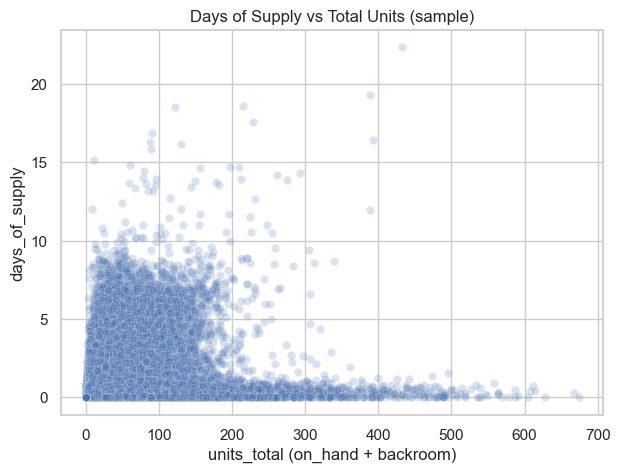

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(data=tmp.sample(20000, random_state=42), x="units_total", y="days_of_supply", alpha=0.2)
plt.title("Days of Supply vs Total Units (sample)")
plt.xlabel("units_total (on_hand + backroom)")
plt.ylabel("days_of_supply")
plt.show()

### DoS ≈ 0–1 shows range of total units even > 400 to 500 , some sku have very high demand even large stocks total leads to small days of supply 

### shelf capacity per store+sku from layout 

In [87]:
cap = (
    layout.groupby(["store_id","assigned_sku_id"])["capacity_units"]
          .sum()
          .reset_index()
          .rename(columns={"assigned_sku_id":"sku_id", "capacity_units":"capacity_units_total"})
)

# attach capacity to stockouts
so_cap = stock[["store_id","sku_id","stockout_id","estimated_lost_revenue"]].merge(
    cap, on=["store_id","sku_id"], how="left"
)

so_cap["capacity_units_total"].describe()

count    153631.000000
mean         37.797756
std          23.007232
min           6.000000
25%          21.000000
50%          35.000000
75%          47.000000
max         186.000000
Name: capacity_units_total, dtype: float64

### Most store+sku shelf capacities are around 20–50 units but some products might have capacity of 186 

### Compare stockouts by capacity bins


In [88]:
so_cap["cap_bin"] = pd.qcut(so_cap["capacity_units_total"], q=5, duplicates="drop")

cap_summary = so_cap.groupby("cap_bin").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
)

cap_summary

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1642675036.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cap_summary = so_cap.groupby("cap_bin").agg(


,stockout_events,avg_lost_revenue
cap_bin,,
"(5.999, 18.0]",32240,1511.115953
"(18.0, 29.0]",29989,1407.276228
"(29.0, 39.0]",30181,1519.334398
"(39.0, 53.0]",30716,1447.245790
"(53.0, 186.0]",30505,1428.527339


### capacity bin: range of shelf/storage size grouped into categories

### stockout_events: number of times items went out of stock in that bin

### avg_lost_revenue: average money lost due to stockouts in that bin

### Even if capacity increases, stockouts are not reducing, higher demand products gets big shelfs or restocking or promotion

### aim for stockouts per day, stockout per sales valume 


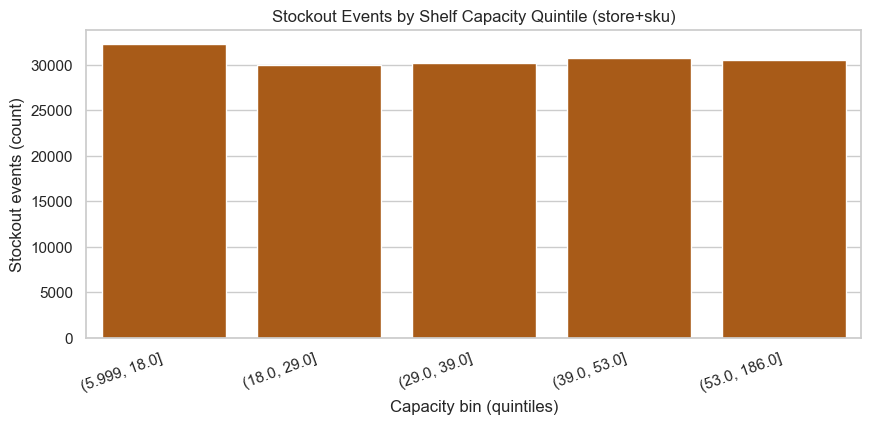

In [89]:
plt.figure(figsize=(10,4))
sns.barplot(data=cap_summary.reset_index(), x="cap_bin", y="stockout_events", color="#C05A00")
plt.title("Stockout Events by Shelf Capacity Quintile (store+sku)")
plt.xlabel("Capacity bin (quintiles)")
plt.ylabel("Stockout events (count)")
plt.xticks(rotation=20, ha="right")
plt.show()

In [90]:
so_inv["days_from_snapshot_to_stockout"].describe(), so_inv["days_from_snapshot_to_stockout"].value_counts().head(10)

(count    313599.000000
 mean          3.260986
 std           1.954417
 min           0.000000
 25%           2.000000
 50%           3.000000
 75%           5.000000
 max           6.000000
 Name: days_from_snapshot_to_stockout, dtype: float64,
 days_from_snapshot_to_stockout
 5    60026
 4    48974
 6    46443
 1    42919
 3    41169
 2    40766
 0    33302
 Name: count, dtype: int64)

### days_from_snapshot_to_stockout: number of days between last inventory check and when stock ran out

### count (frequency): how many times stockouts happened after that many days

### The system checks inventory only once every 6–7 days (weekly) and stockout happens day after that check and on avg of 3 days stockout happends and max = 6 days

### also need to consider sales trends, demand spikes, promotions

In [91]:

def to_dt(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

sales = to_dt(sales, ["sale_date"])
inv   = to_dt(inv,   ["snapshot_date", "expiry_nearest_date"])
repl  = to_dt(repl,  ["replenishment_date", "order_date", "receive_date"])
stock = to_dt(stock, ["stockout_date", "restock_date"])
promos= to_dt(promos,["start_date", "end_date"])
fc    = to_dt(fc,    ["forecast_date", "created_at"])

In [93]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/Users/shashi/retail-ai-project/data/raw/output/csv")

files = [
    "stores.csv",
    "products.csv",
    "suppliers.csv",
    "store_layout.csv",
    "sales_transactions.csv",
    "inventory_snapshots.csv",
    "replenishment_logs.csv",
    "stockout_events.csv",
    "promotions.csv",
    "demand_forecasts.csv",
]

dfs = {f: pd.read_csv(DATA_DIR / f, low_memory=False) for f in files}

stores = dfs["stores.csv"]
products = dfs["products.csv"]
suppliers = dfs["suppliers.csv"]
store_layout = dfs["store_layout.csv"]
sales = dfs["sales_transactions.csv"]
inv = dfs["inventory_snapshots.csv"]
repl = dfs["replenishment_logs.csv"]
stock = dfs["stockout_events.csv"]
promos = dfs["promotions.csv"]
fc = dfs["demand_forecasts.csv"]

{k: v.shape for k, v in dfs.items()}

{'stores.csv': (478, 10),
 'products.csv': (1265, 15),
 'suppliers.csv': (85, 9),
 'store_layout.csv': (416999, 9),
 'sales_transactions.csv': (25969106, 9),
 'inventory_snapshots.csv': (4015200, 9),
 'replenishment_logs.csv': (1366761, 12),
 'stockout_events.csv': (313599, 9),
 'promotions.csv': (5420, 9),
 'demand_forecasts.csv': (15448960, 9)}

In [94]:
dfs = {
    "stores": stores,
    "products": products,
    "suppliers": suppliers,
    "store_layout": store_layout,
    "sales": sales,
    "inv": inv,
    "repl": repl,
    "stock": stock,
    "promos": promos,
    "fc": fc,
}

overview = []
for name, df in dfs.items():
    overview.append({
        "table": name,
        "rows": len(df),
        "cols": df.shape[1],
        "null_cells": int(df.isna().sum().sum())
    })
pd.DataFrame(overview).sort_values("rows", ascending=False)

,table,rows,cols,null_cells
4,sales,25969106,9,25424557
9,fc,15448960,9,0
5,inv,4015200,9,2451002
6,repl,1366761,12,0
3,store_layout,416999,9,0
7,stock,313599,9,2682
8,promos,5420,9,2277
1,products,1265,15,746
0,stores,478,10,0
2,suppliers,85,9,0


In [95]:
checks = {
    "stores.store_id unique?": stores["store_id"].is_unique,
    "products.sku_id unique?": products["sku_id"].is_unique,
    "suppliers.supplier_id unique?": suppliers["supplier_id"].is_unique,
    "store_layout.layout_id unique?": store_layout["layout_id"].is_unique,
    "sales.transaction_id unique?": sales["transaction_id"].is_unique if "transaction_id" in sales.columns else None,
    "inv.snapshot_id unique?": inv["snapshot_id"].is_unique if "snapshot_id" in inv.columns else None,
    "repl.replenishment_id unique?": repl["replenishment_id"].is_unique if "replenishment_id" in repl.columns else None,
    "stock.stockout_id unique?": stock["stockout_id"].is_unique if "stockout_id" in stock.columns else None,
    "promos.promotion_id unique?": promos["promotion_id"].is_unique if "promotion_id" in promos.columns else None,
    "fc.forecast_id unique?": fc["forecast_id"].is_unique if "forecast_id" in fc.columns else None,
}
checks

{'stores.store_id unique?': True,
 'products.sku_id unique?': True,
 'suppliers.supplier_id unique?': True,
 'store_layout.layout_id unique?': True,
 'sales.transaction_id unique?': True,
 'inv.snapshot_id unique?': True,
 'repl.replenishment_id unique?': True,
 'stock.stockout_id unique?': True,
 'promos.promotion_id unique?': True,
 'fc.forecast_id unique?': True}

In [96]:
dup_sales = sales.groupby(["store_id","sku_id","sale_date"]).size()
dup_sales.describe(), (dup_sales > 1).mean()

(count    25969106.0
 mean            1.0
 std             0.0
 min             1.0
 25%             1.0
 50%             1.0
 75%             1.0
 max             1.0
 dtype: float64,
 np.float64(0.0))

### inventory snapshots are one per date per store×sku (no morning/eod duplicates)

In [97]:
sales_daily = (sales
    .groupby(["store_id","sku_id","sale_date"], as_index=False)
    .agg(units_sold=("units_sold","sum"),
         revenue=("revenue","sum"),
         is_promoted=("is_promoted","max"))  # if boolean
)
sales_daily.head()

,store_id,sku_id,sale_date,units_sold,revenue,is_promoted
0,S0001,P00055,2024-01-01,31,1223.57,False
1,S0001,P00055,2024-01-02,21,828.87,False
2,S0001,P00055,2024-01-03,17,670.99,False
3,S0001,P00055,2024-01-04,25,986.75,False
4,S0001,P00055,2024-01-05,27,1065.69,False


In [98]:
inv["snapshot_time"].value_counts().head(10), inv.groupby(["store_id","sku_id","snapshot_date"]).size().describe()

(snapshot_time
 08:00:00    4015200
 Name: count, dtype: int64,
 count    4015200.0
 mean           1.0
 std            0.0
 min            1.0
 25%            1.0
 50%            1.0
 75%            1.0
 max            1.0
 dtype: float64)

In [99]:
repl["order_date"] = pd.to_datetime(repl["order_date"], errors="coerce")
repl["receive_date"] = pd.to_datetime(repl["receive_date"], errors="coerce")

repl_checks = pd.DataFrame({
    "missing_receive_date": [repl["receive_date"].isna().mean()],
    "missing_order_date": [repl["order_date"].isna().mean()],
    "lead_time_negative": [((repl["receive_date"] - repl["order_date"]).dt.days < 0).mean()],
    "units_received_gt_ordered": [(repl["units_received"] > repl["units_ordered"]).mean()],
    "units_ordered_zero": [(repl["units_ordered"] == 0).mean()],
})
repl_checks

,missing_receive_date,missing_order_date,lead_time_negative,units_received_gt_ordered,units_ordered_zero
0,0.0,0.0,0.0,0.0,0.0


In [100]:
repl2 = (
    repl.merge(products[["sku_id","supplier_id"]], on="sku_id", how="left")
        .merge(suppliers[["supplier_id","reliability_score"]], on="supplier_id", how="left")
)

repl2["fill_rate"] = repl2["units_received"] / repl2["units_ordered"].replace(0, np.nan)
repl2[["fill_rate","reliability_score"]].describe()

,fill_rate,reliability_score
count,1.366761e+06,1.366761e+06
mean,9.203795e-01,8.475542e-01
std,4.366034e-02,8.044416e-02
min,7.500000e-01,7.120000e-01
25%,8.829114e-01,7.690000e-01
50%,9.207048e-01,8.500000e-01
75%,9.583333e-01,9.250000e-01
max,9.989130e-01,9.800000e-01


### On average suppliers deliver 92% of ordered units (partial fulfillment happens often).



In [101]:
repl_key = repl2[["store_id","sku_id","receive_date","order_date"]].dropna().copy()
so = stock[["store_id","sku_id","stockout_date","stockout_id","estimated_lost_revenue"]].dropna().copy()

repl_key["receive_date"] = pd.to_datetime(repl_key["receive_date"])
so["stockout_date"] = pd.to_datetime(so["stockout_date"])

# IMPORTANT: sort by time first for merge_asof
repl_key = repl_key.sort_values(["receive_date","store_id","sku_id"]).reset_index(drop=True)
so = so.sort_values(["stockout_date","store_id","sku_id"]).reset_index(drop=True)

so_next = pd.merge_asof(
    so,
    repl_key,
    by=["store_id","sku_id"],
    left_on="stockout_date",
    right_on="receive_date",
    direction="forward",
    allow_exact_matches=True
)

so_next["days_until_next_delivery"] = (so_next["receive_date"] - so_next["stockout_date"]).dt.days
so_next["days_until_next_delivery"].describe(), so_next["receive_date"].isna().mean()

(count    310397.000000
 mean          6.281704
 std           6.629117
 min           0.000000
 25%           2.000000
 50%           4.000000
 75%           8.000000
 max          79.000000
 Name: days_until_next_delivery, dtype: float64,
 np.float64(0.010210491742639485))

### 1.02% stockouts have no “next delivery” found (missing match)


In [102]:
bins = [-1,0,1,2,3,5,7,14,999]
labels = ["0","1","2","3","4-5","6-7","8-14","15+"]

so_next["next_delivery_bin"] = pd.cut(so_next["days_until_next_delivery"], bins=bins, labels=labels)

so_next.groupby("next_delivery_bin").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
    median_lost_revenue=("estimated_lost_revenue","median"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1630200158.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  so_next.groupby("next_delivery_bin").agg(


,next_delivery_bin,stockout_events,avg_lost_revenue,median_lost_revenue
0,0,2952,549.222039,74.00
1,1,55938,256.343704,114.82
2,2,43844,666.628030,436.86
3,3,35512,1051.857826,720.39
4,4-5,53025,1588.793828,1110.10
5,6-7,35264,2311.799737,1592.53
6,8-14,53191,3029.123216,1623.05
7,15+,30671,1523.314962,119.31


### When next delivery is 1 day, average lost revenue is low ($256)
###  When next delivery is 8–14 days, avg lost revenue is much higher ($3029)


In [103]:
# Bucket reliability
repl2["reliability_bin"] = pd.cut(
    repl2["reliability_score"],
    bins=[0, 0.6, 0.8, 1.0],
    labels=["0-0.6","0.6-0.8","0.8-1.0"],
    include_lowest=True
)

repl2.groupby("reliability_bin").agg(
    orders=("replenishment_id","count"),
    avg_fill_rate=("fill_rate","mean"),
    median_fill_rate=("fill_rate","median"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/702885108.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  repl2.groupby("reliability_bin").agg(


,reliability_bin,orders,avg_fill_rate,median_fill_rate
0,0-0.6,0,NaN,NaN
1,0.6-0.8,451159,0.920518,0.920844
2,0.8-1.0,915602,0.920311,0.920635


In [105]:
repl2[["reliability_score","fill_rate"]].corr(numeric_only=True)

,reliability_score,fill_rate
reliability_score,1.000000,-0.000549
fill_rate,-0.000549,1.000000


In [104]:
# Ensure correct dtypes first
sales_base = sales  # sales_transactions.csv already daily totals in your data

sales_base["sale_date"] = pd.to_datetime(sales_base["sale_date"], errors="coerce")
promos["start_date"] = pd.to_datetime(promos["start_date"], errors="coerce")
promos["end_date"] = pd.to_datetime(promos["end_date"], errors="coerce")

promo_expanded = promos.copy()
promo_expanded["store_id"] = promo_expanded["store_id"].fillna("ALL")

def promo_flag_for_sales(sales_df, promos_df):
    out = sales_df[["store_id","sku_id","sale_date"]].drop_duplicates().copy()

    tmp = out.merge(
        promos_df[["sku_id","store_id","start_date","end_date"]],
        on="sku_id",
        how="left",
        suffixes=("","_p")
    )

    mask_store = (tmp["store_id_p"].isna()) | (tmp["store_id_p"]=="ALL") | (tmp["store_id_p"]==tmp["store_id"])
    mask_date = (tmp["sale_date"] >= tmp["start_date"]) & (tmp["sale_date"] <= tmp["end_date"])
    tmp["hit"] = mask_store & mask_date

    flag = tmp.groupby(["store_id","sku_id","sale_date"])["hit"].any().reset_index()
    flag = flag.rename(columns={"hit":"is_promo_calendar"})

    out = out.merge(flag, on=["store_id","sku_id","sale_date"], how="left")
    out["is_promo_calendar"] = out["is_promo_calendar"].fillna(False)
    return out

promo_flag = promo_flag_for_sales(sales_base, promo_expanded)

promo_flag.columns, promo_flag["is_promo_calendar"].value_counts(normalize=True)

(Index(['store_id', 'sku_id', 'sale_date', 'is_promo_calendar'], dtype='object'),
 is_promo_calendar
 False    0.979031
 True     0.020969
 Name: proportion, dtype: float64)

In [105]:
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")

stock_promo = stock.merge(
    promo_flag,
    left_on=["store_id","sku_id","stockout_date"],
    right_on=["store_id","sku_id","sale_date"],
    how="left"
)

stock_promo["is_promo_calendar"] = stock_promo["is_promo_calendar"].fillna(False)

stock_promo.groupby("is_promo_calendar").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
    total_lost_revenue=("estimated_lost_revenue","sum"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3049769380.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stock_promo["is_promo_calendar"] = stock_promo["is_promo_calendar"].fillna(False)


,is_promo_calendar,stockout_events,avg_lost_revenue,total_lost_revenue
0,False,297376,1416.597683,4.212622e+08
1,True,16223,2385.040211,3.869251e+07


In [106]:
# Prepare actual daily demand
sales_base = sales_daily if "sales_daily" in globals() else sales
actual = sales_base.rename(columns={"sale_date":"date"}).copy()

# Forecasts
fc2 = fc.rename(columns={"forecast_date":"date"}).copy()

# Join actual to forecast (store+sku+date)
fa = actual.merge(fc2, on=["store_id","sku_id","date"], how="inner")

fa["error"] = fa["units_sold"] - fa["forecast_units"]
fa["abs_error"] = fa["error"].abs()
fa["ape"] = np.where(fa["units_sold"]==0, np.nan, fa["abs_error"] / fa["units_sold"] * 100)

# Interval coverage
fa["in_90_interval"] = (fa["units_sold"] >= fa["lower_bound_90"]) & (fa["units_sold"] <= fa["upper_bound_90"])

fa.groupby("forecast_method").agg(
    avg_mape=("ape","mean"),
    interval_coverage=("in_90_interval","mean")
).sort_values("avg_mape")

,avg_mape,interval_coverage
forecast_method,,
MovingAvg30,45.978113,0.327011
ExponentialSmoothing,47.043037,0.323952
MovingAvg7,48.679656,0.320829
SeasonalNaive,56.818325,0.254123


In [107]:
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")

In [108]:
# Force datetime for every table we use in joins/calcs
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")

inv["snapshot_date"] = pd.to_datetime(inv["snapshot_date"], errors="coerce")

repl["order_date"] = pd.to_datetime(repl["order_date"], errors="coerce")
repl["receive_date"] = pd.to_datetime(repl["receive_date"], errors="coerce")
repl["replenishment_date"] = pd.to_datetime(repl["replenishment_date"], errors="coerce")

stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")
stock["restock_date"] = pd.to_datetime(stock["restock_date"], errors="coerce")

promos["start_date"] = pd.to_datetime(promos["start_date"], errors="coerce")
promos["end_date"] = pd.to_datetime(promos["end_date"], errors="coerce")

fc["forecast_date"] = pd.to_datetime(fc["forecast_date"], errors="coerce")
fc["created_at"] = pd.to_datetime(fc["created_at"], errors="coerce")

# sanity: print dtypes
{
 "sales.sale_date": sales["sale_date"].dtype,
 "repl.order_date": repl["order_date"].dtype,
 "repl.receive_date": repl["receive_date"].dtype,
 "stock.stockout_date": stock["stockout_date"].dtype,
 "fc.forecast_date": fc["forecast_date"].dtype,
 "promos.start_date": promos["start_date"].dtype,
}

{'sales.sale_date': dtype('<M8[ns]'),
 'repl.order_date': dtype('<M8[ns]'),
 'repl.receive_date': dtype('<M8[ns]'),
 'stock.stockout_date': dtype('<M8[ns]'),
 'fc.forecast_date': dtype('<M8[ns]'),
 'promos.start_date': dtype('<M8[ns]')}

In [109]:
tmp = repl.dropna(subset=["order_date","receive_date"]).copy()
lead_time_days = (tmp["receive_date"] - tmp["order_date"]).dt.days

repl_checks = pd.DataFrame({
    "missing_receive_date": [repl["receive_date"].isna().mean()],
    "missing_order_date": [repl["order_date"].isna().mean()],
    "lead_time_negative": [(lead_time_days < 0).mean()],
    "units_received_gt_ordered": [(repl["units_received"] > repl["units_ordered"]).mean()],
    "units_ordered_zero": [(repl["units_ordered"] == 0).mean()],
})
repl_checks

,missing_receive_date,missing_order_date,lead_time_negative,units_received_gt_ordered,units_ordered_zero
0,0.0,0.0,0.0,0.0,0.0


In [110]:
# Build actual daily demand (sales is already daily per your duplicate check)
actual = sales[["store_id","sku_id","sale_date","units_sold"]].copy()
actual = actual.rename(columns={"sale_date":"date"})

fc2 = fc.rename(columns={"forecast_date":"date"}).copy()
fc2["date"] = pd.to_datetime(fc2["date"], errors="coerce")

fa = actual.merge(fc2, on=["store_id","sku_id","date"], how="inner")

fa["error"] = fa["units_sold"] - fa["forecast_units"]
fa["abs_error"] = fa["error"].abs()
fa["ape"] = np.where(fa["units_sold"]==0, np.nan, fa["abs_error"] / fa["units_sold"] * 100)

fa["in_90_interval"] = (fa["units_sold"] >= fa["lower_bound_90"]) & (fa["units_sold"] <= fa["upper_bound_90"])

fa[["date","units_sold","forecast_units","forecast_method","ape","in_90_interval"]].head(), fa["date"].dtype

(        date  units_sold  forecast_units       forecast_method        ape  \
 0 2024-01-31          19           24.14            MovingAvg7  27.052632   
 1 2024-01-31          19           22.13           MovingAvg30  16.473684   
 2 2024-01-31          19           24.00         SeasonalNaive  26.315789   
 3 2024-01-31          19           20.95  ExponentialSmoothing  10.263158   
 4 2024-02-07          18           21.29            MovingAvg7  18.277778   
 
    in_90_interval  
 0            True  
 1            True  
 2           False  
 3            True  
 4           False  ,
 dtype('<M8[ns]'))

In [111]:
stock_err = stock.merge(
    fa[["store_id","sku_id","date","forecast_method","ape"]],
    left_on=["store_id","sku_id","stockout_date"],
    right_on=["store_id","sku_id","date"],
    how="left"
)

stock_err.groupby("forecast_method")["ape"].mean().sort_values()

forecast_method
MovingAvg30             147.169493
SeasonalNaive           160.699493
ExponentialSmoothing    174.879821
MovingAvg7              180.628363
Name: ape, dtype: float64

In [112]:
repl2 = (
    repl.merge(products[["sku_id","supplier_id"]], on="sku_id", how="left")
        .merge(suppliers[["supplier_id","reliability_score","lead_time_days_avg","lead_time_days_std"]], on="supplier_id", how="left")
)

repl2["fill_rate"] = repl2["units_received"] / repl2["units_ordered"].replace(0, np.nan)
repl2["lead_time_calc"] = (repl2["receive_date"] - repl2["order_date"]).dt.days

repl2["lead_time_calc"].describe(), suppliers[["lead_time_days_avg","lead_time_days_std"]].describe()

(count    1.366761e+06
 mean     5.741815e+00
 std      4.089814e+00
 min      1.000000e+00
 25%      2.000000e+00
 50%      5.000000e+00
 75%      8.000000e+00
 max      2.800000e+01
 Name: lead_time_calc, dtype: float64,
        lead_time_days_avg  lead_time_days_std
 count           85.000000           85.000000
 mean            10.952941            2.318824
 std              5.610165            1.610493
 min              1.000000            0.500000
 25%              6.000000            1.000000
 50%             11.000000            1.800000
 75%             16.000000            3.000000
 max             20.000000            7.300000)

In [113]:
dim = (products[["sku_id","category","subcategory","is_perishable","supplier_id"]]
       .merge(stores[["store_id","region","store_format","foot_traffic_tier"]], how="cross"))

# The above cross join is huge -> DON'T do that.
# Instead, join dimensions only when needed:

In [114]:
sales_base = sales 

panel = sales_base[["store_id","sku_id","sale_date","units_sold","revenue","is_promoted"]].copy()
panel = panel.rename(columns={"sale_date":"date"})
panel["date"] = pd.to_datetime(panel["date"], errors="coerce")

stock_start = stock[["store_id","sku_id","stockout_date"]].copy().rename(columns={"stockout_date":"date"})
stock_start["date"] = pd.to_datetime(stock_start["date"], errors="coerce")
stock_start["is_stockout_start"] = 1

panel = (panel
    .merge(stores[["store_id","foot_traffic_tier","store_format","region"]], on="store_id", how="left")
    .merge(products[["sku_id","category","subcategory","is_perishable","supplier_id","unit_price","unit_cost","reorder_point","safety_stock"]], on="sku_id", how="left")
    .merge(suppliers[["supplier_id","reliability_score","lead_time_days_avg","lead_time_days_std"]], on="supplier_id", how="left")
)

panel = panel.merge(stock_start, on=["store_id","sku_id","date"], how="left")
panel["is_stockout_start"] = panel["is_stockout_start"].fillna(0).astype(int)

panel.head()

,store_id,sku_id,date,units_sold,revenue,is_promoted,foot_traffic_tier,store_format,region,category,...,is_perishable,supplier_id,unit_price,unit_cost,reorder_point,safety_stock,reliability_score,lead_time_days_avg,lead_time_days_std,is_stockout_start
0,S0001,P01049,2024-01-01,22,809.82,False,Premium,Convenience,Southwest,Canned & Pantry,...,False,SUP009,36.81,13.66,435,218,0.766,3,0.8,0
1,S0001,P01049,2024-01-02,10,368.10,False,Premium,Convenience,Southwest,Canned & Pantry,...,False,SUP009,36.81,13.66,435,218,0.766,3,0.8,0
2,S0001,P01049,2024-01-03,18,662.58,False,Premium,Convenience,Southwest,Canned & Pantry,...,False,SUP009,36.81,13.66,435,218,0.766,3,0.8,0
3,S0001,P01049,2024-01-04,20,736.20,False,Premium,Convenience,Southwest,Canned & Pantry,...,False,SUP009,36.81,13.66,435,218,0.766,3,0.8,0
4,S0001,P01049,2024-01-05,24,883.44,False,Premium,Convenience,Southwest,Canned & Pantry,...,False,SUP009,36.81,13.66,435,218,0.766,3,0.8,0


In [115]:
stock_dim = (stock
    .merge(stores[["store_id","foot_traffic_tier","store_format","region"]], on="store_id", how="left")
    .merge(products[["sku_id","category","subcategory","is_perishable","supplier_id"]], on="sku_id", how="left")
    .merge(suppliers[["supplier_id","reliability_score"]], on="supplier_id", how="left")
)

stock_dim.head()

,stockout_id,store_id,sku_id,stockout_date,restock_date,duration_days,estimated_lost_units,estimated_lost_revenue,root_cause,foot_traffic_tier,store_format,region,category,subcategory,is_perishable,supplier_id,reliability_score
0,SO-S0001-P01023-0001,S0001,P01023,2024-01-15,2024-01-17,2,11,254.21,Demand spike,Premium,Convenience,Southwest,Canned & Pantry,Pasta,False,SUP032,0.972
1,SO-S0001-P01023-0002,S0001,P01023,2024-03-10,2024-03-17,7,51,1178.61,Manual error,Premium,Convenience,Southwest,Canned & Pantry,Pasta,False,SUP032,0.972
2,SO-S0001-P01023-0003,S0001,P01023,2024-04-12,2024-04-15,3,28,647.08,Shrinkage,Premium,Convenience,Southwest,Canned & Pantry,Pasta,False,SUP032,0.972
3,SO-S0001-P01023-0004,S0001,P01023,2024-05-12,2024-05-17,5,42,970.62,Supplier delay,Premium,Convenience,Southwest,Canned & Pantry,Pasta,False,SUP032,0.972
4,SO-S0001-P01023-0005,S0001,P01023,2024-06-08,2024-06-18,10,85,1964.35,Manual error,Premium,Convenience,Southwest,Canned & Pantry,Pasta,False,SUP032,0.972


In [116]:
stock_dim.groupby("foot_traffic_tier").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
    total_lost_revenue=("estimated_lost_revenue","sum"),
).sort_values("total_lost_revenue", ascending=False)

,stockout_events,avg_lost_revenue,total_lost_revenue
foot_traffic_tier,,,
Premium,130251,1964.125827,2.558294e+08
High,78327,1514.350367,1.186145e+08
Medium,63027,982.783313,6.194188e+07
Low,41994,561.244503,2.356890e+07


In [117]:
stock_dim.groupby("category").agg(
    stockout_events=("stockout_id","count"),
    total_lost_revenue=("estimated_lost_revenue","sum"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
).sort_values("total_lost_revenue", ascending=False).head(15)

,stockout_events,total_lost_revenue,avg_lost_revenue
category,,,
Beverages,37026,54146182.92,1462.382729
Bakery,30964,48068589.28,1552.402444
Dairy & Eggs,29013,46883896.41,1615.961686
Snacks,29947,43755161.85,1461.086648
Frozen Foods,31583,39629417.26,1254.770518
Meat & Seafood,21889,38548089.61,1761.071297
Household,24594,36232906.94,1473.241723
Personal Care,22272,34044403.48,1528.574151
Canned & Pantry,21753,32793342.10,1507.531931


In [118]:
stock_dim.groupby("is_perishable").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
    total_lost_revenue=("estimated_lost_revenue","sum"),
)

,stockout_events,avg_lost_revenue,total_lost_revenue
is_perishable,,,
False,183632,1437.748062,2.640166e+08
True,129967,1507.598911,1.959381e+08


In [119]:
sales_base = sales_daily if "sales_daily" in globals() else sales

sku_rev = (sales_base.groupby("sku_id", as_index=False)["revenue"].sum()
           .sort_values("revenue", ascending=False))
sku_rev["cum_share"] = sku_rev["revenue"].cumsum() / sku_rev["revenue"].sum()
sku_rev.head(10), (sku_rev["cum_share"] <= 0.8).mean()

(      sku_id      revenue  cum_share
 1099  P01100  16561339.08   0.002475
 1251  P01252  16143019.74   0.004887
 711   P00712  16057978.63   0.007286
 697   P00698  15805190.94   0.009648
 1113  P01114  15572452.44   0.011975
 699   P00700  15380835.49   0.014273
 727   P00728  15294136.41   0.016559
 235   P00236  15246795.34   0.018837
 94    P00095  14966655.95   0.021073
 97    P00098  14790193.54   0.023283,
 np.float64(0.541501976284585))

In [120]:
sales_base = sales_daily if "sales_daily" in globals() else sales

sku_daily = sales_base.groupby("sku_id")["units_sold"].mean().rename("avg_units_per_day")
prod_pol = products[["sku_id","reorder_point","safety_stock"]].merge(sku_daily, on="sku_id", how="left")

prod_pol["rp_days_cover"] = prod_pol["reorder_point"] / prod_pol["avg_units_per_day"].replace(0, np.nan)
prod_pol["ss_days_cover"] = prod_pol["safety_stock"] / prod_pol["avg_units_per_day"].replace(0, np.nan)

prod_pol[["rp_days_cover","ss_days_cover"]].describe()

,rp_days_cover,ss_days_cover
count,1265.000000,1265.000000
mean,24.818881,12.434438
std,19.582801,9.790487
min,1.007104,0.608750
25%,8.856178,4.443994
50%,20.038100,10.039723
75%,36.399085,18.199542
max,112.850168,56.425084


In [121]:
# Supplier lead time stats vs actual lead time
repl2["lead_time_calc"] = (repl2["receive_date"] - repl2["order_date"]).dt.days
repl2["lead_time_calc"].describe(), suppliers[["lead_time_days_avg","lead_time_days_std"]].describe()

(count    1.366761e+06
 mean     5.741815e+00
 std      4.089814e+00
 min      1.000000e+00
 25%      2.000000e+00
 50%      5.000000e+00
 75%      8.000000e+00
 max      2.800000e+01
 Name: lead_time_calc, dtype: float64,
        lead_time_days_avg  lead_time_days_std
 count           85.000000           85.000000
 mean            10.952941            2.318824
 std              5.610165            1.610493
 min              1.000000            0.500000
 25%              6.000000            1.000000
 50%             11.000000            1.800000
 75%             16.000000            3.000000
 max             20.000000            7.300000)

In [122]:
stock_sup = (stock
    .merge(products[["sku_id","supplier_id"]], on="sku_id", how="left")
    .merge(suppliers[["supplier_id","reliability_score"]], on="supplier_id", how="left")
)

stock_sup["reliability_bin"] = pd.cut(
    stock_sup["reliability_score"],
    bins=[0,0.6,0.8,1.0],
    labels=["0-0.6","0.6-0.8","0.8-1.0"],
    include_lowest=True
)

stock_sup.groupby("reliability_bin").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
    total_lost_revenue=("estimated_lost_revenue","sum"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3022282342.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stock_sup.groupby("reliability_bin").agg(


,reliability_bin,stockout_events,avg_lost_revenue,total_lost_revenue
0,0-0.6,0,NaN,0.000000e+00
1,0.6-0.8,100963,1449.897844,1.463860e+08
2,0.8-1.0,212636,1474.673262,3.135686e+08


In [123]:
# Promo window feature on stockouts: "was there a promo for this sku/store in last 3 days?"
# (simple EDA: match by sku_id and date range)
stock_w = stock.copy()

p = promos.copy()
p["store_id"] = p["store_id"].fillna("ALL")

# Expand window: promo effect window = start_date .. end_date+3 days
p["end_plus_3"] = p["end_date"] + pd.Timedelta(days=3)

tmp = stock_w.merge(p[["sku_id","store_id","start_date","end_plus_3"]], on="sku_id", how="left", suffixes=("","_p"))

mask_store = (tmp["store_id_p"].isna()) | (tmp["store_id_p"]=="ALL") | (tmp["store_id_p"]==tmp["store_id"])
mask_date  = (tmp["stockout_date"] >= tmp["start_date"]) & (tmp["stockout_date"] <= tmp["end_plus_3"])

tmp["in_promo_window"] = mask_store & mask_date

stock_promo_window = tmp.groupby("stockout_id")["in_promo_window"].any().reset_index()
stock_w = stock_w.merge(stock_promo_window, on="stockout_id", how="left").fillna({"in_promo_window": False})

stock_w.groupby("in_promo_window").agg(
    stockout_events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
).reset_index()

,in_promo_window,stockout_events,avg_lost_revenue
0,False,294859,1417.653005
1,True,18740,2238.362455


In [124]:
from pathlib import Path

# file sizes (confirms you are reading the big files)
files = ["sales_transactions.csv","demand_forecasts.csv","inventory_snapshots.csv","replenishment_logs.csv","stockout_events.csv"]
{f: (DATA_DIR/f).stat().st_size/1e6 for f in files}  # MB

{'sales_transactions.csv': 1990.683688,
 'demand_forecasts.csv': 1219.855962,
 'inventory_snapshots.csv': 298.278245,
 'replenishment_logs.csv': 148.983729,
 'stockout_events.csv': 25.599322}

In [125]:
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
sales["sale_date"].min(), sales["sale_date"].max(), sales["sale_date"].nunique()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'), 731)

In [126]:
# store total revenue
store_sales = sales.groupby("store_id").agg(
    total_revenue=("revenue","sum"),
    total_units=("units_sold","sum"),
    days=("sale_date","nunique"),
)

store_stock = stock.groupby("store_id").agg(
    stockout_events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

store_kpi = store_sales.join(store_stock, how="left").fillna(0)
store_kpi["lost_revenue_rate"] = store_kpi["lost_revenue"] / store_kpi["total_revenue"].replace(0, np.nan)
store_kpi["events_per_day"] = store_kpi["stockout_events"] / store_kpi["days"].replace(0, np.nan)

store_kpi = store_kpi.reset_index().merge(stores[["store_id","foot_traffic_tier","store_format","region"]], on="store_id", how="left")
store_kpi.sort_values("lost_revenue_rate", ascending=False).head(20)

,store_id,total_revenue,total_units,days,stockout_events,lost_revenue,lost_units,lost_revenue_rate,events_per_day,foot_traffic_tier,store_format,region
429,S0430,20097818.49,941407,731,1342,3251926.96,114162,0.161805,1.835841,Premium,Hypermarket,Midwest
28,S0029,20643782.47,798723,731,1152,3259250.08,112349,0.157880,1.575923,Premium,Convenience,Northeast
181,S0182,21431806.97,846090,731,1014,3120355.66,97757,0.145595,1.387141,Premium,Discount,Midwest
179,S0180,19076728.52,808269,731,1484,2767371.98,120629,0.145065,2.030096,Premium,Convenience,Northwest
79,S0080,18819710.81,806438,731,1104,2535929.82,84246,0.134749,1.510260,Premium,Convenience,Northeast
445,S0446,21199869.51,826296,731,1096,2794991.85,97140,0.131840,1.499316,Premium,Supermarket,Southeast
72,S0073,23034445.76,841983,731,1293,3001297.16,114670,0.130296,1.768810,Premium,Hypermarket,West
100,S0101,19664875.37,881332,731,1035,2504275.30,93916,0.127348,1.415869,Premium,Hypermarket,Northeast
105,S0106,14829613.91,615927,731,1257,1864511.91,64991,0.125729,1.719562,High,Convenience,Northwest
304,S0305,23092003.00,935469,731,1157,2899547.20,104213,0.125565,1.582763,Premium,Wholesale,Southwest


In [127]:
sku_stats = sales.groupby("sku_id").agg(
    avg_units=("units_sold","mean"),
    std_units=("units_sold","std"),
    p90_units=("units_sold", lambda x: np.percentile(x, 90)),
    days_sold=("sale_date","nunique"),
    total_revenue=("revenue","sum"),
).reset_index()

sku_stats["cv"] = sku_stats["std_units"] / sku_stats["avg_units"].replace(0, np.nan)  # volatility

# Bucket fast/slow movers by avg_units
sku_stats["velocity_bin"] = pd.qcut(sku_stats["avg_units"], q=5, duplicates="drop")

sku_stats.sort_values("avg_units", ascending=False).head(15), sku_stats["cv"].describe()

(      sku_id  avg_units  std_units  p90_units  days_sold  total_revenue  \
 1047  P01048  14.521709  10.319611       28.0        731    13338813.66   
 70    P00071  14.356427  10.294544       28.0        731     5468504.40   
 1048  P01049  14.026052   9.673487       28.0        731    11806242.47   
 1190  P01191  14.014972   9.900474       27.0        731    14765854.40   
 707   P00708  13.964011   8.510963       25.0        731     2560015.48   
 538   P00539  13.905241   9.897811       28.0        731     4075572.60   
 656   P00657  13.870502  11.622943       29.0        731    10131150.62   
 990   P00991  13.857539  11.652719       29.0        731     1347516.72   
 160   P00161  13.646528  10.522466       28.0        731     2635192.24   
 1137  P01138  13.595232  10.820289       28.0        731     1005326.76   
 459   P00460  13.593721   8.712203       25.0        731     1505767.29   
 777   P00778  13.586336   8.784538       25.0        731    11509764.85   
 1126  P0112

In [131]:
stockouts_raw = dfs["stock"].copy()

sku_so = (
    stockouts_raw.groupby("sku_id")
    .agg(
        stockout_events=("stockout_id", "count"),
        lost_revenue=("estimated_lost_revenue", "sum"),
        lost_units=("estimated_lost_units", "sum") if "estimated_lost_units" in stockouts_raw.columns else ("stockout_id","count"),
        avg_duration=("duration_days", "mean") if "duration_days" in stockouts_raw.columns else ("stockout_id","count"),
    )
    .reset_index()
)

sku_so.head()

,sku_id,stockout_events,lost_revenue,lost_units,avg_duration
0,P00001,243,876298.12,17764,3.662551
1,P00002,106,149386.50,6675,3.622642
2,P00003,182,565793.56,12604,3.956044
3,P00004,1,2424.78,57,1.000000
4,P00005,54,39093.45,4785,4.111111


In [132]:
sku_diag = sku_stats.merge(sku_so, on="sku_id", how="left")

sku_diag["stockout_events"] = sku_diag["stockout_events"].fillna(0)
sku_diag["lost_revenue"] = sku_diag["lost_revenue"].fillna(0)

sku_diag["lost_rev_per_event"] = sku_diag["lost_revenue"] / sku_diag["stockout_events"].replace(0, np.nan)

sku_diag.groupby("velocity_bin").agg(
    skus=("sku_id","count"),
    avg_stockout_events=("stockout_events","mean"),
    avg_lost_revenue=("lost_revenue","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1015024195.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sku_diag.groupby("velocity_bin").agg(


,velocity_bin,skus,avg_stockout_events,avg_lost_revenue
0,"(2.978, 9.144]",253,427.754941,557237.679130
1,"(9.144, 9.956]",253,265.715415,407864.777233
2,"(9.956, 10.654]",253,238.711462,332475.096126
3,"(10.654, 11.512]",253,172.671937,283917.066640
4,"(11.512, 14.522]",253,134.667984,236507.988735


In [133]:
# Using your promo_flag (sale_date-level) and stock_promo (stockout merged to promo_flag)
# Compute stockout rate per day (promo vs non-promo) by category and by tier

# Build daily panel of "did a stockout start today" for store+sku+day (only for EDA; not full modeling)
stock_start = stock[["store_id","sku_id","stockout_date"]].rename(columns={"stockout_date":"sale_date"}).copy()
stock_start["stockout_start"] = 1

daily = sales[["store_id","sku_id","sale_date","is_promoted"]].copy()
daily = daily.merge(stock_start, on=["store_id","sku_id","sale_date"], how="left")
daily["stockout_start"] = daily["stockout_start"].fillna(0).astype(int)

daily = daily.merge(products[["sku_id","category"]], on="sku_id", how="left") \
             .merge(stores[["store_id","foot_traffic_tier"]], on="store_id", how="left")

promo_rate = daily.groupby("is_promoted").agg(
    days=("sale_date","count"),
    stockout_starts=("stockout_start","sum"),
)
promo_rate["stockout_start_rate"] = promo_rate["stockout_starts"] / promo_rate["days"]
promo_rate

,days,stockout_starts,stockout_start_rate
is_promoted,,,
False,25424557,295644,0.011628
True,544549,16223,0.029792


In [134]:
tier_promo_rate = daily.groupby(["foot_traffic_tier","is_promoted"]).agg(
    days=("sale_date","count"),
    stockout_starts=("stockout_start","sum"),
).reset_index()

tier_promo_rate["rate"] = tier_promo_rate["stockout_starts"] / tier_promo_rate["days"]
tier_promo_rate.sort_values(["foot_traffic_tier","is_promoted"])

,foot_traffic_tier,is_promoted,days,stockout_starts,rate
0,High,False,5462098,74026,0.013553
1,High,True,114691,4079,0.035565
2,Low,False,7074070,38802,0.005485
3,Low,True,157486,2319,0.014725
4,Medium,False,6152961,59161,0.009615
5,Medium,True,131483,3457,0.026292
6,Premium,False,6735428,123655,0.018359
7,Premium,True,140889,6368,0.045199


In [135]:
# For each stockout, find the most recent order_date BEFORE stockout
ord_key = repl2[["store_id","sku_id","order_date","receive_date","units_ordered","units_received","fill_rate"]].dropna().copy()

ord_key = ord_key.sort_values(["order_date","store_id","sku_id"]).reset_index(drop=True)
so = stock[["store_id","sku_id","stockout_date","stockout_id","estimated_lost_revenue"]].dropna().copy()
so = so.sort_values(["stockout_date","store_id","sku_id"]).reset_index(drop=True)

so_prev_order = pd.merge_asof(
    so,
    ord_key,
    by=["store_id","sku_id"],
    left_on="stockout_date",
    right_on="order_date",
    direction="backward",
    allow_exact_matches=True
)

so_prev_order["days_since_last_order"] = (so_prev_order["stockout_date"] - so_prev_order["order_date"]).dt.days
so_prev_order["days_since_last_order"].describe(), so_prev_order["order_date"].isna().mean()

(count    313599.000000
 mean          6.646064
 std           6.708666
 min           0.000000
 25%           2.000000
 50%           5.000000
 75%           8.000000
 max          74.000000
 Name: days_since_last_order, dtype: float64,
 np.float64(0.0))

In [ ]:
#  so_inv = stockout -> last snapshot backward
so_inv = so_inv.copy()
so_inv["units_total"] = so_inv["units_on_hand"] + so_inv["units_in_backroom"]

# Phantom proxy buckets
so_inv["phantom_candidate"] = (so_inv["units_total"] > 0) & (so_inv["days_of_supply"] <= 1)

so_inv["phantom_candidate"].value_counts(normalize=True), so_inv.groupby("phantom_candidate")["estimated_lost_revenue"].mean()

(phantom_candidate
 False    0.659967
 True     0.340033
 Name: proportion, dtype: float64,
 phantom_candidate
 False    1402.184014
 True     1591.909197
 Name: estimated_lost_revenue, dtype: float64)

In [137]:
# capacity per store+sku
cap = (store_layout.groupby(["store_id","assigned_sku_id"])["capacity_units"]
       .sum().reset_index()
       .rename(columns={"assigned_sku_id":"sku_id", "capacity_units":"capacity_units_total"}))

# avg daily units sold per store+sku
ss = sales.groupby(["store_id","sku_id"]).agg(avg_daily_units=("units_sold","mean")).reset_index()

cap2 = ss.merge(cap, on=["store_id","sku_id"], how="left")

cap2["capacity_days_cover"] = cap2["capacity_units_total"] / cap2["avg_daily_units"].replace(0, np.nan)
cap2["capacity_days_cover"].describe()

count    18562.000000
mean         6.696164
std          8.246733
min          0.197336
25%          1.985968
50%          3.908435
75%          7.902847
max        113.915751
Name: capacity_days_cover, dtype: float64

In [138]:
so_pair = stock.groupby(["store_id","sku_id"]).agg(stockout_events=("stockout_id","count")).reset_index()
cap_diag = cap2.merge(so_pair, on=["store_id","sku_id"], how="left").fillna({"stockout_events":0})

cap_diag["cap_cover_bin"] = pd.qcut(cap_diag["capacity_days_cover"], q=5, duplicates="drop")
cap_diag.groupby("cap_cover_bin").agg(
    pairs=("sku_id","count"),
    avg_stockouts=("stockout_events","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/290139658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cap_diag.groupby("cap_cover_bin").agg(


,cap_cover_bin,pairs,avg_stockouts
0,"(0.196, 1.666]",3713,13.694048
1,"(1.666, 3.029]",3712,10.698006
2,"(3.029, 5.074]",3712,8.560345
3,"(5.074, 9.55]",3712,6.249192
4,"(9.55, 113.916]",3713,2.181794


In [139]:
store_sales = sales.groupby("store_id").agg(
    total_revenue=("revenue","sum"),
    total_units=("units_sold","sum"),
    days=("sale_date","nunique"),
)

store_stock = stock.groupby("store_id").agg(
    stockout_events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

store_kpi = store_sales.join(store_stock, how="left").fillna(0)
store_kpi["lost_revenue_rate"] = store_kpi["lost_revenue"] / store_kpi["total_revenue"].replace(0, np.nan)
store_kpi["events_per_day"] = store_kpi["stockout_events"] / store_kpi["days"].replace(0, np.nan)
store_kpi["lost_revenue_per_event"] = store_kpi["lost_revenue"] / store_kpi["stockout_events"].replace(0, np.nan)

store_kpi = store_kpi.reset_index().merge(
    stores[["store_id","foot_traffic_tier","store_format","region"]],
    on="store_id", how="left"
)

store_kpi[["lost_revenue_rate","events_per_day","lost_revenue_per_event"]].describe()

,lost_revenue_rate,events_per_day,lost_revenue_per_event
count,478.000000,478.000000,478.000000
mean,0.057892,0.897490,1247.110527
std,0.032534,0.442823,657.531652
min,0.003902,0.121751,167.452426
25%,0.030604,0.506156,701.085883
50%,0.054440,0.870725,1150.850748
75%,0.081240,1.237688,1736.163007
max,0.161805,2.099863,3194.893743


In [140]:
fmt = store_kpi.groupby("store_format").agg(
    stores=("store_id","count"),
    avg_lost_revenue_rate=("lost_revenue_rate","mean"),
    avg_events_per_day=("events_per_day","mean"),
    avg_lost_rev_per_event=("lost_revenue_per_event","mean"),
).sort_values("avg_lost_revenue_rate", ascending=False)

reg = store_kpi.groupby("region").agg(
    stores=("store_id","count"),
    avg_lost_revenue_rate=("lost_revenue_rate","mean"),
    avg_events_per_day=("events_per_day","mean"),
    avg_lost_rev_per_event=("lost_revenue_per_event","mean"),
).sort_values("avg_lost_revenue_rate", ascending=False)

fmt, reg

(              stores  avg_lost_revenue_rate  avg_events_per_day  \
 store_format                                                      
 Convenience      100               0.060568            0.946156   
 Hypermarket      103               0.058682            0.938773   
 Discount          94               0.057600            0.846509   
 Supermarket       75               0.056348            0.873944   
 Wholesale        106               0.055950            0.873332   
 
               avg_lost_rev_per_event  
 store_format                          
 Convenience              1301.916593  
 Hypermarket              1201.601097  
 Discount                 1284.058149  
 Supermarket              1247.616024  
 Wholesale                1206.505585  ,
            stores  avg_lost_revenue_rate  avg_events_per_day  \
 region                                                         
 Southwest      83               0.061770            0.997693   
 Northwest      65               0.061436     

In [141]:
def tier_outliers(df, tier, col="lost_revenue_rate", topn=10):
    sub = df[df["foot_traffic_tier"] == tier].copy()
    return sub.sort_values(col, ascending=False).head(topn)[
        ["store_id","store_format","region","total_revenue","stockout_events",col,"events_per_day","lost_revenue_per_event"]
    ]

tier_outliers(store_kpi, "Premium"), tier_outliers(store_kpi, "High"), tier_outliers(store_kpi, "Medium"), tier_outliers(store_kpi, "Low")

(    store_id store_format     region  total_revenue  stockout_events  \
 429    S0430  Hypermarket    Midwest    20097818.49             1342   
 28     S0029  Convenience  Northeast    20643782.47             1152   
 181    S0182     Discount    Midwest    21431806.97             1014   
 179    S0180  Convenience  Northwest    19076728.52             1484   
 79     S0080  Convenience  Northeast    18819710.81             1104   
 445    S0446  Supermarket  Southeast    21199869.51             1096   
 72     S0073  Hypermarket       West    23034445.76             1293   
 100    S0101  Hypermarket  Northeast    19664875.37             1035   
 304    S0305    Wholesale  Southwest    23092003.00             1157   
 168    S0169  Convenience  Southwest    22275662.64             1454   
 
      lost_revenue_rate  events_per_day  lost_revenue_per_event  
 429           0.161805        1.835841             2423.194456  
 28            0.157880        1.575923             2829.210139

In [142]:
repl2["order_date"] = pd.to_datetime(repl2["order_date"], errors="coerce")
repl2["receive_date"] = pd.to_datetime(repl2["receive_date"], errors="coerce")
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")

orders = repl2[["store_id","sku_id","order_date","receive_date","fill_rate","lead_time_calc"]].dropna().copy()
so = stock[["stockout_id","store_id","sku_id","stockout_date","estimated_lost_revenue","root_cause"]].dropna().copy()

orders = orders.sort_values(["order_date","store_id","sku_id"]).reset_index(drop=True)
so = so.sort_values(["stockout_date","store_id","sku_id"]).reset_index(drop=True)

so_prev = pd.merge_asof(
    so,
    orders,
    by=["store_id","sku_id"],
    left_on="stockout_date",
    right_on="order_date",
    direction="backward",
    allow_exact_matches=True
)

so_prev["days_between_order_and_stockout"] = (so_prev["stockout_date"] - so_prev["order_date"]).dt.days
so_prev["delivery_after_stockout"] = so_prev["receive_date"] > so_prev["stockout_date"]

so_prev[["days_between_order_and_stockout","lead_time_calc","delivery_after_stockout"]].describe(), so_prev["order_date"].isna().mean()

(       days_between_order_and_stockout  lead_time_calc
 count                    313599.000000   313599.000000
 mean                          6.646064        8.312705
 std                           6.708666        4.144331
 min                           0.000000        1.000000
 25%                           2.000000        5.000000
 50%                           5.000000        8.000000
 75%                           8.000000       11.000000
 max                          74.000000       28.000000,
 np.float64(0.0))

In [143]:
so_prev.groupby("delivery_after_stockout").agg(
    events=("stockout_id","count"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
    median_lost_revenue=("estimated_lost_revenue","median"),
).reset_index()

,delivery_after_stockout,events,avg_lost_revenue,median_lost_revenue
0,False,65529,1169.049652,110.10
1,True,248070,1545.321906,690.49


In [144]:
so_prev.groupby(["root_cause","delivery_after_stockout"]).size().unstack(fill_value=0)

delivery_after_stockout,False,True
root_cause,,
Demand spike,12468,49644
Forecast miss,12605,49543
Manual error,12577,49978
Ongoing,2555,127
Shrinkage,12522,49293
Supplier delay,12802,49485


In [145]:
# build actual daily
actual = sales[["store_id","sku_id","sale_date","units_sold"]].rename(columns={"sale_date":"date"}).copy()
actual["date"] = pd.to_datetime(actual["date"], errors="coerce")

fc2 = fc.rename(columns={"forecast_date":"date"}).copy()
fc2["date"] = pd.to_datetime(fc2["date"], errors="coerce")

fa = actual.merge(fc2, on=["store_id","sku_id","date"], how="inner")

fa["abs_error"] = (fa["units_sold"] - fa["forecast_units"]).abs()
fa["ape"] = np.where(fa["units_sold"]==0, np.nan, fa["abs_error"] / fa["units_sold"] * 100)

fa = fa.sort_values(["store_id","sku_id","date"])
fa["ape_7d_mean"] = fa.groupby(["store_id","sku_id"])["ape"].transform(lambda s: s.rolling(7, min_periods=3).mean())
fa["ape_7d_p90"]  = fa.groupby(["store_id","sku_id"])["ape"].transform(lambda s: s.rolling(7, min_periods=3).quantile(0.9))

fa[["ape","ape_7d_mean","ape_7d_p90"]].describe()

,ape,ape_7d_mean,ape_7d_p90
count,1.427232e+07,1.419584e+07,1.419584e+07
mean,4.962978e+01,4.966644e+01,9.060334e+01
std,7.680548e+01,5.032726e+01,1.018175e+02
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.333333e+01,2.273810e+01,3.908000e+01
50%,2.940000e+01,3.607143e+01,6.266667e+01
75%,5.700000e+01,5.833333e+01,1.007000e+02
max,7.200000e+03,2.905837e+03,6.738200e+03


In [146]:
# stockout start dates table
so_dates = stock[["store_id","sku_id","stockout_date"]].dropna().copy()
so_dates = so_dates.rename(columns={"stockout_date":"so_date"})
so_dates["so_date"] = pd.to_datetime(so_dates["so_date"], errors="coerce")

# For each day, check if there is a stockout start within the next 7 days
base = fa[["store_id","sku_id","date","ape_7d_mean","ape_7d_p90"]].dropna().copy()
base = base.sort_values(["store_id","sku_id","date"])

# Merge asof to find next stockout start after each date
so_dates = so_dates.sort_values(["so_date","store_id","sku_id"]).reset_index(drop=True)
base = base.sort_values(["date","store_id","sku_id"]).reset_index(drop=True)

next_so = pd.merge_asof(
    base,
    so_dates,
    by=["store_id","sku_id"],
    left_on="date",
    right_on="so_date",
    direction="forward",
    allow_exact_matches=False
)

next_so["days_to_next_stockout"] = (next_so["so_date"] - next_so["date"]).dt.days
next_so["y_stockout_7d"] = (next_so["days_to_next_stockout"].between(1,7)).astype(int)

next_so["y_stockout_7d"].mean(), next_so["days_to_next_stockout"].describe()

(np.float64(0.0752806243855596),
 count    4.081862e+06
 mean     6.169142e+01
 std      1.014376e+02
 min      1.000000e+00
 25%      7.000000e+00
 50%      1.800000e+01
 75%      6.700000e+01
 max      6.990000e+02
 Name: days_to_next_stockout, dtype: float64)

In [147]:
next_so["ape_bin"] = pd.qcut(next_so["ape_7d_mean"], q=5, duplicates="drop")

next_so.groupby("ape_bin").agg(
    rows=("date","count"),
    stockout7d_rate=("y_stockout_7d","mean"),
    avg_ape=("ape_7d_mean","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/4128425060.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  next_so.groupby("ape_bin").agg(


,ape_bin,rows,stockout7d_rate,avg_ape
0,"(-0.001, 20.236]",2839169,0.081670,14.183537
1,"(20.236, 30.333]",2839169,0.092999,25.237094
2,"(30.333, 42.996]",2839173,0.093491,36.264048
3,"(42.996, 66.398]",2839169,0.066273,52.986112
4,"(66.398, 2905.837]",2839164,0.041969,119.661571


In [148]:
# stock_promo already exists from your earlier work (is_promo_calendar on stockout_date)
stock_promo.groupby(["root_cause","is_promo_calendar"]).size().unstack(fill_value=0)

is_promo_calendar,False,True
root_cause,,
Demand spike,58928,3184
Forecast miss,58946,3202
Manual error,59236,3319
Ongoing,2616,66
Shrinkage,58562,3253
Supplier delay,59088,3199


In [149]:
bins = [-1,0,1,2,3,5,7,14,999]
labels = ["0","1","2","3","4-5","6-7","8-14","15+"]

so_next2 = so_next.copy()

# Add root_cause from stock (and keep only needed cols to avoid duplication)
so_next2 = so_next2.merge(
    stock[["stockout_id","root_cause"]],
    on="stockout_id",
    how="left"
)

so_next2["delay_bin"] = pd.cut(so_next2["days_until_next_delivery"], bins=bins, labels=labels)

so_next2.groupby(["root_cause","delay_bin"]).size().unstack(fill_value=0)

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1633993376.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  so_next2.groupby(["root_cause","delay_bin"]).size().unstack(fill_value=0)


delay_bin,0,1,2,3,4-5,6-7,8-14,15+
root_cause,,,,,,,,
Demand spike,566,11141,8845,7180,10542,6917,10664,6062
Forecast miss,596,11259,8767,7099,10642,6957,10584,6059
Manual error,609,11201,8922,7123,10598,7157,10620,6115
Ongoing,18,29,19,33,42,44,120,160
Shrinkage,551,11205,8693,7088,10518,7054,10493,6041
Supplier delay,612,11103,8598,6989,10683,7135,10710,6234


In [150]:
# Join velocity bins to policy and capacity coverage
# rp_days_cover / ss_days_cover from products + avg_units from sku_stats

sku_pol = products[["sku_id","reorder_point","safety_stock"]].merge(
    sku_stats[["sku_id","avg_units","velocity_bin","cv"]],
    on="sku_id", how="left"
)

sku_pol["rp_days_cover"] = sku_pol["reorder_point"] / sku_pol["avg_units"].replace(0, np.nan)
sku_pol["ss_days_cover"] = sku_pol["safety_stock"] / sku_pol["avg_units"].replace(0, np.nan)

sku_pol.groupby("velocity_bin").agg(
    skus=("sku_id","count"),
    avg_rp_days=("rp_days_cover","mean"),
    avg_ss_days=("ss_days_cover","mean"),
    avg_cv=("cv","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/4241016229.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sku_pol.groupby("velocity_bin").agg(


,velocity_bin,skus,avg_rp_days,avg_ss_days,avg_cv
0,"(2.978, 9.144]",253,22.649023,11.355658,0.787086
1,"(9.144, 9.956]",253,22.997148,11.526862,0.803928
2,"(9.956, 10.654]",253,25.763287,12.903866,0.799595
3,"(10.654, 11.512]",253,26.334480,13.189397,0.785120
4,"(11.512, 14.522]",253,26.350468,13.196406,0.768450


In [151]:
# join velocity_bin to stockouts
stock_v = stock.merge(sku_stats[["sku_id","velocity_bin","avg_units","cv"]], on="sku_id", how="left")

stock_v.groupby("velocity_bin").agg(
    stockout_events=("stockout_id","count"),
    avg_duration=("duration_days","mean"),
    median_duration=("duration_days","median"),
    avg_lost_revenue=("estimated_lost_revenue","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/2623275584.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stock_v.groupby("velocity_bin").agg(


,velocity_bin,stockout_events,avg_duration,median_duration,avg_lost_revenue
0,"(2.978, 9.144]",108222,5.230554,3.0,1302.703081
1,"(9.144, 9.956]",67226,4.145197,3.0,1534.968444
2,"(9.956, 10.654]",60394,4.053267,3.0,1392.790663
3,"(10.654, 11.512]",43686,4.032367,3.0,1644.257150
4,"(11.512, 14.522]",34071,3.926683,3.0,1756.230259


In [152]:
so_prev2 = so_prev.merge(sku_stats[["sku_id","velocity_bin"]], on="sku_id", how="left")

so_prev2.groupby("velocity_bin").agg(
    events=("stockout_id","count"),
    pct_delivery_after=("delivery_after_stockout","mean"),
    avg_lead_time=("lead_time_calc","mean"),
    avg_days_between_order_and_so=("days_between_order_and_stockout","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/2057660956.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  so_prev2.groupby("velocity_bin").agg(


,velocity_bin,events,pct_delivery_after,avg_lead_time,avg_days_between_order_and_so
0,"(2.978, 9.144]",108222,0.641487,7.837436,7.957559
1,"(9.144, 9.956]",67226,0.835599,8.349195,6.125576
2,"(9.956, 10.654]",60394,0.845332,8.255655,5.839620
3,"(10.654, 11.512]",43686,0.896305,8.872431,6.033718
4,"(11.512, 14.522]",34071,0.946964,9.133779,5.721904


In [153]:
pd.crosstab(stock_v["velocity_bin"], stock_v["root_cause"], normalize="index")

root_cause,Demand spike,Forecast miss,Manual error,Ongoing,Shrinkage,Supplier delay
velocity_bin,,,,,,
"(2.978, 9.144]",0.197335,0.196873,0.200403,0.009416,0.197834,0.198139
"(9.144, 9.956]",0.197632,0.199863,0.197662,0.007988,0.196115,0.200741
"(9.956, 10.654]",0.199490,0.198679,0.199573,0.008213,0.195384,0.198662
"(10.654, 11.512]",0.197935,0.197958,0.199080,0.008218,0.197981,0.198828
"(11.512, 14.522]",0.198849,0.198380,0.200434,0.007954,0.198761,0.195621


In [154]:
# WAPE over last 7 days per store+sku
fa = fa.sort_values(["store_id","sku_id","date"])
fa["abs_error"] = (fa["units_sold"] - fa["forecast_units"]).abs()

w = 7
fa["wape_7d"] = fa.groupby(["store_id","sku_id"]).apply(
    lambda g: (g["abs_error"].rolling(w, min_periods=3).sum() /
               g["units_sold"].rolling(w, min_periods=3).sum().replace(0, np.nan))
).reset_index(level=[0,1], drop=True)

fa["wape_7d"].describe()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1084266072.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fa["wape_7d"] = fa.groupby(["store_id","sku_id"]).apply(


count    1.419584e+07
mean     4.037506e-01
std      2.760848e-01
min      0.000000e+00
25%      2.219767e-01
50%      3.405556e-01
75%      5.100000e-01
max      2.006667e+01
Name: wape_7d, dtype: float64

In [155]:
import numpy as np
import pandas as pd

# 1) Build next stockout date per store+sku after each (store,sku,date)
so_dates = stock[["store_id","sku_id","stockout_date"]].dropna().copy()
so_dates = so_dates.rename(columns={"stockout_date":"so_date"})
so_dates["so_date"] = pd.to_datetime(so_dates["so_date"], errors="coerce")
so_dates = so_dates.sort_values(["so_date","store_id","sku_id"]).reset_index(drop=True)

base = fa[["store_id","sku_id","date","wape_7d"]].dropna().copy()
base["date"] = pd.to_datetime(base["date"], errors="coerce")
base = base.sort_values(["date","store_id","sku_id"]).reset_index(drop=True)

next_so = pd.merge_asof(
    base,
    so_dates,
    by=["store_id","sku_id"],
    left_on="date",
    right_on="so_date",
    direction="forward",
    allow_exact_matches=False
)

next_so["days_to_next_stockout"] = (next_so["so_date"] - next_so["date"]).dt.days
next_so["y_stockout_7d"] = next_so["days_to_next_stockout"].between(1, 7).astype(int)

# 2) Bin WAPE and compute stockout rate
next_so["wape_bin"] = pd.qcut(next_so["wape_7d"], q=5, duplicates="drop")

wape_stockout = next_so.groupby("wape_bin").agg(
    rows=("date","count"),
    stockout7d_rate=("y_stockout_7d","mean"),
    avg_wape=("wape_7d","mean"),
    median_wape=("wape_7d","median"),
).reset_index()

wape_stockout

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3284245432.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wape_stockout = next_so.groupby("wape_bin").agg(


,wape_bin,rows,stockout7d_rate,avg_wape,median_wape
0,"(-0.001, 0.199]",2839175,0.080194,0.140274,0.146625
1,"(0.199, 0.291]",2839204,0.089463,0.244827,0.244848
2,"(0.291, 0.397]",2839131,0.089736,0.341730,0.340556
3,"(0.397, 0.562]",2839191,0.072839,0.471162,0.467105
4,"(0.562, 20.067]",2839143,0.044170,0.820766,0.723243


In [156]:
# Ensure needed cols exist
so_prev2 = so_prev[[
    "stockout_id","store_id","sku_id","stockout_date",
    "delivery_after_stockout","lead_time_calc","days_between_order_and_stockout"
]].copy()

# Add velocity bins
so_prev2 = so_prev2.merge(
    sku_stats[["sku_id","velocity_bin"]],
    on="sku_id",
    how="left"
)

# Add promo flag on the stockout date (from your earlier merge)
promo_key = stock_promo[["stockout_id","is_promo_calendar"]].copy()
so_prev2 = so_prev2.merge(promo_key, on="stockout_id", how="left")
so_prev2["is_promo_calendar"] = so_prev2["is_promo_calendar"].fillna(False)

# Grouped evidence table
delivery_by_group = so_prev2.groupby(["velocity_bin","is_promo_calendar"]).agg(
    events=("stockout_id","count"),
    pct_delivery_after=("delivery_after_stockout","mean"),
    avg_lead_time=("lead_time_calc","mean"),
    avg_days_between=("days_between_order_and_stockout","mean"),
).reset_index()

delivery_by_group.sort_values(["velocity_bin","is_promo_calendar"])

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1893300820.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_by_group = so_prev2.groupby(["velocity_bin","is_promo_calendar"]).agg(


,velocity_bin,is_promo_calendar,events,pct_delivery_after,avg_lead_time,avg_days_between
0,"(2.978, 9.144]",False,104705,0.636808,7.844334,8.042968
1,"(2.978, 9.144]",True,3517,0.780779,7.632073,5.414842
2,"(9.144, 9.956]",False,63639,0.832508,8.377002,6.212935
3,"(9.144, 9.956]",True,3587,0.890438,7.855868,4.575690
4,"(9.956, 10.654]",False,56739,0.843617,8.280671,5.907418
5,"(9.956, 10.654]",True,3655,0.871956,7.867305,4.787141
6,"(10.654, 11.512]",False,41216,0.895866,8.906954,6.092780
7,"(10.654, 11.512]",True,2470,0.903644,8.296356,5.048178
8,"(11.512, 14.522]",False,31077,0.947067,9.195868,5.811147
9,"(11.512, 14.522]",True,2994,0.945892,8.489312,4.795591


In [157]:

# dates
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")
fc["forecast_date"] = pd.to_datetime(fc["forecast_date"], errors="coerce")

# sku segmentation fields (from your earlier EDA)
# sku_stats must include: sku_id, velocity_bin
assert "sku_stats" in globals()
assert "velocity_bin" in sku_stats.columns

In [158]:
# actual daily demand
actual = sales[["store_id","sku_id","sale_date","units_sold","is_promoted"]].copy()
actual = actual.rename(columns={"sale_date":"date"})

# forecasts
fc2 = fc.rename(columns={"forecast_date":"date"}).copy()

fa = actual.merge(
    fc2[["store_id","sku_id","date","forecast_units","forecast_method"]],
    on=["store_id","sku_id","date"],
    how="inner"
)

fa["abs_error"] = (fa["units_sold"] - fa["forecast_units"]).abs()
fa["under_error"] = np.maximum(0, fa["units_sold"] - fa["forecast_units"])  # under-forecast only

fa = fa.sort_values(["store_id","sku_id","date"])

w = 7
g = fa.groupby(["store_id","sku_id"], sort=False)

fa["abs_error_7d"] = g["abs_error"].transform(lambda s: s.rolling(w, min_periods=3).sum())
fa["under_error_7d"] = g["under_error"].transform(lambda s: s.rolling(w, min_periods=3).sum())
fa["units_7d"] = g["units_sold"].transform(lambda s: s.rolling(w, min_periods=3).sum())

fa["wape_7d"] = fa["abs_error_7d"] / fa["units_7d"].replace(0, np.nan)
fa["under_rate_7d"] = fa["under_error_7d"] / fa["units_7d"].replace(0, np.nan)  # “how much demand we missed”

fa[["wape_7d","under_rate_7d","abs_error_7d","under_error_7d","units_7d"]].describe()

,wape_7d,under_rate_7d,abs_error_7d,under_error_7d,units_7d
count,1.419584e+07,1.419584e+07,1.419584e+07,1.419584e+07,1.419584e+07
mean,4.037506e-01,1.608373e-01,2.110287e+01,9.777753e+00,6.580228e+01
std,2.760848e-01,1.435563e-01,1.670401e+01,1.268539e+01,4.919472e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
25%,2.219767e-01,4.819277e-02,1.023000e+01,2.000000e+00,2.800000e+01
50%,3.405556e-01,1.258824e-01,1.695000e+01,5.850000e+00,5.200000e+01
75%,5.100000e-01,2.380952e-01,2.695000e+01,1.278000e+01,9.100000e+01
max,2.006667e+01,9.846667e-01,5.547300e+02,4.204800e+02,8.200000e+02


In [159]:
# next stockout start date after each day for same store+sku
so_dates = stock[["store_id","sku_id","stockout_date"]].dropna().rename(columns={"stockout_date":"so_date"}).copy()
so_dates = so_dates.sort_values(["so_date","store_id","sku_id"]).reset_index(drop=True)

base = fa[["store_id","sku_id","date","wape_7d","under_rate_7d","abs_error_7d","under_error_7d","units_7d","is_promoted"]].dropna().copy()
base = base.sort_values(["date","store_id","sku_id"]).reset_index(drop=True)

next_so = pd.merge_asof(
    base,
    so_dates,
    by=["store_id","sku_id"],
    left_on="date",
    right_on="so_date",
    direction="forward",
    allow_exact_matches=False
)

next_so["days_to_next_stockout"] = (next_so["so_date"] - next_so["date"]).dt.days
next_so["y_stockout_7d"] = next_so["days_to_next_stockout"].between(1, 7).astype(int)

# attach sku velocity_bin + category for segmentation
next_so = next_so.merge(
    sku_stats[["sku_id","velocity_bin"]],
    on="sku_id",
    how="left"
).merge(
    products[["sku_id","category"]],
    on="sku_id",
    how="left"
)

next_so["y_stockout_7d"].mean(), next_so["days_to_next_stockout"].describe()

(np.float64(0.0752806243855596),
 count    4.081862e+06
 mean     6.169142e+01
 std      1.014376e+02
 min      1.000000e+00
 25%      7.000000e+00
 50%      1.800000e+01
 75%      6.700000e+01
 max      6.990000e+02
 Name: days_to_next_stockout, dtype: float64)

In [160]:
def binned_rate(df, metric, q=5, group_cols=("velocity_bin",), label_col="y_stockout_7d"):
    d = df.dropna(subset=[metric, label_col]).copy()
    d["bin"] = pd.qcut(d[metric], q=q, duplicates="drop")
    out = d.groupby(list(group_cols) + ["bin"]).agg(
        rows=("date","count"),
        stockout7d_rate=(label_col,"mean"),
        avg_metric=(metric,"mean"),
        median_metric=(metric,"median"),
    ).reset_index()
    return out.sort_values(list(group_cols) + ["avg_metric"])

wape_by_vel = binned_rate(next_so, "wape_7d", group_cols=("velocity_bin",))
wape_by_vel

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3099670706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(list(group_cols) + ["bin"]).agg(


,velocity_bin,bin,rows,stockout7d_rate,avg_metric,median_metric
0,"(2.978, 9.144]","(-0.001, 0.199]",474043,0.125193,0.134110,0.143991
1,"(2.978, 9.144]","(0.199, 0.291]",494054,0.143353,0.245613,0.245934
2,"(2.978, 9.144]","(0.291, 0.397]",542762,0.146143,0.342457,0.341613
3,"(2.978, 9.144]","(0.397, 0.562]",584482,0.124312,0.471937,0.468261
4,"(2.978, 9.144]","(0.562, 20.067]",606995,0.083704,0.819707,0.723750
5,"(9.144, 9.956]","(-0.001, 0.199]",515417,0.095236,0.142605,0.148621
6,"(9.144, 9.956]","(0.199, 0.291]",554392,0.102359,0.245193,0.245429
7,"(9.144, 9.956]","(0.291, 0.397]",577439,0.098480,0.342019,0.340930
8,"(9.144, 9.956]","(0.397, 0.562]",590495,0.077836,0.471363,0.467377
9,"(9.144, 9.956]","(0.562, 20.067]",599727,0.045919,0.822356,0.724737


In [161]:
under_by_vel = binned_rate(next_so, "under_rate_7d", group_cols=("velocity_bin",))
under_by_vel

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3099670706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(list(group_cols) + ["bin"]).agg(


,velocity_bin,bin,rows,stockout7d_rate,avg_metric,median_metric
0,"(2.978, 9.144]","(-0.001, 0.0345]",471805,0.066879,0.009454,0.000000
1,"(2.978, 9.144]","(0.0345, 0.0917]",473259,0.090771,0.063103,0.062500
2,"(2.978, 9.144]","(0.0917, 0.164]",516208,0.118160,0.127069,0.126923
3,"(2.978, 9.144]","(0.164, 0.271]",571637,0.151937,0.213749,0.211915
4,"(2.978, 9.144]","(0.271, 0.985]",669427,0.165213,0.397404,0.368857
5,"(9.144, 9.956]","(-0.001, 0.0345]",536395,0.050222,0.009866,0.001111
6,"(9.144, 9.956]","(0.0345, 0.0917]",538886,0.069367,0.062900,0.062500
7,"(9.144, 9.956]","(0.0917, 0.164]",565578,0.083935,0.126770,0.126417
8,"(9.144, 9.956]","(0.164, 0.271]",587220,0.105814,0.212899,0.210667
9,"(9.144, 9.956]","(0.271, 0.985]",609391,0.102187,0.391714,0.363103


In [162]:
abs_by_vel = binned_rate(next_so, "abs_error_7d", group_cols=("velocity_bin",))
abs_by_vel

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3099670706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(list(group_cols) + ["bin"]).agg(


,velocity_bin,bin,rows,stockout7d_rate,avg_metric,median_metric
0,"(2.978, 9.144]","(-0.001, 8.96]",679743,0.062069,5.748964,6.03
1,"(2.978, 9.144]","(8.96, 14.1]",597429,0.095498,11.469596,11.44
2,"(2.978, 9.144]","(14.1, 20.25]",543794,0.124534,16.970964,16.87
3,"(2.978, 9.144]","(20.25, 30.11]",483450,0.158747,24.530164,24.22
4,"(2.978, 9.144]","(30.11, 554.73]",397920,0.224284,44.550596,39.14
5,"(9.144, 9.956]","(-0.001, 8.96]",596271,0.021316,6.000643,6.24
6,"(9.144, 9.956]","(8.96, 14.1]",593572,0.046357,11.495956,11.48
7,"(9.144, 9.956]","(14.1, 20.25]",575607,0.072157,17.011078,16.93
8,"(9.144, 9.956]","(20.25, 30.11]",555690,0.106255,24.586704,24.30
9,"(9.144, 9.956]","(30.11, 554.73]",516330,0.184756,45.804628,39.86


In [163]:
under_by_promo = binned_rate(next_so, "under_rate_7d", group_cols=("is_promoted",))
under_by_promo

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3099670706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(list(group_cols) + ["bin"]).agg(


,is_promoted,bin,rows,stockout7d_rate,avg_metric,median_metric
0,False,"(-0.001, 0.0345]",2825353,0.043322,0.010094,0.002857
1,False,"(0.0345, 0.0917]",2811097,0.058140,0.062572,0.061905
2,False,"(0.0917, 0.164]",2793544,0.073839,0.126417,0.125811
3,False,"(0.164, 0.271]",2762011,0.096685,0.212457,0.210000
4,False,"(0.271, 0.985]",2703429,0.098406,0.391845,0.362027
5,True,"(-0.001, 0.0345]",15194,0.060024,0.011861,0.008849
6,True,"(0.0345, 0.0917]",26696,0.087728,0.065293,0.066335
7,True,"(0.0917, 0.164]",45625,0.103189,0.129489,0.130435
8,True,"(0.164, 0.271]",77172,0.138016,0.217265,0.217204
9,True,"(0.271, 0.985]",135723,0.183233,0.404659,0.381761


In [164]:
under_by_vel_promo = binned_rate(next_so, "under_rate_7d", group_cols=("velocity_bin","is_promoted"))
under_by_vel_promo

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3099670706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(list(group_cols) + ["bin"]).agg(


,velocity_bin,is_promoted,bin,rows,stockout7d_rate,avg_metric,median_metric
0,"(2.978, 9.144]",False,"(-0.001, 0.0345]",469172,0.066826,0.009441,0.000000
1,"(2.978, 9.144]",False,"(0.0345, 0.0917]",469313,0.090696,0.063083,0.062500
2,"(2.978, 9.144]",False,"(0.0917, 0.164]",509677,0.118008,0.127041,0.126887
3,"(2.978, 9.144]",False,"(0.164, 0.271]",560580,0.151611,0.213664,0.211778
4,"(2.978, 9.144]",False,"(0.271, 0.985]",646624,0.162951,0.396807,0.368046
5,"(2.978, 9.144]",True,"(-0.001, 0.0345]",2633,0.076339,0.011718,0.007000
6,"(2.978, 9.144]",True,"(0.0345, 0.0917]",3946,0.099595,0.065408,0.066561
7,"(2.978, 9.144]",True,"(0.0917, 0.164]",6531,0.129995,0.129234,0.130000
8,"(2.978, 9.144]",True,"(0.164, 0.271]",11057,0.168491,0.218092,0.218400
9,"(2.978, 9.144]",True,"(0.271, 0.985]",22803,0.229356,0.414329,0.392353


In [165]:
# Keep top categories by volume to avoid tiny groups
top_cats = (next_so.groupby("category")["units_7d"].sum().sort_values(ascending=False).head(8).index)

cat_df = next_so[next_so["category"].isin(top_cats)].copy()
under_by_cat = binned_rate(cat_df, "under_rate_7d", group_cols=("category",))
under_by_cat

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/3099670706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(list(group_cols) + ["bin"]).agg(


,category,bin,rows,stockout7d_rate,avg_metric,median_metric
0,Bakery,"(-0.001, 0.0342]",222418,0.049308,0.010037,0.002932
1,Bakery,"(0.0342, 0.0911]",223244,0.066806,0.062364,0.061808
2,Bakery,"(0.0911, 0.163]",227081,0.087356,0.125982,0.125420
3,Bakery,"(0.163, 0.27]",230103,0.114275,0.212032,0.209778
4,Bakery,"(0.27, 0.985]",240462,0.125812,0.394791,0.365217
5,Beverages,"(-0.001, 0.0342]",340390,0.040412,0.009957,0.002500
6,Beverages,"(0.0342, 0.0911]",341623,0.053413,0.062224,0.061538
7,Beverages,"(0.0911, 0.163]",340582,0.069487,0.125859,0.125128
8,Beverages,"(0.163, 0.27]",341271,0.095443,0.211915,0.209524
9,Beverages,"(0.27, 0.985]",348444,0.104639,0.392838,0.363409


In [166]:
# Join so_prev2 (stockout + previous order) with forecast under_rate from fa (on stockout_date)
# First get under_rate_7d at the stockout_date for each store+sku
fa_key = fa[["store_id","sku_id","date","under_rate_7d","under_error_7d","units_7d"]].dropna().copy()

so_prev3 = so_prev2.merge(
    fa_key,
    left_on=["store_id","sku_id","stockout_date"],
    right_on=["store_id","sku_id","date"],
    how="left"
)

so_prev3["under_bin"] = pd.qcut(so_prev3["under_rate_7d"], q=5, duplicates="drop")

so_prev3.groupby("under_bin").agg(
    events=("stockout_id","count"),
    pct_delivery_after=("delivery_after_stockout","mean"),
    avg_lead_time=("lead_time_calc","mean"),
    avg_days_between=("days_between_order_and_stockout","mean"),
    avg_lost_revenue=("estimated_lost_revenue","mean") if "estimated_lost_revenue" in so_prev3.columns else ("delivery_after_stockout","size")
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1342887318.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  so_prev3.groupby("under_bin").agg(


,under_bin,events,pct_delivery_after,avg_lead_time,avg_days_between,avg_lost_revenue
0,"(-0.001, 0.0447]",31216,0.962199,8.978665,5.659758,31216
1,"(0.0447, 0.118]",31216,0.873751,8.431542,6.110232,31216
2,"(0.118, 0.198]",31218,0.795663,8.069511,6.628772,31218
3,"(0.198, 0.301]",31214,0.712052,7.918947,7.277632,31214
4,"(0.301, 0.857]",31216,0.563557,8.389896,8.939102,31216


In [167]:
# SKU-level demand mean (already in sku_stats.avg_units per day) + lead time distribution from repl2
sku_lt = repl2.groupby("sku_id")["lead_time_calc"].agg(["mean","std","median"]).reset_index()
sku_policy = products[["sku_id","reorder_point","safety_stock"]].merge(
    sku_stats[["sku_id","avg_units"]],
    on="sku_id",
    how="left"
).merge(
    sku_lt,
    on="sku_id",
    how="left"
)

sku_policy["rp_days_cover"] = sku_policy["reorder_point"] / sku_policy["avg_units"].replace(0, np.nan)
sku_policy["ss_days_cover"] = sku_policy["safety_stock"] / sku_policy["avg_units"].replace(0, np.nan)

sku_policy[["rp_days_cover","ss_days_cover","mean","std","median"]].describe()

,rp_days_cover,ss_days_cover,mean,std,median
count,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000
mean,24.818881,12.434438,6.166387,3.991910,5.401581
std,19.582801,9.790487,1.113326,0.373762,1.514695
min,1.007104,0.608750,2.709952,2.822202,1.000000
25%,8.856178,4.443994,5.430902,3.740465,4.000000
50%,20.038100,10.039723,6.211251,3.987990,5.500000
75%,36.399085,18.199542,6.953333,4.250927,6.000000
max,112.850168,56.425084,9.474614,5.341771,10.000000


In [168]:
# If reorder point days cover < median lead time, you're ordering too late by design
(sku_policy["rp_days_cover"] < sku_policy["median"]).mean(), (sku_policy["rp_days_cover"] < sku_policy["mean"]).mean()

(np.float64(0.08063241106719368), np.float64(0.12569169960474308))

In [169]:
# Pick ONE forecast method for consistency (use best baseline or your chosen one)
METHOD = "MovingAvg30"  # choose based on your earlier table

fa_m = fa[fa["forecast_method"] == METHOD].copy()

fa_key = fa_m[["store_id","sku_id","date","under_rate_7d","under_error_7d","units_7d"]].dropna().copy()

so_prev_fix = so_prev2.copy()

# Use ORDER DATE as the anchor (needs order_date in so_prev; if not present, merge it from so_prev)
# If your so_prev2 doesn't include order_date, rebuild from so_prev with order_date included.
assert "order_date" in so_prev.columns

so_prev_fix = so_prev.merge(
    fa_key,
    left_on=["store_id","sku_id","order_date"],
    right_on=["store_id","sku_id","date"],
    how="left"
)

so_prev_fix["under_bin"] = pd.qcut(so_prev_fix["under_rate_7d"], q=5, duplicates="drop")

so_prev_fix.groupby("under_bin").agg(
    events=("stockout_id","count"),
    pct_delivery_after=("delivery_after_stockout","mean"),
    avg_lead_time=("lead_time_calc","mean"),
    avg_days_between=("days_between_order_and_stockout","mean"),
    avg_under_rate=("under_rate_7d","mean"),
).reset_index()

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/130627129.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  so_prev_fix.groupby("under_bin").agg(


,under_bin,events,pct_delivery_after,avg_lead_time,avg_days_between,avg_under_rate
0,"(-0.001, 0.0738]",8033,0.793601,8.265530,7.389145,0.035498
1,"(0.0738, 0.138]",8036,0.738800,8.299652,7.508835,0.106147
2,"(0.138, 0.202]",8030,0.751557,8.309215,7.002864,0.168132
3,"(0.202, 0.289]",8032,0.783491,8.223855,6.228586,0.242555
4,"(0.289, 0.802]",8033,0.844392,8.244740,5.384663,0.382305


In [170]:
# store×sku average daily demand
ss = sales.groupby(["store_id","sku_id"]).agg(avg_units=("units_sold","mean")).reset_index()

# attach reorder points
ss = ss.merge(products[["sku_id","reorder_point","safety_stock"]], on="sku_id", how="left")

ss["rp_days_cover_store"] = ss["reorder_point"] / ss["avg_units"].replace(0, np.nan)
ss["ss_days_cover_store"] = ss["safety_stock"] / ss["avg_units"].replace(0, np.nan)

# store×sku lead time (from repl2 actuals)
lt_ss = repl2.groupby(["store_id","sku_id"])["lead_time_calc"].median().reset_index().rename(columns={"lead_time_calc":"lead_time_median"})

ss2 = ss.merge(lt_ss, on=["store_id","sku_id"], how="left")

(ss2["rp_days_cover_store"] < ss2["lead_time_median"]).mean(), ss2[["rp_days_cover_store","lead_time_median"]].describe()

(np.float64(0.17617677824267783),
        rp_days_cover_store  lead_time_median
 count         38240.000000      38240.000000
 mean             46.444034          7.017782
 std              64.438614          3.794486
 min               0.863451          1.000000
 25%               9.625673          4.000000
 50%              23.906396          7.000000
 75%              55.114812         10.000000
 max             778.699588         19.500000)

In [171]:
# Build daily store-sku panel for observed sales days (already large; sample if needed)
daily = sales[["store_id","sku_id","sale_date","units_sold"]].rename(columns={"sale_date":"date"}).copy()
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
daily = daily.sort_values(["store_id","sku_id","date"])

# rolling expected demand (simple baseline; you can swap with forecast later)
daily["exp_units_7d"] = daily.groupby(["store_id","sku_id"])["units_sold"].transform(lambda s: s.rolling(7, min_periods=3).mean())

# flag prolonged zero sales when expectation is high
daily["zero_sales"] = (daily["units_sold"] == 0).astype(int)
daily["zero_run_5d"] = daily.groupby(["store_id","sku_id"])["zero_sales"].transform(lambda s: s.rolling(5, min_periods=5).sum())

daily["sales_anomaly"] = (daily["zero_run_5d"] == 5) & (daily["exp_units_7d"] >= 5)  # threshold tweakable
daily["sales_anomaly"].mean(), daily[daily["sales_anomaly"]].head()

(np.float64(0.0),
 Empty DataFrame
 Columns: [store_id, sku_id, date, units_sold, exp_units_7d, zero_sales, zero_run_5d, sales_anomaly]
 Index: [])

In [172]:
inv2 = inv.copy()
inv2["snapshot_date"] = pd.to_datetime(inv2["snapshot_date"], errors="coerce")
inv2 = inv2.sort_values(["store_id","sku_id","snapshot_date"])

an = daily[daily["sales_anomaly"]][["store_id","sku_id","date","exp_units_7d"]].copy()
an = an.sort_values(["store_id","sku_id","date"])

inv_asof = pd.merge_asof(
    an,
    inv2.sort_values(["snapshot_date","store_id","sku_id"]),
    by=["store_id","sku_id"],
    left_on="date",
    right_on="snapshot_date",
    direction="backward",
    allow_exact_matches=True
)

inv_asof["units_total"] = inv_asof["units_on_hand"] + inv_asof["units_in_backroom"]
inv_asof["phantom_like"] = inv_asof["units_total"] > 0

inv_asof["phantom_like"].mean(), inv_asof.groupby("phantom_like")["units_total"].describe()

(nan,
 Empty DataFrame
 Columns: [count, mean, std, min, 25%, 50%, 75%, max]
 Index: [])

In [173]:
# Do anomalies precede stockout starts?
stock_start = stock[["store_id","sku_id","stockout_date"]].rename(columns={"stockout_date":"date"}).copy()
stock_start["date"] = pd.to_datetime(stock_start["date"], errors="coerce")
stock_start["is_stockout_start"] = 1

an2 = inv_asof.merge(stock_start, on=["store_id","sku_id","date"], how="left")
an2["is_stockout_start"] = an2["is_stockout_start"].fillna(0).astype(int)

an2["is_stockout_start"].mean(), an2.groupby("phantom_like")["is_stockout_start"].mean()

(nan, Series([], Name: is_stockout_start, dtype: float64))

In [174]:
daily = sales[["store_id","sku_id","sale_date","units_sold"]].rename(columns={"sale_date":"date"}).copy()
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
daily = daily.sort_values(["store_id","sku_id","date"])

g = daily.groupby(["store_id","sku_id"], sort=False)

# expected demand: 14-day rolling mean (shifted by 1 day to avoid using same-day)
daily["exp_units_14d"] = g["units_sold"].transform(lambda s: s.rolling(14, min_periods=7).mean().shift(1))

# observed: 3-day rolling mean
daily["obs_units_3d"] = g["units_sold"].transform(lambda s: s.rolling(3, min_periods=3).mean())

# drop ratio
daily["drop_ratio"] = daily["obs_units_3d"] / daily["exp_units_14d"]

# anomaly: expected >= 5 units/day and observed drops by >= 80% (ratio <= 0.2)
daily["sales_drop_anomaly"] = (daily["exp_units_14d"] >= 5) & (daily["drop_ratio"] <= 0.2)

daily["sales_drop_anomaly"].mean(), daily[daily["sales_drop_anomaly"]].head()

(np.float64(1.1013086087753657e-05),
        store_id  sku_id       date  units_sold  exp_units_14d  obs_units_3d  \
 35880     S0001  P00078 2024-10-23           1       8.928571      1.666667   
 94553     S0002  P00967 2025-01-11           3      13.642857      2.000000   
 94554     S0002  P00967 2025-01-12           2      12.714286      2.333333   
 204880    S0004  P00618 2024-05-22           3      17.285714      3.000000   
 165058    S0004  P00793 2025-08-14           1      13.142857      2.333333   
 
         drop_ratio  sales_drop_anomaly  
 35880     0.186667                True  
 94553     0.146597                True  
 94554     0.183521                True  
 204880    0.173554                True  
 165058    0.177536                True  )

In [175]:
inv2 = inv.copy()
inv2["snapshot_date"] = pd.to_datetime(inv2["snapshot_date"], errors="coerce")
inv2 = inv2.sort_values(["snapshot_date","store_id","sku_id"])

an = daily[daily["sales_drop_anomaly"]][["store_id","sku_id","date","exp_units_14d","obs_units_3d","drop_ratio"]].copy()
an = an.sort_values(["date","store_id","sku_id"]).reset_index(drop=True)

inv_asof = pd.merge_asof(
    an,
    inv2,
    by=["store_id","sku_id"],
    left_on="date",
    right_on="snapshot_date",
    direction="backward",
    allow_exact_matches=True
)

inv_asof["units_total"] = inv_asof["units_on_hand"] + inv_asof["units_in_backroom"]
inv_asof["phantom_like"] = inv_asof["units_total"] > 0

inv_asof["phantom_like"].mean(), inv_asof.groupby("phantom_like")["units_total"].describe()

(np.float64(0.9405594405594405),
               count        mean         std  min    25%    50%    75%     max
 phantom_like                                                                 
 False          17.0    0.000000    0.000000  0.0    0.0    0.0    0.0     0.0
 True          269.0  357.282528  271.038498  1.0  151.0  315.0  508.0  1232.0)

In [176]:
stock_start = stock[["store_id","sku_id","stockout_date"]].rename(columns={"stockout_date":"date"}).copy()
stock_start["date"] = pd.to_datetime(stock_start["date"], errors="coerce")
stock_start["is_stockout_start"] = 1

an2 = inv_asof.merge(stock_start, on=["store_id","sku_id","date"], how="left")
an2["is_stockout_start"] = an2["is_stockout_start"].fillna(0).astype(int)

an2["is_stockout_start"].mean(), an2.groupby("phantom_like")["is_stockout_start"].mean()

(np.float64(0.01048951048951049),
 phantom_like
 False    0.000000
 True     0.011152
 Name: is_stockout_start, dtype: float64)

In [177]:
# EDA pack aligned to PDF constraints:
# 1) Emergency order rate by trigger_type
# 2) Perishables: waste-risk proxies vs order size / DoS
# 3) Supplier reliability vs partial fills and delays

import numpy as np
import pandas as pd

# ---- date parsing (safe) ----
repl2 = repl2.copy()
repl2["order_date"] = pd.to_datetime(repl2["order_date"], errors="coerce")
repl2["receive_date"] = pd.to_datetime(repl2["receive_date"], errors="coerce")
repl2["replenishment_date"] = pd.to_datetime(repl2.get("replenishment_date", repl2["receive_date"]), errors="coerce")

inv2 = inv.copy()
inv2["snapshot_date"] = pd.to_datetime(inv2["snapshot_date"], errors="coerce")
inv2 = inv2.sort_values(["snapshot_date","store_id","sku_id"])

sales2 = sales.copy()
sales2["sale_date"] = pd.to_datetime(sales2["sale_date"], errors="coerce")

stock2 = stock.copy()
stock2["stockout_date"] = pd.to_datetime(stock2["stockout_date"], errors="coerce")
stock2["restock_date"] = pd.to_datetime(stock2["restock_date"], errors="coerce")

# ============================================================
# 1) EMERGENCY ORDER RATE (current state) + cost uplift
# ============================================================

# Basic breakdown by trigger_type
trigger_summary = repl2.groupby("trigger_type").agg(
    orders=("replenishment_id","count"),
    stores=("store_id","nunique"),
    skus=("sku_id","nunique"),
    avg_units_ordered=("units_ordered","mean"),
    avg_units_received=("units_received","mean"),
    avg_cost=("replenishment_cost","mean") if "replenishment_cost" in repl2.columns else ("units_ordered","mean"),
).reset_index().sort_values("orders", ascending=False)

# Emergency order rate overall
emergency_rate = (repl2["trigger_type"].eq("Emergency").mean())

trigger_summary, emergency_rate

(    trigger_type   orders  stores  skus  avg_units_ordered  \
 1  Reorder Point  1366578     478  1265         223.950094   
 0      Emergency      183     141    60         226.743169   
 
    avg_units_received     avg_cost  
 1          206.659267  2714.321743  
 0          207.896175  2794.038033  ,
 np.float64(0.00013389319712810068))

In [178]:
# Emergency vs non-emergency cost and service outcomes
repl2["fill_rate"] = repl2["units_received"] / repl2["units_ordered"].replace(0, np.nan)
repl2["lead_time_actual"] = (repl2["receive_date"] - repl2["order_date"]).dt.days

em_vs_non = repl2.assign(
    is_emergency=repl2["trigger_type"].eq("Emergency")
).groupby("is_emergency").agg(
    orders=("replenishment_id","count"),
    avg_fill_rate=("fill_rate","mean"),
    p10_fill_rate=("fill_rate", lambda s: s.quantile(0.10)),
    avg_lead_time=("lead_time_actual","mean"),
    p90_lead_time=("lead_time_actual", lambda s: s.quantile(0.90)),
    avg_units_ordered=("units_ordered","mean"),
    avg_cost=("replenishment_cost","mean") if "replenishment_cost" in repl2.columns else ("units_ordered","mean"),
).reset_index()

em_vs_non

,is_emergency,orders,avg_fill_rate,p10_fill_rate,avg_lead_time,p90_lead_time,avg_units_ordered,avg_cost
0,False,1366578,0.920380,0.860465,5.741792,12.0,223.950094,2714.321743
1,True,183,0.916527,0.860080,5.912568,12.0,226.743169,2794.038033


In [179]:
products.columns.tolist()

['sku_id',
 'product_name',
 'brand',
 'category',
 'subcategory',
 'unit_price',
 'unit_cost',
 'unit_weight_g',
 'shelf_life_days',
 'is_perishable',
 'supplier_id',
 'barcode',
 'pack_size',
 'reorder_point',
 'safety_stock']

In [180]:
suppliers.columns.tolist()

['supplier_id',
 'supplier_name',
 'country',
 'lead_time_days_avg',
 'lead_time_days_std',
 'reliability_score',
 'min_order_qty',
 'contract_start',
 'payment_terms_days']

In [181]:
# Example: if products has vendor_id instead of supplier_id
products = products.rename(columns={"vendor_id": "supplier_id"})

In [182]:
repl2.columns.tolist()

['replenishment_id',
 'store_id',
 'sku_id',
 'replenishment_date',
 'trigger_type',
 'units_ordered',
 'units_received',
 'order_date',
 'receive_date',
 'lead_time_actual',
 'replenishment_cost',
 'associate_id',
 'supplier_id',
 'reliability_score',
 'lead_time_days_avg',
 'lead_time_days_std',
 'fill_rate',
 'lead_time_calc']

In [183]:
repl_sup = repl2.merge(
    suppliers[["supplier_id","reliability_score","lead_time_days_avg","lead_time_days_std"]],
    on="supplier_id", how="left"
)

In [187]:
candidates = []
for name, df in dfs.items():
    if isinstance(df, pd.DataFrame):
        cols = set(map(str, df.columns))
        if any("supplier" in c.lower() for c in cols) and "sku_id" in cols:
            candidates.append((name, sorted(cols)))
candidates

[('products',
  ['barcode',
   'brand',
   'category',
   'is_perishable',
   'pack_size',
   'product_name',
   'reorder_point',
   'safety_stock',
   'shelf_life_days',
   'sku_id',
   'subcategory',
   'supplier_id',
   'unit_cost',
   'unit_price',
   'unit_weight_g'])]

In [188]:
repl2["fill_rate"] = repl2["units_received"] / repl2["units_ordered"].replace(0, np.nan)
repl2["lead_time_actual"] = (repl2["receive_date"] - repl2["order_date"]).dt.days

sku_supply_perf = repl2.groupby("sku_id").agg(
    orders=("replenishment_id","count"),
    avg_fill_rate=("fill_rate","mean"),
    pct_partial_fill=("fill_rate", lambda s: (s < 0.95).mean()),
    avg_lead_time=("lead_time_actual","mean"),
    p90_lead_time=("lead_time_actual", lambda s: s.quantile(0.90)),
).reset_index().sort_values("pct_partial_fill", ascending=False)

sku_supply_perf.head(15)

,sku_id,orders,avg_fill_rate,pct_partial_fill,avg_lead_time,p90_lead_time
894,P00895,2618,0.901035,0.855997,2.955691,7.0
490,P00491,2200,0.903670,0.854091,4.010909,9.0
140,P00141,1659,0.900501,0.841471,4.412899,9.0
1071,P01072,1724,0.908214,0.841067,3.825406,9.0
198,P00199,2621,0.906627,0.824494,3.477299,8.0
843,P00844,1482,0.904389,0.823887,3.318489,7.9
227,P00228,1618,0.900543,0.820148,3.784920,8.0
722,P00723,1244,0.904886,0.815916,4.463826,11.0
468,P00469,1846,0.909504,0.801192,5.319068,11.0
348,P00349,1551,0.908527,0.800774,4.608640,10.0


In [190]:
print("products has supplier_id?", "supplier_id" in products.columns)
print("products columns:", list(products.columns))
print("repl2 columns:", list(repl2.columns)[:30])
print("suppliers has supplier_id?", "supplier_id" in suppliers.columns)

products has supplier_id? True
products columns: ['sku_id', 'product_name', 'brand', 'category', 'subcategory', 'unit_price', 'unit_cost', 'unit_weight_g', 'shelf_life_days', 'is_perishable', 'supplier_id', 'barcode', 'pack_size', 'reorder_point', 'safety_stock']
repl2 columns: ['replenishment_id', 'store_id', 'sku_id', 'replenishment_date', 'trigger_type', 'units_ordered', 'units_received', 'order_date', 'receive_date', 'lead_time_actual', 'replenishment_cost', 'associate_id', 'supplier_id', 'reliability_score', 'lead_time_days_avg', 'lead_time_days_std', 'fill_rate', 'lead_time_calc']
suppliers has supplier_id? True


In [191]:
[c for c in products.columns if "supplier" in c.lower()]

['supplier_id']

In [192]:
repl_sup = repl2.copy()

# (Re)compute metrics (safe even if they already exist)
repl_sup["fill_rate"] = repl_sup["units_received"] / repl_sup["units_ordered"].replace(0, np.nan)
repl_sup["lead_time_actual"] = (repl_sup["receive_date"] - repl_sup["order_date"]).dt.days
repl_sup["lead_time_delay"] = repl_sup["lead_time_actual"] - repl_sup["lead_time_days_avg"]

# bin suppliers by reliability (quintiles)
repl_sup["reliab_bin"] = pd.qcut(repl_sup["reliability_score"], q=5, duplicates="drop")

supplier_effect = repl_sup.groupby("reliab_bin").agg(
    orders=("replenishment_id","count"),
    avg_reliability=("reliability_score","mean"),
    avg_fill_rate=("fill_rate","mean"),
    p10_fill_rate=("fill_rate", lambda s: s.quantile(0.10)),
    pct_partial_fill=("fill_rate", lambda s: (s < 0.95).mean()),
    avg_lead_time=("lead_time_actual","mean"),
    p90_lead_time=("lead_time_actual", lambda s: s.quantile(0.90)),
    avg_lead_delay=("lead_time_delay","mean"),
    p90_lead_delay=("lead_time_delay", lambda s: s.quantile(0.90)),
).reset_index().sort_values("avg_reliability")

supplier_effect

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_22323/1610689135.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  supplier_effect = repl_sup.groupby("reliab_bin").agg(


,reliab_bin,orders,avg_reliability,avg_fill_rate,p10_fill_rate,pct_partial_fill,avg_lead_time,p90_lead_time,avg_lead_delay,p90_lead_delay
0,"(0.711, 0.759]",279740,0.734374,0.920666,0.860656,0.692136,5.779384,12.0,-5.917484,4.0
1,"(0.759, 0.833]",267553,0.793619,0.920472,0.860577,0.693784,5.754602,12.0,-2.545641,6.0
2,"(0.833, 0.874]",286069,0.852903,0.920107,0.860140,0.695920,5.636315,12.0,-7.272805,3.0
3,"(0.874, 0.928]",265274,0.905031,0.919890,0.859813,0.700268,5.671943,12.0,-6.530629,3.0
4,"(0.928, 0.98]",268125,0.956885,0.920763,0.860759,0.692860,5.871549,12.0,-5.492218,3.0


In [193]:
repl2[["supplier_id","reliability_score","lead_time_days_avg","lead_time_days_std"]].isna().mean()

supplier_id           0.0
reliability_score     0.0
lead_time_days_avg    0.0
lead_time_days_std    0.0
dtype: float64

In [194]:
# Optional: view worst suppliers by realized partial fills / delays
# (Use enough volume to avoid noise)
min_orders = 200

supplier_rank = repl_sup.groupby("supplier_id").agg(
    orders=("replenishment_id","count"),
    avg_reliability=("reliability_score","mean"),
    avg_fill_rate=("fill_rate","mean"),
    pct_partial_fill=("fill_rate", lambda s: (s < 0.95).mean()),
    avg_lead_time=("lead_time_actual","mean"),
    p90_lead_time=("lead_time_actual", lambda s: s.quantile(0.90)),
    avg_lead_delay=("lead_time_delay","mean"),
).reset_index()

supplier_rank = supplier_rank[supplier_rank["orders"] >= min_orders].sort_values(
    ["pct_partial_fill","avg_lead_delay"], ascending=False
)

supplier_rank.head(15)

,supplier_id,orders,avg_reliability,avg_fill_rate,pct_partial_fill,avg_lead_time,p90_lead_time,avg_lead_delay
60,SUP061,6391,0.715,0.915879,0.723361,5.749804,12.0,3.749804
4,SUP005,20651,0.920,0.917964,0.719287,4.866786,11.0,-12.133214
6,SUP007,12353,0.898,0.917656,0.718206,4.992633,10.0,3.992633
79,SUP080,26174,0.843,0.917785,0.717124,5.631848,12.0,-9.368152
45,SUP046,16870,0.767,0.917969,0.715945,5.451452,11.0,-3.548548
55,SUP056,12938,0.889,0.917444,0.715489,5.178853,11.0,2.178853
34,SUP035,18440,0.895,0.918977,0.714479,5.720933,12.0,-6.279067
48,SUP049,11856,0.969,0.918572,0.712972,5.801366,11.0,2.801366
8,SUP009,23756,0.766,0.918181,0.712073,5.269995,11.0,2.269995
52,SUP053,15693,0.836,0.918667,0.709871,5.410501,11.0,-13.589499


In [195]:
# ============================================================
# 3) PERISHABLES: WASTE-RISK PROXIES vs ORDER SIZE / DoS
# ============================================================
# We usually don't have explicit "expired_units" in your tables.
# We'll create defensible proxies:
# A) "over-cover risk" = DoS too high relative to shelf_life_days
# B) "expiry proximity risk" = snapshot expiry_nearest_date close + high inventory
# C) "large pack drop risk" = big units_received followed by low sales (slowdown)

prod2 = products[["sku_id","category","is_perishable","shelf_life_days","pack_size","unit_cost","unit_price"]].copy()

# A) Snapshot-based over-cover risk
snap_p = inv2.merge(prod2, on="sku_id", how="left")
snap_p["units_total"] = snap_p["units_on_hand"] + snap_p["units_in_backroom"]

# risk if DoS exceeds shelf life (or exceeds a fraction of it)
# Use 0.7 * shelf life as "safe max cover" to leave time for sell-down (tunable)
snap_p["safe_cover_days"] = 0.7 * snap_p["shelf_life_days"]
snap_p["overcover_risk"] = (
    snap_p["is_perishable"].fillna(False)
    & snap_p["shelf_life_days"].notna()
    & snap_p["days_of_supply"].notna()
    & (snap_p["days_of_supply"] > snap_p["safe_cover_days"])
)

overcover_summary = snap_p.groupby("is_perishable").agg(
    snapshots=("snapshot_id","count"),
    avg_dos=("days_of_supply","mean"),
    p90_dos=("days_of_supply", lambda s: s.quantile(0.90)),
    pct_overcover_risk=("overcover_risk","mean"),
).reset_index()

overcover_summary

,is_perishable,snapshots,avg_dos,p90_dos,pct_overcover_risk
0,False,2368590,68.167414,158.68,0.000000
1,True,1646610,66.235479,150.35,0.111822


In [196]:
# B) Expiry proximity risk: expiry_nearest_date is soon AND units_total is large
snap_p["expiry_nearest_date"] = pd.to_datetime(snap_p["expiry_nearest_date"], errors="coerce")
snap_p["days_to_expiry"] = (snap_p["expiry_nearest_date"] - snap_p["snapshot_date"]).dt.days

snap_p["expiry_soon_risk"] = (
    snap_p["is_perishable"].fillna(False)
    & snap_p["days_to_expiry"].notna()
    & (snap_p["days_to_expiry"] <= 3)            # "expiring within 3 days"
    & (snap_p["units_total"] >= snap_p["pack_size"].fillna(1))  # inventory >= 1 pack
)

expiry_risk_summary = snap_p.groupby("category").agg(
    snapshots=("snapshot_id","count"),
    pct_expiry_soon_risk=("expiry_soon_risk","mean"),
    avg_days_to_expiry=("days_to_expiry","mean"),
).reset_index().sort_values("pct_expiry_soon_risk", ascending=False)

expiry_risk_summary.head(15)

,category,snapshots,pct_expiry_soon_risk,avg_days_to_expiry
5,Frozen Foods,360360,0.009554,184.576240
8,Meat & Seafood,279825,0.009381,179.392719
4,Dairy & Eggs,392805,0.008882,190.495311
0,Baby & Infant,198450,0.000000,NaN
1,Bakery,325920,0.000000,173.315754
2,Beverages,484995,0.000000,NaN
3,Canned & Pantry,273945,0.000000,NaN
6,Health & Wellness,168315,0.000000,NaN
7,Household,281820,0.000000,NaN
9,Personal Care,326130,0.000000,NaN


In [ ]:
# Post-receipt sell-through slowdown: after receiving large order, does sales stay low
#  daily sales aggregates
daily_sales = sales2.groupby(["store_id","sku_id","sale_date"]).agg(
    units_sold=("units_sold","sum"),
    revenue=("revenue","sum"),
).reset_index().rename(columns={"sale_date":"date"})
daily_sales = daily_sales.sort_values(["store_id","sku_id","date"])

#  "receipt events" table from replenishment logs
rcv = repl2.dropna(subset=["receive_date"]).copy()
rcv = rcv[["replenishment_id","store_id","sku_id","receive_date","units_received","trigger_type"]].rename(columns={"receive_date":"date"})
rcv["date"] = pd.to_datetime(rcv["date"], errors="coerce")

#  demand context: average sales in 7 days after receipt
# Use forward join via merge_asof then compute future window with group rolling tricks.
# for each receipt, sum sales on [date, date+6].
rcv = rcv.sort_values(["store_id","sku_id","date"]).reset_index(drop=True)

# Prepare sales for fast window sum using merge and filtering
rcv_sales = rcv.merge(daily_sales, on=["store_id","sku_id"], how="left", suffixes=("","_s"))
rcv_sales["day_diff"] = (rcv_sales["date_s"] - rcv_sales["date"]).dt.days
rcv_sales = rcv_sales[(rcv_sales["day_diff"] >= 0) & (rcv_sales["day_diff"] <= 6)]

sell_through = rcv_sales.groupby(["replenishment_id","store_id","sku_id","date","units_received","trigger_type"]).agg(
    units_sold_7d=("units_sold","sum"),
).reset_index()

# Join perishable info and compute a "slow sell-through risk" proxy
sell_through = sell_through.merge(prod2, on="sku_id", how="left")
sell_through["sell_through_ratio_7d"] = sell_through["units_sold_7d"] / sell_through["units_received"].replace(0, np.nan)

# risk if perishable and less than 30% sold within 7 days (tunable)
sell_through["slow_sell_risk"] = (
    sell_through["is_perishable"].fillna(False)
    & sell_through["sell_through_ratio_7d"].notna()
    & (sell_through["sell_through_ratio_7d"] < 0.30)
)

sell_summary = sell_through.groupby(["is_perishable","trigger_type"]).agg(
    receipts=("replenishment_id","count"),
    avg_units_received=("units_received","mean"),
    avg_sell_through=("sell_through_ratio_7d","mean"),
    pct_slow_sell_risk=("slow_sell_risk","mean"),
).reset_index().sort_values(["is_perishable","pct_slow_sell_risk"], ascending=[False,False])

sell_summary.head(30)

NameError: name 'sales2' is not defined

In [ ]:
# ============================================================
# 4) "WHAT IT COULD BE" under improved policy (lightweight proxy)
# ============================================================
# implementing the new ROP/SS policy,
# quantify how much of emergency ordering correlates with "late delivery risk"
# and "low cover risk". 

#  features at order time from snapshots (DoS + stock) for replenishments
repl_ord = repl2.dropna(subset=["order_date"]).copy()
repl_ord = repl_ord[["replenishment_id","store_id","sku_id","order_date","trigger_type","units_ordered","units_received"]].sort_values(["store_id","sku_id","order_date"])

# attach last snapshot before order
inv_for_asof = inv2.rename(columns={"snapshot_date":"date"}).sort_values(["date","store_id","sku_id"])
repl_ord = repl_ord.rename(columns={"order_date":"date"}).sort_values(["date","store_id","sku_id"]).reset_index(drop=True)

ord_snap = pd.merge_asof(
    repl_ord,
    inv_for_asof,
    by=["store_id","sku_id"],
    left_on="date",
    right_on="date",
    direction="backward",
    allow_exact_matches=True
)

ord_snap["units_total"] = ord_snap["units_on_hand"] + ord_snap["units_in_backroom"]
ord_snap["low_cover"] = ord_snap["days_of_supply"].notna() & (ord_snap["days_of_supply"] <= 2)

# Emergency share when low cover at order time
em_when_low_cover = ord_snap.groupby("low_cover").apply(lambda d: (d["trigger_type"]=="Emergency").mean()).rename("emergency_rate").reset_index()

# if improved policy reduces low_cover orders, emergency rate should fall.
em_when_low_cover